# RTL to GDS, Visualized

**The problem.** The previous notebook explained *why* each stage of chip design exists. This one *shows*
each stage — on one small block, with every intermediate artifact drawn: the RTL, the simulated waveforms,
the word-level netlist, the gate-level netlist, the timing report, the empty floorplan, the placed cells,
the clock tree, the routed wires, the extracted parasitics, the post-route timing, the power breakdown, the
signoff checks, and finally the GDSII file that would go to a fab.

**The block**: `mac4`, a 4-bit multiply-accumulate unit — one cell of the 16×16 MAC array in the
kimi-chip project. Small enough that you can see every gate and every wire; real enough to have a carry
chain, a multiplier, registers, a reset, and a genuine critical path.

**How real is this?** Three of the stages run the actual open-source tools: **Icarus Verilog** simulates
the RTL, and **Yosys + ABC** elaborate and synthesize it to the real **Nangate45 standard-cell library** (the same
library kimi-chip used; its Liberty timing tables drive every timing number below). Everything after
synthesis — floorplan, placement, clock tree, routing, extraction, static timing, power, LVS, GDS — is a
**toy implementation in plain Python that you can read in full**: the same algorithms as OpenROAD or
Innovus, shrunk to their essence (simulated annealing instead of an analytical placer, a maze router on the
real metal2/metal3 track grid, graph-based STA with bilinear NLDM interpolation). Where a number is a rule
of thumb rather than library data, the code says so.

**Roadmap** — each section: *why this stage exists → what goes in → what the tool does → what comes out, drawn.*

| § | Stage | Artifact drawn |
|---|---|---|
| 1 | The RTL | source + block diagram |
| 2 | Functional verification | waveforms (real VCD from Icarus) |
| 3 | Elaboration | word-level netlist graph |
| 4 | The technology library | the cell "menu" from the real Liberty file |
| 5 | Logic synthesis | gate-level netlist graph; RTL-vs-gates equivalence |
| 6 | Constraints + pre-layout STA | a PrimeTime-style timing report; critical path on the graph |
| 7 | Floorplan | die, rows, sites, IO pins, power rails |
| 8 | Placement | random → optimized; wirelength curve |
| 9 | Clock tree synthesis | the tree; skew |
| 10 | Routing | the layout: metal2/metal3 wires, vias, congestion |
| 11 | Extraction | per-net R and C; a real SPEF snippet |
| 12 | Post-route STA | slack before/after; critical path drawn on the layout |
| 13 | Power | switching + leakage from real toggle activity |
| 14 | Signoff + tapeout | LVS from geometry; a GDSII file written by hand |
| 15 | Timing closure | ECO upsizing, then the RTL fix: pipeline it and rerun the whole flow |
| 16 | **PPA estimation** | the estimation ladder on one design, on a dataset, and from RTL features; the noise floor |
| 17 | The flow as a table | PPA at every stage, and who sells the real tool |


In [1]:
import json
import os
import re
import shutil
import subprocess
import sys
import textwrap
import time
import urllib.request
import warnings
from collections import Counter, defaultdict
import heapq

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch

warnings.filterwarnings("ignore", message=".*encountered in matmul")
rng = np.random.default_rng(7)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

WORK = os.path.abspath("flow_artifacts")     # every file the flow produces lands here
os.makedirs(WORK, exist_ok=True)
print("artifacts dir:", WORK)


def show_table(headers, rows, floatfmt="{:.3f}"):
    '''Print a plain-text table (no pandas dependency).'''
    def fmt(v):
        return floatfmt.format(v) if isinstance(v, float) else str(v)
    str_rows = [[fmt(v) for v in row] for row in rows]
    widths = [max(len(h), *(len(r[i]) for r in str_rows)) for i, h in enumerate(headers)]
    line = "  ".join(h.ljust(w) for h, w in zip(headers, widths))
    print(line); print("-" * len(line))
    for r in str_rows:
        print("  ".join(v.ljust(w) for v, w in zip(r, widths)))


# --- which real tools are available? ---------------------------------------------
YOSYS = shutil.which("yosys")
IVERILOG = shutil.which("iverilog")
try:
    import yowasp_yosys                # pip install yowasp-yosys  (WebAssembly build)
    YOWASP = True
except ImportError:
    YOWASP = False


def run_yosys(script_text, name):
    '''Run a Yosys script (native binary, else the WASM build). Returns True if it ran.'''
    path = os.path.join(WORK, name + ".ys")
    with open(path, "w") as f:
        f.write(script_text)
    if YOSYS:
        r = subprocess.run([YOSYS, "-q", os.path.basename(path)], cwd=WORK,
                           capture_output=True, text=True)
        if r.returncode != 0:
            print(r.stdout[-2000:], r.stderr[-2000:])
        return r.returncode == 0
    if YOWASP:
        cwd = os.getcwd(); os.chdir(WORK)
        try:
            return yowasp_yosys.run_yosys(["-q", os.path.basename(path)]) == 0
        finally:
            os.chdir(cwd)
    return False


print("yosys:   ", YOSYS or ("yowasp-yosys (WASM)" if YOWASP else "NOT FOUND -> using saved netlists"))
print("iverilog:", IVERILOG or "NOT FOUND -> RTL simulation cell will use the saved VCD")

# Without the tools, the notebook replays saved artifacts -- which must then be present.
FALLBACKS = {"yosys": ["generic.json", "mapped.json", "mac4_base_mapped.json", "mac4_pipe_mapped.json"],
             "iverilog": ["waves.vcd"]}
for tool, have, files in [("yosys", YOSYS or YOWASP, FALLBACKS["yosys"]), ("iverilog", IVERILOG, FALLBACKS["iverilog"])]:
    missing = [f for f in files if not os.path.exists(os.path.join(WORK, f))]
    if not have and missing:
        raise RuntimeError(f"{tool} is not installed and the saved artifacts {missing} are not in {WORK}. "
                           f"Install {tool} (e.g. `brew install {tool}`) or copy the flow_artifacts/ directory "
                           "that ships with this notebook next to it.")

# --- the technology: Nangate45 Liberty file as shipped with OpenROAD ---------------
LIB_URL = ("https://raw.githubusercontent.com/The-OpenROAD-Project/OpenROAD-flow-scripts/"
           "master/flow/platforms/nangate45/lib/NangateOpenCellLibrary_typical.lib")
LIB_PATH = os.path.join(WORK, "NangateOpenCellLibrary_typical.lib")
if not os.path.exists(LIB_PATH):
    print("downloading Nangate45 Liberty (6.7 MB) ...")
    urllib.request.urlretrieve(LIB_URL, LIB_PATH + ".part")     # a short read raises before the rename
    os.replace(LIB_PATH + ".part", LIB_PATH)
LIB_TEXT = open(LIB_PATH).read()
if LIB_TEXT.count("{") != LIB_TEXT.count("}"):                   # a truncated file leaves a group unclosed
    os.remove(LIB_PATH)
    raise RuntimeError("the Liberty file was truncated; deleted it -- re-run this cell to download again")
print(f"Liberty: {LIB_PATH}  ({len(LIB_TEXT)/1e6:.1f} MB, {LIB_TEXT.count('cell (')} cells)")

artifacts dir: /Users/daniil/Claude/rtl_amd/flow_artifacts
yosys:    /opt/homebrew/bin/yosys
iverilog: /opt/homebrew/bin/iverilog
Liberty: /Users/daniil/Claude/rtl_amd/flow_artifacts/NangateOpenCellLibrary_typical.lib  (6.7 MB, 241 cells)


## 0. The flow at a glance

Read left to right. Every arrow is a file; every box is a program whose only job is to produce the next
file while making the three PPA numbers no worse. We will draw the contents of every one of those files.


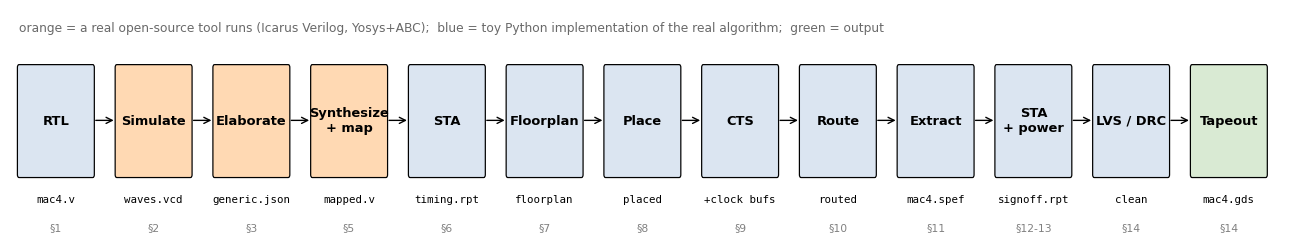

In [2]:
stages = [
    ("RTL", "mac4.v", "§1"), ("Simulate", "waves.vcd", "§2"), ("Elaborate", "generic.json", "§3"),
    ("Synthesize\n+ map", "mapped.v", "§5"), ("STA", "timing.rpt", "§6"), ("Floorplan", "floorplan", "§7"),
    ("Place", "placed", "§8"), ("CTS", "+clock bufs", "§9"), ("Route", "routed", "§10"),
    ("Extract", "mac4.spef", "§11"), ("STA\n+ power", "signoff.rpt", "§12-13"),
    ("LVS / DRC", "clean", "§14"), ("Tapeout", "mac4.gds", "§14"),
]
fig, ax = plt.subplots(figsize=(15, 2.7))
PITCH, BOXW = 1.22, 0.92
for i, (name, art, sec) in enumerate(stages):
    x = i * PITCH
    color = "#ffd9b3" if i in (1, 2, 3) else ("#d9ead3" if i >= 12 else "#dbe5f1")
    ax.add_patch(FancyBboxPatch((x, 0.45), BOXW, 0.75, boxstyle="round,pad=0.02", fc=color, ec="k", lw=0.8))
    ax.text(x + BOXW / 2, 0.83, name, ha="center", va="center", fontsize=8.5, weight="bold")
    ax.text(x + BOXW / 2, 0.28, art, ha="center", va="center", fontsize=7, family="monospace")
    ax.text(x + BOXW / 2, 0.08, sec, ha="center", va="center", fontsize=7, color="gray")
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + PITCH, 0.83), xytext=(x + BOXW, 0.83), arrowprops=dict(arrowstyle="->", lw=0.9))
ax.text(0, 1.45, "orange = a real open-source tool runs (Icarus Verilog, Yosys+ABC);  blue = toy Python "
        "implementation of the real algorithm;  green = output", fontsize=8, color="dimgray")
ax.set_xlim(-0.1, len(stages) * PITCH); ax.set_ylim(0, 1.6); ax.axis("off")
plt.show()

## 1. The RTL: what we want built

**Why this stage exists.** Someone must state, unambiguously and *cycle by cycle*, what the hardware does.
RTL is that statement: registers, plus the combinational functions that compute their next values. It is
the last human-authored artifact; everything downstream is a compiler pass.

`mac4` computes `acc ← acc + a·b` every cycle that `en` is high, with a synchronous `clear` and an
asynchronous active-low reset. One `always` block holds the entire design's state (8 flip-flops);
everything else is a pure function of that state and the inputs.


// mac4: a 4-bit multiply-accumulate unit -- one cell of a MAC array.
//   acc <= clear ? 0 : (en ? acc + a*b : acc)
module mac4 (
    input  wire       clk,
    input  wire       rst_n,      // asynchronous reset, active low
    input  wire       clear,      // synchronous clear
    input  wire       en,
    input  wire [3:0] a,
    input  wire [3:0] b,
    output reg  [7:0] acc
);
    wire [7:0] prod = a * b;      // combinational: a 4x4 multiplier

    always @(posedge clk or negedge rst_n) begin
        if (!rst_n)       acc <= 8'd0;
        else if (clear)   acc <= 8'd0;
        else if (en)      acc <= acc + prod;   // combinational adder + mux, then 8 flops
    end
endmodule



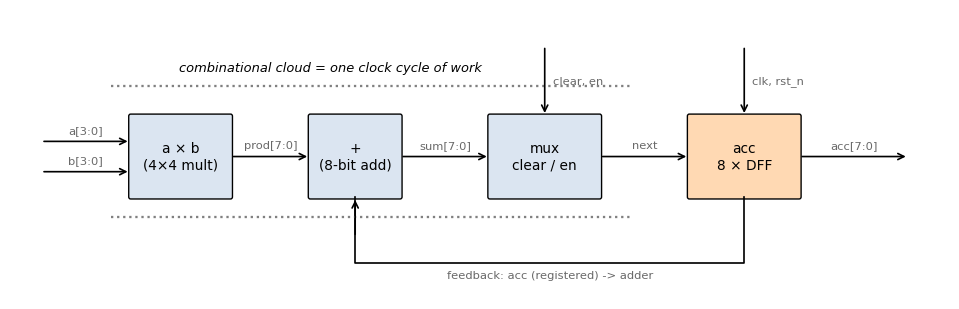

Every timing number in this notebook is about the arrow chain a,b -> x -> + -> mux -> DFF.


In [3]:
RTL = '''\
// mac4: a 4-bit multiply-accumulate unit -- one cell of a MAC array.
//   acc <= clear ? 0 : (en ? acc + a*b : acc)
module mac4 (
    input  wire       clk,
    input  wire       rst_n,      // asynchronous reset, active low
    input  wire       clear,      // synchronous clear
    input  wire       en,
    input  wire [3:0] a,
    input  wire [3:0] b,
    output reg  [7:0] acc
);
    wire [7:0] prod = a * b;      // combinational: a 4x4 multiplier

    always @(posedge clk or negedge rst_n) begin
        if (!rst_n)       acc <= 8'd0;
        else if (clear)   acc <= 8'd0;
        else if (en)      acc <= acc + prod;   // combinational adder + mux, then 8 flops
    end
endmodule
'''
with open(os.path.join(WORK, "mac4.v"), "w") as f:
    f.write(RTL)
print(RTL)

# The same design, drawn the way an RTL designer sees it: registers + combinational clouds.
fig, ax = plt.subplots(figsize=(11, 3.4))
def box(x, y, w, h, label, fc="#dbe5f1", fs=9):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", fc=fc, ec="k", lw=0.9))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=fs)
def arrow(x0, y0, x1, y1, label=None, **kw):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", lw=1.1, **kw))
    if label and x0 == x1:                                   # vertical arrow: label beside the shaft
        ax.text(x0 + 0.08, (y0 + y1) / 2, label, ha="left", va="center", fontsize=7.5, color="dimgray")
    elif label:
        ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.08, label, ha="center", fontsize=7.5, color="dimgray")
box(1.2, 1.1, 1.0, 0.8, "a × b\n(4×4 mult)")
box(3.0, 1.1, 0.9, 0.8, "+\n(8-bit add)")
box(4.8, 1.1, 1.1, 0.8, "mux\nclear / en")
box(6.8, 1.1, 1.1, 0.8, "acc\n8 × DFF", fc="#ffd9b3")
arrow(0.3, 1.65, 1.2, 1.65, "a[3:0]"); arrow(0.3, 1.35, 1.2, 1.35, "b[3:0]")
arrow(2.2, 1.5, 3.0, 1.5, "prod[7:0]"); arrow(3.9, 1.5, 4.8, 1.5, "sum[7:0]")
arrow(5.9, 1.5, 6.8, 1.5, "next"); arrow(7.9, 1.5, 9.0, 1.5, "acc[7:0]")
ax.plot([7.35, 7.35, 3.45, 3.45], [1.1, 0.45, 0.45, 1.1], c="k", lw=1.1)
ax.annotate("", xy=(3.45, 1.1), xytext=(3.45, 0.7), arrowprops=dict(arrowstyle="->", lw=1.1))
ax.text(5.4, 0.3, "feedback: acc (registered) -> adder", fontsize=7.5, color="dimgray", ha="center")
arrow(5.35, 2.6, 5.35, 1.9, "clear, en"); arrow(7.35, 2.6, 7.35, 1.9, "clk, rst_n")
ax.text(3.2, 2.35, "combinational cloud = one clock cycle of work", fontsize=8.5, style="italic", ha="center")
ax.plot([1.0, 6.2], [2.2, 2.2], ls=":", c="gray"); ax.plot([1.0, 6.2], [0.9, 0.9], ls=":", c="gray")
ax.set_xlim(0, 9.4); ax.set_ylim(0.1, 2.95); ax.axis("off")
plt.show()
print("Every timing number in this notebook is about the arrow chain a,b -> x -> + -> mux -> DFF.")

## 2. Functional verification: does it compute the right thing?

**Why this stage exists.** Nothing downstream checks *intent* — synthesis will faithfully build your bug.
Since silicon cannot be patched, verification consumes more engineer-hours than design (§6.3 of the
previous notebook). The workflow: write a **testbench** that drives stimulus into the design and compares
its outputs against a **reference model**, run it in a simulator, look at **waveforms** when it fails.

Below, a real Verilog testbench runs in **Icarus Verilog** (the open-source event-driven simulator; the
commercial equivalents are Synopsys VCS / Cadence Xcelium / Siemens Questa). The testbench itself contains
a reference model (`expected`) and asserts equality every cycle — a directed test followed by a random one,
in miniature the constrained-random methodology of §6.3. The simulator dumps a **VCD** (value change dump)
file — the waveform format every viewer reads — which we parse and draw ourselves.


Icarus Verilog says: tb.v:26: $finish called at 207000 (1ps)
signals in the VCD: 18 | showing 8


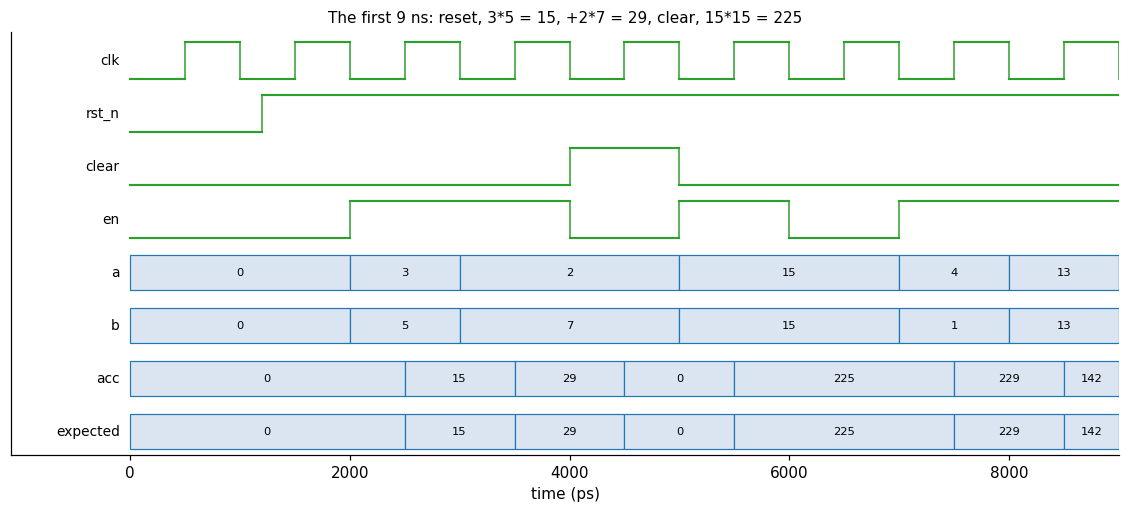

acc lags expected by nothing -- both are registered on the same edge; the testbench compares them
at the *negative* edge to avoid the race. That kind of detail is verification's daily bread.


In [4]:
TB = '''\
`timescale 1ns/1ps
module tb;
    reg clk = 0, rst_n = 0, clear = 0, en = 0;
    reg [3:0] a = 0, b = 0;
    wire [7:0] acc;
    reg [7:0] expected = 0;
    integer i, errors = 0;

    mac4 dut (.clk(clk), .rst_n(rst_n), .clear(clear), .en(en), .a(a), .b(b), .acc(acc));
    always #0.5 clk = ~clk;                       // 1 GHz clock: the target we will constrain to

    initial begin
        $dumpfile("waves.vcd"); $dumpvars(0, tb);
        #1.2 rst_n = 1;
        // directed test: 3*5, then 2*7, then clear, then 15*15
        @(negedge clk) en = 1; a = 3;  b = 5;
        @(negedge clk) a = 2;  b = 7;
        @(negedge clk) en = 0; clear = 1;
        @(negedge clk) clear = 0; en = 1; a = 15; b = 15;
        @(negedge clk) en = 0;
        // constrained-random test: 200 cycles against the reference model
        for (i = 0; i < 200; i = i + 1) begin
            @(negedge clk);
            a = $random; b = $random; en = ($random % 4) != 0; clear = ($random % 16) == 0;
        end
        @(negedge clk) $display("random test done: %0d mismatches", errors); $finish;
    end

    // the reference model + scoreboard, checked at every clock edge
    always @(posedge clk or negedge rst_n) begin
        if (!rst_n) expected <= 0;
        else if (clear) expected <= 0;
        else if (en) expected <= expected + a * b;
    end
    always @(negedge clk) if (rst_n && acc !== expected) begin
        errors = errors + 1;
        $display("MISMATCH t=%0t acc=%0d expected=%0d", $time, acc, expected);
    end
endmodule
'''
with open(os.path.join(WORK, "tb.v"), "w") as f:
    f.write(TB)

if IVERILOG:
    r = subprocess.run([IVERILOG, "-o", "sim.vvp", "mac4.v", "tb.v"], cwd=WORK, capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    VVP = shutil.which("vvp") or os.path.join(os.path.dirname(IVERILOG), "vvp")
    r = subprocess.run([VVP, "sim.vvp"], cwd=WORK, capture_output=True, text=True)
    print("Icarus Verilog says:", r.stdout.strip().splitlines()[-1])
else:
    print("iverilog not found; using the saved waves.vcd")


def parse_vcd(path):
    '''Minimal VCD reader: returns {signal: [(time, int_value), ...]} and the timescale.'''
    ids, values, scope = {}, defaultdict(list), []
    t = 0
    for line in open(path):
        tok = line.split()
        if not tok:
            continue
        if tok[0] == "$scope":
            scope.append(tok[2])
        elif tok[0] == "$upscope":
            scope.pop()
        elif tok[0] == "$var":
            ids.setdefault(tok[3], []).append(".".join(scope + [tok[4]]))
        elif tok[0][0] == "#":
            t = int(tok[0][1:])
        elif tok[0][0] in "01xz":
            v = tok[0][0]; ident = tok[0][1:]
            for name in ids.get(ident, []):
                values[name].append((t, None if v in "xz" else int(v)))
        elif tok[0][0] == "b":
            v = tok[0][1:]; ident = tok[1]
            for name in ids.get(ident, []):
                values[name].append((t, None if any(c in "xz" for c in v) else int(v, 2)))
    return values


waves = parse_vcd(os.path.join(WORK, "waves.vcd"))
sigs = ["tb.clk", "tb.rst_n", "tb.clear", "tb.en", "tb.a", "tb.b", "tb.acc", "tb.expected"]
print("signals in the VCD:", len(waves), "| showing", len(sigs))


def plot_waves(waves, names, t_end_ps, ax=None, title=""):
    '''Draw waveforms the way GTKWave/Verdi do: 1-bit as steps, buses as labeled bands.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 0.55 * len(names) + 0.6))
    for row, name in enumerate(names):
        y0 = len(names) - 1 - row
        changes = [(t, v) for t, v in waves[name] if t <= t_end_ps]
        width = max((v.bit_length() for _, v in waves[name] if v is not None), default=1)
        pts = changes + [(t_end_ps, changes[-1][1])]
        for (t0, v), (t1, _) in zip(pts, pts[1:]):
            if width <= 1:
                ax.plot([t0, t1], [y0 + 0.1 + 0.7 * (v or 0)] * 2, c="#2ca02c", lw=1.4)
                if t0 != pts[0][0]:
                    ax.plot([t0, t0], [y0 + 0.1, y0 + 0.8], c="#2ca02c", lw=1.0)
            else:
                ax.add_patch(Rectangle((t0, y0 + 0.12), t1 - t0, 0.66, fc="#dbe5f1", ec="#1f77b4", lw=0.8))
                if t1 - t0 > t_end_ps / 70:
                    ax.text((t0 + t1) / 2, y0 + 0.45, "x" if v is None else str(v),
                            ha="center", va="center", fontsize=7.5)
        ax.text(-t_end_ps * 0.01, y0 + 0.45, name.split(".")[-1], ha="right", va="center", fontsize=9)
    ax.set_xlim(-t_end_ps * 0.12, t_end_ps); ax.set_ylim(0, len(names))
    ax.set_yticks([]); ax.grid(False)
    ax.set_xlabel("time (ps)"); ax.set_title(title, fontsize=10)
    return ax

plot_waves(waves, sigs, 9000, title="The first 9 ns: reset, 3*5 = 15, +2*7 = 29, clear, 15*15 = 225")
plt.show()
print("acc lags expected by nothing -- both are registered on the same edge; the testbench compares them")
print("at the *negative* edge to avoid the race. That kind of detail is verification's daily bread.")

## 3. Elaboration: from text to a word-level netlist

**Why this stage exists.** Before any optimization, the tool must turn Verilog *text* into a *graph*:
operators (`$mul`, `$add`, `$mux`) connected by multi-bit wires, and registers inferred from the `always`
block. This is the RTL front end — parsing, type resolution, `always`-block-to-process conversion
(`proc`), constant propagation. Yosys calls the result the **generic (technology-independent) netlist**;
Synopsys and Cadence call the same thing GTECH / elaborated design. Note what has *not* happened yet: no
gates, no library, no timing — but every downstream stage works on this graph, never on the text again.

We run real Yosys here and read its JSON output.


Yosys ran: True | generic cells: Counter({'$mux': 2, '$add': 1, '$adffe': 1, '$reduce_bool': 1, '$mul': 1})


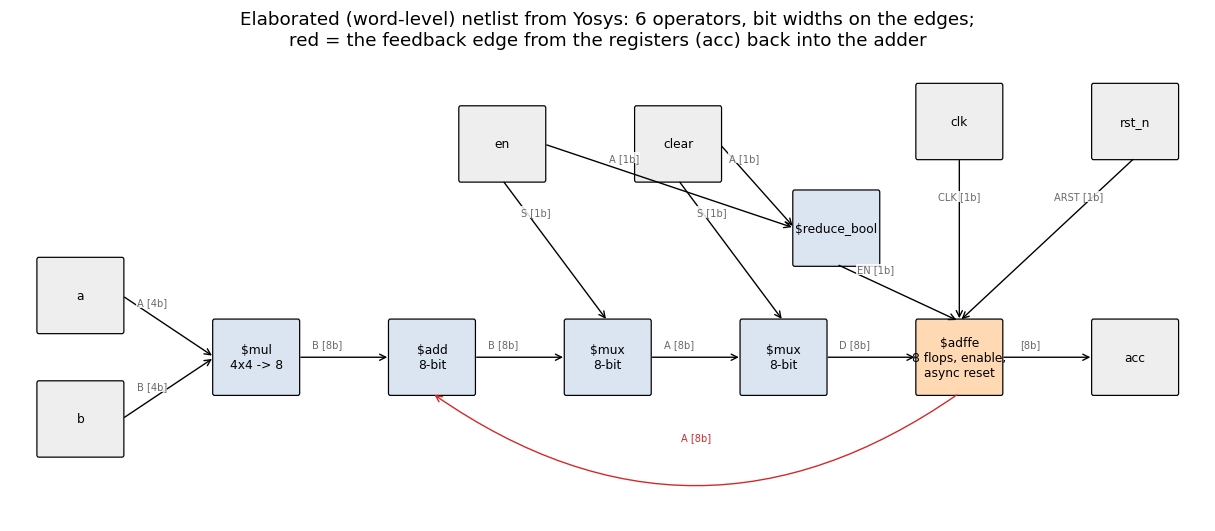

The multiplier and adder are still *operators*, not gates. Choosing an implementation for them
(ripple? carry-lookahead? Booth?) is exactly the job of the next stage.


In [5]:
ok = run_yosys('''
read_verilog mac4.v
hierarchy -top mac4
proc; opt; wreduce; opt_clean          # processes -> muxes/flops; constant folding; width reduction
write_json generic.json
''', "elaborate")
generic = json.load(open(os.path.join(WORK, "generic.json")))["modules"]["mac4"]
print("Yosys ran:", ok, "| generic cells:", Counter(c["type"] for c in generic["cells"].values()))


def word_level_graph(mod):
    '''Nodes = ports + cells; edges carry bit widths. Returns (nodes, edges).'''
    nodes, edges = {}, []
    bit_owner = {}                                     # bit id -> driving node
    for pname, p in mod["ports"].items():
        nodes[pname] = ("port_in" if p["direction"] == "input" else "port_out", len(p["bits"]))
        if p["direction"] == "input":
            for b in p["bits"]:
                bit_owner[b] = pname
    for cname, c in mod["cells"].items():
        short = c["type"].lstrip("$")
        nodes[cname] = (short, 0)
        for pin, bits in c["connections"].items():
            if c["port_directions"][pin] == "output":
                for b in bits:
                    bit_owner[b] = cname
    for cname, c in mod["cells"].items():
        for pin, bits in c["connections"].items():
            if c["port_directions"][pin] == "input":
                srcs = Counter(bit_owner.get(b, "const") for b in bits)
                for s, n in srcs.items():
                    edges.append((s, cname, pin, n))
    for pname, p in mod["ports"].items():
        if p["direction"] == "output":
            for s, n in Counter(bit_owner.get(b, "const") for b in p["bits"]).items():
                edges.append((s, pname, "", n))
    return nodes, edges


def layered_positions(nodes, edges, seq_types=()):
    '''Longest-path layering (feedback edges from sequential nodes are ignored for layering).'''
    preds = defaultdict(list)
    for s, d, *_ in edges:
        feedback = s in nodes and nodes[s][0] in seq_types and not nodes[d][0].startswith("port")
        if s in nodes and not feedback:
            preds[d].append(s)
    depth = {}
    def dep(n):
        if n not in depth:
            depth[n] = 0 if not preds[n] else 1 + max(dep(p) for p in preds[n])
        return depth[n]
    for n in nodes:
        dep(n)
    layers = defaultdict(list)
    for n, d in depth.items():
        layers[d].append(n)
    pos = {}
    for d, ns in layers.items():
        for k, n in enumerate(sorted(ns)):
            pos[n] = (d, (k - (len(ns) - 1) / 2))
    return pos


nodes, edges = word_level_graph(generic)
pos = layered_positions(nodes, edges, seq_types=("adffe",))
# For this particular design, lay it out like the block diagram in section 1: datapath left-to-right,
# control inputs along the top. (Any other RTL falls back to the automatic layering above.)
depth = {n: x for n, (x, _) in pos.items()}
by_type = defaultdict(list)
for n, (typ, _) in nodes.items():
    by_type[typ].append(n)
if sorted(by_type) == ["add", "adffe", "mul", "mux", "port_in", "port_out", "reduce_bool"] and len(by_type["mux"]) == 2:
    m1, m2 = sorted(by_type["mux"], key=depth.get)
    pos = {"a": (0, 0.55), "b": (0, -0.55), by_type["mul"][0]: (1, 0), by_type["add"][0]: (2, 0), m1: (3, 0), m2: (4, 0),
           by_type["adffe"][0]: (5, 0), "acc": (6, 0), "en": (2.4, 1.9), "clear": (3.4, 1.9),
           by_type["reduce_bool"][0]: (4.3, 1.15), "clk": (5.0, 2.1), "rst_n": (6.0, 2.1)}
label = {"port_in": "input", "port_out": "output", "mul": "$mul\n4x4 -> 8", "add": "$add\n8-bit",
         "mux": "$mux\n8-bit", "adffe": "$adffe\n8 flops, enable,\nasync reset", "reduce_bool": "$reduce_bool"}
XS, YS, HW, HH = 1.9, 1.0, 0.45, 0.32          # layer spacing, row spacing, half box width / height
fig, ax = plt.subplots(figsize=(14, 5.5))
XY = {n: (pos[n][0] * XS, pos[n][1] * YS) for n in nodes}
for n, (typ, w) in nodes.items():
    x, y = XY[n]
    fc = "#ffd9b3" if typ == "adffe" else ("#eeeeee" if typ.startswith("port") else "#dbe5f1")
    txt = n if typ.startswith("port") else label.get(typ, typ)
    ax.add_patch(FancyBboxPatch((x - HW, y - HH), 2 * HW, 2 * HH, boxstyle="round,pad=0.02", fc=fc, ec="k", lw=0.8, zorder=3))
    ax.text(x, y, txt, ha="center", va="center", fontsize=8, zorder=4)
def anchor(src, dst):
    '''Leave a box from the side that faces the destination.'''
    (x0, y0), (x1, y1) = XY[src], XY[dst]
    if abs(y1 - y0) > 0.8 * abs(x1 - x0):
        return (x0, y0 - HH if y1 < y0 else y0 + HH), (x1, y1 + HH if y1 < y0 else y1 - HH)
    return (x0 + HW if x1 > x0 else x0 - HW, y0), (x1 - HW if x1 > x0 else x1 + HW, y1)
for s, d, pin, w in edges:
    if s not in XY:
        continue
    back = nodes[s][0] == "adffe" and not nodes[d][0].startswith("port")   # the register feedback edge
    (x0, y0), (x1, y1) = anchor(s, d)
    if back:
        (x0, y0), (x1, y1) = (XY[s][0], XY[s][1] - HH), (XY[d][0], XY[d][1] - HH)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", lw=0.9, color="#d62728" if back else "k",
                                connectionstyle="arc3,rad=-0.35" if back else "arc3,rad=0"))
    f = 0.5 if back else 0.32                                # label near the source end of each edge
    dy = -0.42 if back else 0.09
    ax.text(x0 + f * (x1 - x0), y0 + f * (y1 - y0) + dy, f"{pin} [{w}b]" if pin else f"[{w}b]",
            fontsize=6.5, color="#d62728" if back else "dimgray", ha="center", zorder=5,
            bbox=dict(fc="white", ec="none", pad=0.4, alpha=0.85))
xs, ys = zip(*XY.values())
ax.set_xlim(min(xs) - HW - 0.3, max(xs) + HW + 0.3); ax.set_ylim(min(ys) - 0.9, max(ys) + 0.6); ax.axis("off")
ax.set_title("Elaborated (word-level) netlist from Yosys: 6 operators, bit widths on the edges;\n"
             "red = the feedback edge from the registers (acc) back into the adder")
plt.show()
print("The multiplier and adder are still *operators*, not gates. Choosing an implementation for them")
print("(ripple? carry-lookahead? Booth?) is exactly the job of the next stage.")

## 4. The technology library: the menu synthesis orders from

**Why this stage exists.** A gate netlist is only meaningful relative to a *library* — the fixed set of
standard cells a specific foundry process offers. The library ships as a **Liberty (`.lib`) file**: per
cell, its area, leakage, pin capacitances, Boolean function, and delay/slew as 2-D lookup tables indexed
by (input slew, output load). That file is the transistor layer compressed into numbers; synthesis, P&R
and timing signoff all navigate by it.

We parse the real Nangate45 file with a ~60-line parser (Liberty's grammar is just nested
`group(args) { attribute : value; }`) and look at the menu. Nangate45 is an *open, academic* 45 nm
library — no fab accepts it, but it is structurally identical to what TSMC hands out under NDA.


parsed 44 cells in 0.15 s



cell       area um^2  sites  inputs  avg in-cap fF  leak nW  function                
-------------------------------------------------------------------------------------
INV_X1     0.53       2      1       1.70           14.35    !A                      
BUF_X1     0.80       3      1       0.97           21.44    A                       
CLKBUF_X1  0.80       3      1       0.78           11.21    A                       
NAND2_X1   0.80       3      2       1.63           17.39    !(A1 & A2)              
NAND3_X1   1.06       4      3       1.62           18.10    !((A1 & A2) & A3)       
NAND4_X1   1.33       5      4       1.60           18.13    !(((A1 & A2) & A3) & A4)
NOR2_X1    0.80       3      2       1.68           21.20    !(A1 | A2)              
NOR3_X1    1.06       4      3       1.68           26.83    !((A1 | A2) | A3)       
AND2_X1    1.06       4      2       0.95           25.07    (A1 & A2)               
AND3_X1    1.33       5      3       0.92           2

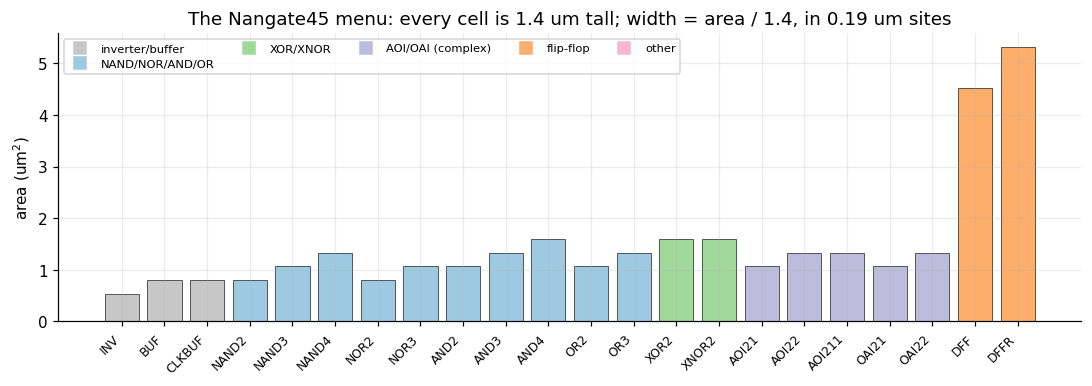

A flip-flop with reset costs 6.7 NAND2s of area -- which is why 'just add pipeline registers' is not free.


In [6]:
_TOKEN = re.compile(r'\s*(?:(\{)|(\})|(;)|(:)|(\()|(\))|(,)|("(?:[^"\\]|\\.)*")|([^\s{};:(),"]+))', re.S)

def _tokenize(s):
    s = s.replace("\\\n", " ")                       # Liberty line continuations
    return [next(g for g in m.groups() if g is not None) for m in _TOKEN.finditer(s)]

def parse_liberty_group(text):
    '''Parse one `name(args) { ... }` group into a dict: attributes, plus "_groups" for children.'''
    toks, pos = _tokenize(text), 0
    def parse_group():
        nonlocal pos
        name = toks[pos]; pos += 1
        args = []
        if toks[pos] == "(":
            pos += 1
            while toks[pos] != ")":
                if toks[pos] != ",":
                    args.append(toks[pos].strip('"'))
                pos += 1
            pos += 1
        pos += 1                                      # '{'
        g = {"_name": name, "_args": args, "_groups": []}
        while toks[pos] != "}":
            t = toks[pos]
            if toks[pos + 1] == ":":                  # simple attribute: name : value ;
                pos += 2; vals = []
                while toks[pos] != ";":
                    vals.append(toks[pos].strip('"')); pos += 1
                pos += 1
                g[t] = vals[0] if len(vals) == 1 else vals
            elif toks[pos + 1] == "(":                # subgroup or complex attribute
                j, depth = pos + 2, 1
                while depth:
                    depth += {"(": 1, ")": -1}.get(toks[j], 0); j += 1
                if toks[j] == "{":
                    g["_groups"].append(parse_group())
                else:
                    g.setdefault(t, []).append([x.strip('"') for x in toks[pos + 2:j - 1] if x != ","])
                    pos = j + 1
            else:
                pos += 1
        pos += 1
        return g
    return parse_group()

def _floats(s):
    return np.array([float(x) for x in re.split(r"[,\s]+", s.strip()) if x])

def _table(group):
    '''NLDM table -> (index_1, index_2, values); scalar/1-D tables are padded to 2x2.'''
    idx1 = _floats(group["index_1"][0][0]) if "index_1" in group else np.array([0.0])
    idx2 = _floats(group["index_2"][0][0]) if "index_2" in group else np.array([0.0])
    flat = lambda x: [s for y in x for s in flat(y)] if isinstance(x, list) else [x]
    vals = np.concatenate([_floats(r) for r in flat(group["values"])]).reshape(len(idx1), len(idx2))
    if len(idx1) == 1:
        idx1, vals = np.array([idx1[0], idx1[0] + 1]), np.vstack([vals, vals])
    if len(idx2) == 1:
        idx2, vals = np.array([idx2[0], idx2[0] + 1]), np.hstack([vals, vals])
    return idx1, idx2, vals

def liberty_cells(lib_text, names):
    '''Extract the named cells: area, leakage, pins (dir/cap/function), timing arcs with tables.'''
    cells = {}
    for name in names:
        m = re.search(r"\n\s*cell\s*\(\s*" + re.escape(name) + r"\s*\)\s*\{", lib_text)
        assert m, f"{name} not in library"
        nxt = re.search(r"\n\s*cell\s*\(", lib_text[m.end():])
        end = m.end() + nxt.start() if nxt else len(lib_text)
        g = parse_liberty_group(lib_text[m.start() + 1: end])
        cell = {"area": float(g["area"]), "leakage_nW": float(g.get("cell_leakage_power", 0)),
                "pins": {}, "arcs": [], "ff": None}
        for sub in g["_groups"]:
            if sub["_name"] == "ff":
                cell["ff"] = {"next_state": sub["next_state"], "clocked_on": sub["clocked_on"], "clear": sub.get("clear")}
            if sub["_name"] != "pin":
                continue
            pname = sub["_args"][0]
            cell["pins"][pname] = {"dir": sub["direction"], "cap": float(sub.get("capacitance", 0)),
                                   "function": sub.get("function")}
            for t in sub["_groups"]:
                if t["_name"] == "timing":
                    arc = {"pin": pname, "related": t["related_pin"], "type": t.get("timing_type", "combinational"),
                           "tables": {x["_name"]: _table(x) for x in t["_groups"] if "values" in x}}
                    cell["arcs"].append(arc)
        cells[name] = cell
    return cells

def nldm(table, slew, load):
    '''Bilinear interpolation in an NLDM table -- what every STA engine does per timing arc.'''
    idx1, idx2, vals = table
    i = int(np.clip(np.searchsorted(idx1, slew) - 1, 0, len(idx1) - 2))
    j = int(np.clip(np.searchsorted(idx2, load) - 1, 0, len(idx2) - 2))
    fs = (slew - idx1[i]) / (idx1[i + 1] - idx1[i]); fl = (load - idx2[j]) / (idx2[j + 1] - idx2[j])
    return ((1 - fs) * (1 - fl) * vals[i, j] + fs * (1 - fl) * vals[i + 1, j]
            + (1 - fs) * fl * vals[i, j + 1] + fs * fl * vals[i + 1, j + 1])

# One colour per cell family, used in every figure from here on.
FAMILY = [("CLKBUF", "inverter/buffer"), ("INV", "inverter/buffer"), ("BUF", "inverter/buffer"),
          ("XNOR", "XOR/XNOR"), ("XOR", "XOR/XNOR"), ("AOI", "AOI/OAI (complex)"), ("OAI", "AOI/OAI (complex)"),
          ("NAND", "NAND/NOR/AND/OR"), ("NOR", "NAND/NOR/AND/OR"), ("AND", "NAND/NOR/AND/OR"), ("OR", "NAND/NOR/AND/OR"),
          ("DFF", "flip-flop"), ("", "other")]
FAM_COLOR = {"inverter/buffer": "#c7c7c7", "NAND/NOR/AND/OR": "#9ecae1", "XOR/XNOR": "#a1d99b",
             "AOI/OAI (complex)": "#bcbddc", "flip-flop": "#fdae6b", "other": "#f7b6d2"}
LAYER_COLOR = {0: "#e6a23c", 1: "#4fa3ff"}          # metal3 (horizontal) orange, metal2 (vertical) blue

def family(ctype):
    return next(fam for prefix, fam in FAMILY if ctype.startswith(prefix))

# The menu: every cell family Yosys/ABC might pick, at drive strength X1 (plus X2 for the ECO later).
MENU = ["INV", "BUF", "CLKBUF", "NAND2", "NAND3", "NAND4", "NOR2", "NOR3", "AND2", "AND3", "AND4",
        "OR2", "OR3", "XOR2", "XNOR2", "AOI21", "AOI22", "AOI211", "OAI21", "OAI22", "DFF", "DFFR"]
t0 = time.time()
LIB = liberty_cells(LIB_TEXT, [f"{c}_X1" for c in MENU] + [f"{c}_X2" for c in MENU])
print(f"parsed {len(LIB)} cells in {time.time() - t0:.2f} s\n")

rows = []
for c in MENU:
    cell = LIB[c + "_X1"]
    ins = [p for p, d in cell["pins"].items() if d["dir"] == "input"]
    fn = next((d["function"] for d in cell["pins"].values() if d["function"]), "")
    rows.append([c + "_X1", cell["area"], round(cell["area"] / (1.4 * 0.19)), len(ins),
                 np.mean([cell["pins"][p]["cap"] for p in ins]), cell["leakage_nW"], fn[:28]])
show_table(["cell", "area um^2", "sites", "inputs", "avg in-cap fF", "leak nW", "function"], rows, "{:.2f}")

fig, ax = plt.subplots(figsize=(12, 3.4))
areas = [LIB[c + "_X1"]["area"] for c in MENU]
ax.bar(MENU, areas, color=[FAM_COLOR[family(c)] for c in MENU], ec="k", lw=0.4)
for fam, col in FAM_COLOR.items():
    ax.plot([], [], "s", c=col, ms=8, label=fam)
ax.legend(fontsize=7.5, ncol=5, loc="upper left")
ax.set_ylabel("area (um$^2$)"); ax.set_title("The Nangate45 menu: every cell is 1.4 um tall; width = area / 1.4, in 0.19 um sites")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.show()
print(f"A flip-flop with reset costs {LIB['DFFR_X1']['area'] / LIB['NAND2_X1']['area']:.1f} NAND2s of area -- "
      "which is why 'just add pipeline registers' is not free.")

## 5. Logic synthesis: operators → optimized Boolean network → library cells

**Why this stage exists.** The word-level graph must become a **gate netlist**: each operator expanded
into bits, the resulting Boolean network minimized (constant propagation, sharing, algebraic rewriting),
then **technology-mapped** — covered with actual library cells, choosing among the library's menu (241
cells in Nangate45; 1000+ in a commercial library) to meet timing at minimum area. Yosys does the front
half; **ABC** (Berkeley's And-Inverter-Graph optimizer) does the mapping against the Liberty file.
Commercial: Synopsys Design Compiler / Fusion Compiler, Cadence Genus — same pipeline, better heuristics,
physical awareness. (A production flow also inserts **scan chains** right after synthesis — a test mux in
front of every flop, ~3–5% area — so the fabricated chip can be tested; we skip DFT.)

We synthesize for real, then render the resulting netlist as a layered graph.


In [7]:
ok = run_yosys('''
read_verilog mac4.v
hierarchy -top mac4
synth -top mac4                                   # elaborate, expand operators to bits, optimize (AIG)
dfflibmap -liberty NangateOpenCellLibrary_typical.lib   # map flops to library flops (DFFR = w/ reset)
abc -liberty NangateOpenCellLibrary_typical.lib         # ABC: technology-map the logic to Nangate45 cells
opt_clean -purge
write_json mapped.json
write_verilog -noattr mapped.v
''', "synth")
mapped_json = json.load(open(os.path.join(WORK, "mapped.json")))
print("Yosys+ABC ran:", ok)


class Netlist:
    '''A gate-level netlist from Yosys JSON: cells {inst: type, conn}, ports, nets {driver, sinks}.'''
    def __init__(self, yosys_json, top, lib):
        mod = yosys_json["modules"][top]
        self.lib, self.cells, self.ports, self.nets = lib, {}, {}, {}
        missing = sorted({c["type"] for c in mod["cells"].values()} - set(lib))
        if missing:                                              # parse any library cell we have not seen yet
            lib.update(liberty_cells(LIB_TEXT, missing))
        names = {}
        for nname, n in mod.get("netnames", {}).items():
            if not n.get("hide_name"):
                for k, b in enumerate(n["bits"]):
                    if isinstance(b, int) and b not in names:
                        names[b] = nname if len(n["bits"]) == 1 else f"{nname}[{k}]"
        def net(b):
            nm = f"const_{b}" if isinstance(b, str) else names.get(b, f"n{b}")
            self.nets.setdefault(nm, {"driver": None, "sinks": []})
            return nm
        for pname, p in mod["ports"].items():
            for k, b in enumerate(p["bits"]):
                bit = pname if len(p["bits"]) == 1 else f"{pname}[{k}]"
                n = net(b)
                self.ports[bit] = (p["direction"], n)
                if p["direction"] == "input":
                    self.nets[n]["driver"] = ("PI", bit)
                else:
                    self.nets[n]["sinks"].append(("PO", bit))
        for k, (inst, c) in enumerate(mod["cells"].items()):
            short = f"U{k}"                             # readable instance names
            conn = {}
            for pin, bits in c["connections"].items():
                n = net(bits[0]); conn[pin] = n
                if lib[c["type"]]["pins"][pin]["dir"] == "output":
                    self.nets[n]["driver"] = (short, pin)
                else:
                    self.nets[n]["sinks"].append((short, pin))
            self.cells[short] = {"type": c["type"], "conn": conn}

    def is_seq(self, inst):
        return self.lib[self.cells[inst]["type"]]["ff"] is not None

    def topo_comb(self):
        '''Combinational cells in topological order (PIs and flop outputs are the sources).'''
        indeg, succ = {}, defaultdict(list)
        for inst, c in self.cells.items():
            if self.is_seq(inst):
                continue
            indeg[inst] = 0
            for pin, n in c["conn"].items():
                if self.lib[c["type"]]["pins"][pin]["dir"] == "input":
                    d = self.nets[n]["driver"]
                    if d and d[0] != "PI" and not self.is_seq(d[0]):
                        indeg[inst] += 1; succ[d[0]].append(inst)
        order, ready = [], [i for i, d in indeg.items() if d == 0]
        while ready:
            i = ready.pop(); order.append(i)
            for s in succ[i]:
                indeg[s] -= 1
                if indeg[s] == 0:
                    ready.append(s)
        assert len(order) == len(indeg), "combinational loop"
        return order

    def add_cell(self, inst, ctype, conn):
        self.cells[inst] = {"type": ctype, "conn": dict(conn)}
        for pin, n in conn.items():
            self.nets.setdefault(n, {"driver": None, "sinks": []})
            if self.lib[ctype]["pins"][pin]["dir"] == "output":
                self.nets[n]["driver"] = (inst, pin)
            else:
                self.nets[n]["sinks"].append((inst, pin))


NL = Netlist(mapped_json, "mac4", LIB)
counts = Counter(c["type"] for c in NL.cells.values())
area = sum(LIB[c["type"]]["area"] for c in NL.cells.values())
print(f"{len(NL.cells)} cells, {len(NL.nets)} nets, total cell area {area:.1f} um^2\n")
show_table(["cell type", "count", "area um^2"],
           [[t, n, n * LIB[t]["area"]] for t, n in counts.most_common()], "{:.1f}")

Yosys+ABC ran: True
128 cells, 148 nets, total cell area 173.4 um^2

cell type  count  area um^2
---------------------------
NAND2_X1   21     16.8     
NOR2_X1    14     11.2     
OAI21_X1   14     14.9     
XOR2_X1    11     17.6     
AOI21_X1   10     10.6     
XNOR2_X1   10     16.0     
INV_X1     8      4.3      
DFFR_X1    8      42.6     
AOI22_X1   6      8.0      
NOR3_X1    4      4.3      
OR3_X1     4      5.3      
AND2_X1    4      4.3      
OR2_X1     3      3.2      
AND4_X1    3      4.8      
AND3_X1    3      4.0      
NAND3_X1   3      3.2      
NAND4_X1   1      1.3      
AOI211_X1  1      1.3      


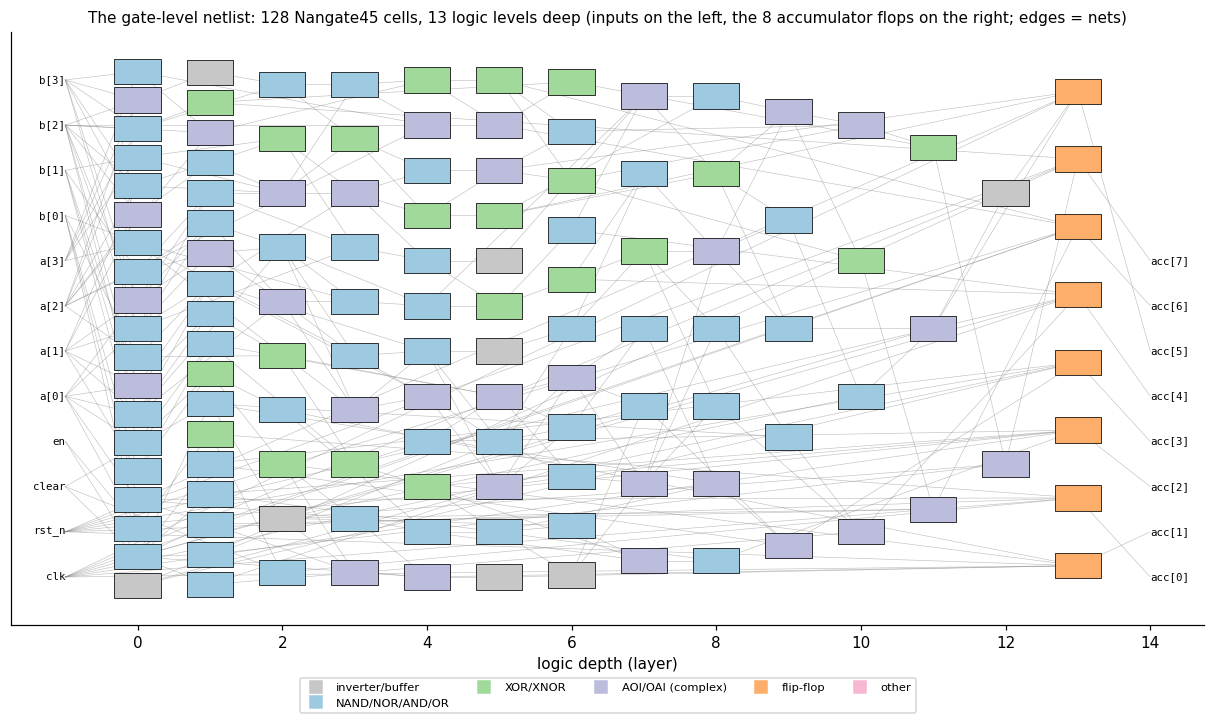

13 logic levels = the multiplier's partial-product reduction + the 8-bit carry chain. Every one
of those layers is a gate delay the clock period must contain. Section 6 measures it.


In [8]:
def gate_graph_layout(nl):
    '''Layer cells by logic depth from sources; flops go in the last layer; barycenter ordering.'''
    order = nl.topo_comb()
    depth = {}
    for inst in order:
        c = nl.cells[inst]; d = 0
        for pin, n in c["conn"].items():
            if nl.lib[c["type"]]["pins"][pin]["dir"] == "input":
                drv = nl.nets[n]["driver"]
                if drv and drv[0] != "PI" and not nl.is_seq(drv[0]):
                    d = max(d, depth[drv[0]] + 1)
        depth[inst] = d
    maxd = max(depth.values()) + 1
    for inst in nl.cells:
        if nl.is_seq(inst):
            depth[inst] = maxd
    pos = {}
    ins = [p for p, (d, n) in nl.ports.items() if d == "input"]
    for k, p in enumerate(ins):
        pos[p] = (-1, k)
    layers = defaultdict(list)
    for inst, d in depth.items():
        layers[d].append(inst)
    for d in range(maxd + 1):
        def bary(inst):
            ys = []
            for pin, n in nl.cells[inst]["conn"].items():
                drv = nl.nets[n]["driver"]
                if nl.lib[nl.cells[inst]["type"]]["pins"][pin]["dir"] == "input" and drv:
                    key = drv[1] if drv[0] == "PI" else drv[0]
                    if key in pos:
                        ys.append(pos[key][1])
            return np.mean(ys) if ys else 0
        ordered = sorted(layers[d], key=bary)
        n = len(ordered)
        for k, inst in enumerate(ordered):
            pos[inst] = (d, (k - (n - 1) / 2) * (len(ins) / max(n, 1)) * 1.0 + (len(ins) - 1) / 2)
    outs = [p for p, (d, n) in nl.ports.items() if d == "output"]
    for k, p in enumerate(outs):
        pos[p] = (maxd + 1, k)
    return pos


def path_edges(nl, r):
    '''(from, to) node pairs along an STA critical path, for highlighting.'''
    keys = [via for *_, via in r["path"]] + [r["worst"][1] if r["worst"][0] == "PO" else r["worst"][0]]
    return set(zip(keys, keys[1:]))


def draw_gate_graph(nl, pos, ax, highlight_edges=(), highlight_cells=(), title=""):
    for n, d in nl.nets.items():
        drv = d["driver"]
        if not drv:
            continue
        src = drv[1] if drv[0] == "PI" else drv[0]
        for inst, pin in d["sinks"]:
            dst = pin if inst == "PO" else inst
            if src not in pos or dst not in pos:
                continue
            (x0, y0), (x1, y1) = pos[src], pos[dst]
            hot = (src, dst) in highlight_edges
            ax.plot([x0, x1], [y0, y1], c="#d62728" if hot else "gray", lw=2.0 if hot else 0.4,
                    alpha=1 if hot else 0.5, zorder=3 if hot else 1)
    for inst, c in nl.cells.items():
        if inst not in pos:                                   # e.g. clock buffers added by CTS after this layout
            continue
        x, y = pos[inst]
        fam = family(c["type"])
        ax.add_patch(Rectangle((x - 0.32, y - 0.28), 0.64, 0.56, fc=FAM_COLOR[fam],
                               ec="#d62728" if inst in highlight_cells else "k",
                               lw=2 if inst in highlight_cells else 0.5, zorder=4))
    for p, (d, n) in nl.ports.items():
        x, y = pos[p]
        ax.text(x, y, p, ha="right" if d == "input" else "left", va="center", fontsize=7, family="monospace")
    for fam, col in FAM_COLOR.items():
        ax.plot([], [], "s", c=col, ms=8, label=fam)
    ax.legend(fontsize=7.5, loc="upper center", ncol=5, bbox_to_anchor=(0.5, -0.08))
    ax.set_xlabel("logic depth (layer)"); ax.set_yticks([]); ax.grid(False)
    ax.set_title(title, fontsize=10)


POS = gate_graph_layout(NL)
depth = max(x for x, _ in POS.values()) - 1                 # logic levels between the inputs and the flops
fig, ax = plt.subplots(figsize=(14, 7))
draw_gate_graph(NL, POS, ax, title=f"The gate-level netlist: {len(NL.cells)} Nangate45 cells, {depth} logic levels deep "
                f"(inputs on the left, the 8 accumulator flops on the right; edges = nets)")
plt.show()
print(f"{depth} logic levels = the multiplier's partial-product reduction + the 8-bit carry chain. Every one")
print("of those layers is a gate delay the clock period must contain. Section 6 measures it.")

### 5.1 Did synthesis preserve the function? Gate-level simulation vs RTL

Synthesis is a compiler; compilers have bugs, and more often *designers* write RTL whose simulation
semantics differ from its synthesis semantics. Industry answers this with **formal equivalence checking**
(Synopsys Formality, Cadence Conformal: prove netlist ≡ RTL). We do the cheap version: build a gate-level
simulator that evaluates every cell's Boolean function from the Liberty file, replay the *exact* stimulus
the Icarus testbench used (read back from the VCD), and compare `acc` cycle by cycle. This also produces
something we need in §13: **the toggle count of every net** under a real workload — a zero-delay,
glitch-free lower bound on the switching activity that power depends on.


207 clock cycles replayed through the gate netlist: 0 mismatches vs the RTL simulation
nets that toggled at least once: 147 / 148


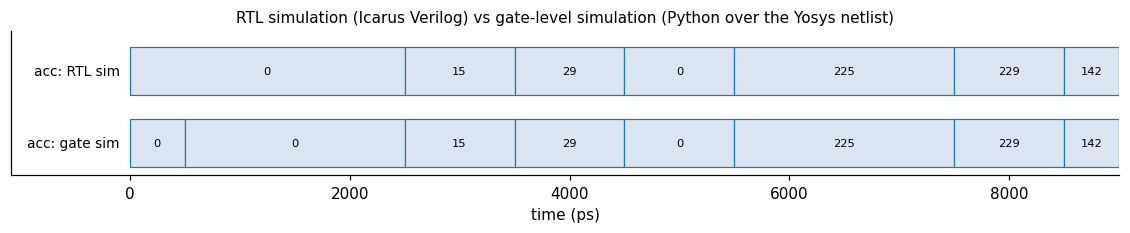

busiest nets  toggles  toggles/cycle
------------------------------------
n71           190      0.92         
n109          186      0.90         
n54           185      0.89         
n57           184      0.89         
n112          181      0.87         
n115          180      0.87         

Data nets toggle 0.1-0.9 times per cycle under this random stimulus; the clock (stepped by clock(),
not listed) toggles exactly twice. With alpha = toggles per cycle / 2 (each edge costs 1/2 C V^2),
that is alpha = 0.05-0.45 for data and 1.0 for the clock -- the alpha in P = alpha*C*V^2*f, and it
depends on the *workload*, not just the netlist. Caveat: this is a zero-delay simulation, so it
cannot see glitches (spurious transitions from unequal arrival times), which in multipliers and
adders often add tens of percent to switching power. Real activity comes from delay-annotated sims.


In [9]:
def fn_to_python(expr):
    e = expr.replace("!", " not ").replace("&", " and ").replace("|", " or ").replace("^", " != ")
    return re.sub(r"(\w+)'", r" not \1", e).strip()


class GateSim:
    '''Zero-delay gate-level simulator driven by the Liberty cell functions.'''
    def __init__(self, nl):
        self.nl, self.order = nl, nl.topo_comb()
        self.fn = {inst: {p: compile(fn_to_python(d["function"]), "<lib>", "eval")
                          for p, d in nl.lib[c["type"]]["pins"].items() if d["dir"] == "output"}
                   for inst, c in nl.cells.items() if not nl.is_seq(inst)}
        self.state = {inst: 0 for inst in nl.cells if nl.is_seq(inst)}
        self.val = {n: 0 for n in nl.nets}; self.val["const_1"] = 1
        self.toggles = Counter()

    def _clear_active(self, inst):
        ff = self.nl.lib[self.nl.cells[inst]["type"]]["ff"]
        if not ff["clear"]:
            return False
        v = self.val[self.nl.cells[inst]["conn"][ff["clear"].strip("!")]]
        return v == (0 if ff["clear"].startswith("!") else 1)

    def eval_comb(self, inputs):
        nl, old = self.nl, dict(self.val)
        for port, v in inputs.items():
            self.val[nl.ports[port][1]] = v
        for inst in self.state:                                   # asynchronous clear acts immediately
            if self._clear_active(inst):
                self.state[inst] = 0
        for inst, q in self.state.items():                        # flop outputs
            c = nl.cells[inst]
            for p, d in nl.lib[c["type"]]["pins"].items():
                if d["dir"] == "output" and p in c["conn"]:
                    self.val[c["conn"][p]] = q if d["function"] == "IQ" else 1 - q
        for inst in self.order:                                   # combinational cells, in order
            c = nl.cells[inst]
            env = {p: bool(self.val[c["conn"][p]]) for p, d in nl.lib[c["type"]]["pins"].items() if d["dir"] == "input"}
            for p, code_ in self.fn[inst].items():
                if p in c["conn"]:
                    self.val[c["conn"][p]] = int(eval(code_, {}, env))
        for n in nl.nets:
            if self.val[n] != old[n]:
                self.toggles[n] += 1

    def clock(self):                                              # rising edge: flops sample D
        for inst in self.state:
            c = self.nl.cells[inst]; ff = self.nl.lib[c["type"]]["ff"]
            self.state[inst] = 0 if self._clear_active(inst) else self.val[c["conn"][ff["next_state"]]]

    def output(self, port):
        return self.val[self.nl.ports[port][1]]


def stimulus_from_vcd(waves, t_end_ps):
    '''Sample the testbench inputs just before each rising clock edge (edges read from the VCD itself).'''
    def value_at(name, t):
        v = 0
        for tt, vv in waves[name]:
            if tt <= t:
                v = vv
        return v or 0
    cycles = []
    for edge in [t for t, v in waves["tb.clk"] if v == 1 and t < t_end_ps]:
        t = edge - 1
        inp = {"rst_n": value_at("tb.rst_n", t), "clear": value_at("tb.clear", t), "en": value_at("tb.en", t)}
        a, b = value_at("tb.a", t), value_at("tb.b", t)
        inp.update({f"a[{i}]": (a >> i) & 1 for i in range(4)})
        inp.update({f"b[{i}]": (b >> i) & 1 for i in range(4)})
        cycles.append((edge, inp, value_at("tb.acc", edge + 1)))
    return cycles


t_end = max(t for t, _ in waves["tb.clk"])
stim = stimulus_from_vcd(waves, t_end)
SIM = GateSim(NL)
mismatch, gate_trace = 0, []
for edge, inp, rtl_acc in stim:
    SIM.eval_comb(inp); SIM.clock(); SIM.eval_comb(inp)          # settle -> edge -> settle
    acc = sum(SIM.output(f"acc[{i}]") << i for i in range(8))
    if not gate_trace or gate_trace[-1][1] != acc:
        gate_trace.append((edge, acc))
    mismatch += acc != rtl_acc
print(f"{len(stim)} clock cycles replayed through the gate netlist: {mismatch} mismatches vs the RTL simulation")
print(f"nets that toggled at least once: {len(SIM.toggles)} / {len(NL.nets)}")

both = {"acc: RTL sim": waves["tb.acc"], "acc: gate sim": [(0, 0)] + gate_trace}
plot_waves(both, list(both), 9000, title="RTL simulation (Icarus Verilog) vs gate-level simulation (Python over the Yosys netlist)")
plt.show()

top = SIM.toggles.most_common(6)
show_table(["busiest nets", "toggles", "toggles/cycle"], [[n, t, t / len(stim)] for n, t in top], "{:.2f}")
print("\nData nets toggle 0.1-0.9 times per cycle under this random stimulus; the clock (stepped by clock(),")
print("not listed) toggles exactly twice. With alpha = toggles per cycle / 2 (each edge costs 1/2 C V^2),")
print("that is alpha = 0.05-0.45 for data and 1.0 for the clock -- the alpha in P = alpha*C*V^2*f, and it")
print("depends on the *workload*, not just the netlist. Caveat: this is a zero-delay simulation, so it")
print("cannot see glitches (spurious transitions from unequal arrival times), which in multipliers and")
print("adders often add tens of percent to switching power. Real activity comes from delay-annotated sims.")

## 6. Constraints and pre-layout static timing analysis

**Why this stage exists.** The netlist has no notion of speed until you *ask* for one. The **SDC** file
(Synopsys Design Constraints — Tcl, the universal format) says what the clock is and how much of the
period the outside world consumes. Then **static timing analysis** answers, for every register-to-register
path, whether the data arrives before the setup window — with no simulation, by propagating worst-case
arrival times through the graph. At this point wires have no length, so loads are just pin capacitances:
this is *pre-layout* timing, the optimistic number synthesis reports.

Our STA is ~70 lines: for each cell, delay = bilinear interpolation in its Liberty tables at (input slew,
output load); arrival = max over inputs; slack at each flop's D pin = (period + clock arrival − setup) −
arrival. The output is formatted like a PrimeTime report because the format is worth knowing.

What we leave out, so you know it exists: a real timer checks **two** inequalities per path — setup
(data too slow) *and* **hold** (data too fast: the shortest path must not overtake the same clock edge;
period-independent, fixed by inserting delay buffers) — across dozens of process/voltage/temperature
corners, with **on-chip-variation** derates and **crosstalk**-induced delay from neighbouring wires. We do
setup only, at one corner, nominal.


# mac4.sdc -- the entire timing contract with the outside world
create_clock -name clk -period 1.0 [get_ports clk]                 ;# 1 GHz
set_clock_transition 0.03 [get_clocks clk]                         ;# 30 ps clock edges at the flops
set DATA_IN [remove_from_collection [all_inputs] [get_ports clk]]  ;# the clock port is not a data input
set_input_delay  0.10 -clock clk $DATA_IN                          ;# inputs arrive 100 ps after the edge
set_output_delay 0.10 -clock clk [all_outputs]                     ;# outputs must be ready 100 ps early
set_input_transition 0.02 $DATA_IN                                 ;# 20 ps edges from outside

=== pre-layout STA (no wires yet) ===
Startpoint: b[3]   Endpoint: U127/D
Clock: clk, period 1000 ps

point                              incr (ps)  path (ps) slew (ps)
input external delay                   100.0      100.0          
U18 (AND4_X1) -> n40                    75.0      175.0      22.9
U20 (OR3_X1) -> n42                     87.9   

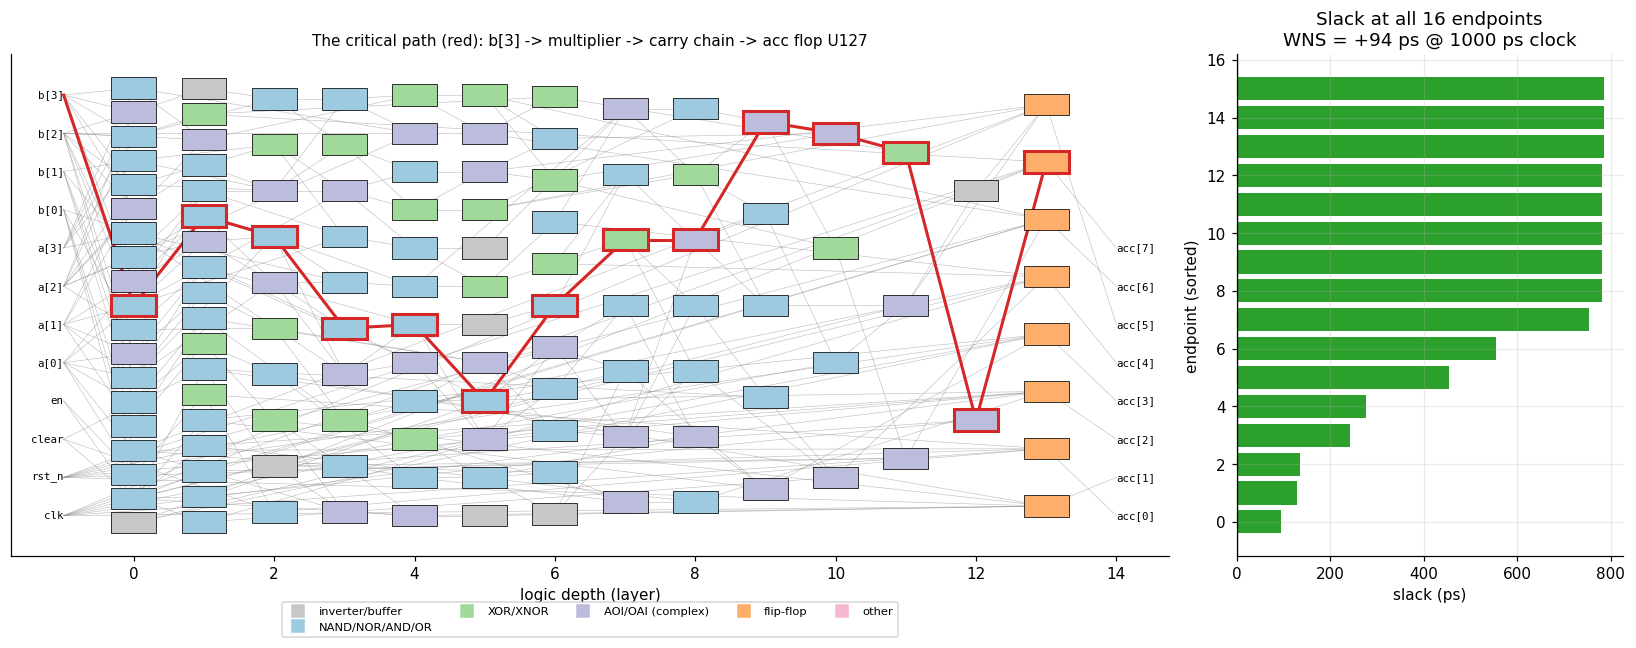

In [10]:
SDC = '''\
# mac4.sdc -- the entire timing contract with the outside world
create_clock -name clk -period 1.0 [get_ports clk]                 ;# 1 GHz
set_clock_transition 0.03 [get_clocks clk]                         ;# 30 ps clock edges at the flops
set DATA_IN [remove_from_collection [all_inputs] [get_ports clk]]  ;# the clock port is not a data input
set_input_delay  0.10 -clock clk $DATA_IN                          ;# inputs arrive 100 ps after the edge
set_output_delay 0.10 -clock clk [all_outputs]                     ;# outputs must be ready 100 ps early
set_input_transition 0.02 $DATA_IN                                 ;# 20 ps edges from outside
'''
with open(os.path.join(WORK, "mac4.sdc"), "w") as f:
    f.write(SDC)
print(SDC)
T_CLK = float(re.search(r"-period\s+([\d.]+)", SDC).group(1))
IN_DELAY = float(re.search(r"set_input_delay\s+([\d.]+)", SDC).group(1))
OUT_DELAY = float(re.search(r"set_output_delay\s+([\d.]+)", SDC).group(1))
IN_SLEW = float(re.search(r"set_input_transition\s+([\d.]+)", SDC).group(1))
CK_SLEW = float(re.search(r"set_clock_transition\s+([\d.]+)", SDC).group(1))


def run_sta(nl, T, wire_cap_fF=None, wire_delay_ns=None, clock_arrival=None):
    '''Graph-based setup STA with NLDM tables. Returns arrival per net, slack per endpoint, WNS/TNS, critical path.'''
    wire_cap_fF, wire_delay_ns, clock_arrival = wire_cap_fF or {}, wire_delay_ns or {}, clock_arrival or {}
    lib = nl.lib
    # IO timing is relative to the clock as seen by the neighbouring blocks' flops, which sit on the
    # same clock tree: give inputs/outputs the mean insertion delay (0 for an ideal clock).
    io_latency = float(np.mean(list(clock_arrival.values()))) if clock_arrival else 0.0
    def load_of(net):
        return sum(lib[nl.cells[i]["type"]]["pins"][p]["cap"] for i, p in nl.nets[net]["sinks"] if i != "PO") + wire_cap_fF.get(net, 0.0)
    def arc_delay(arc, s_in, L):
        t = arc["tables"]
        return (max(nldm(t["cell_rise"], s_in, L), nldm(t["cell_fall"], s_in, L)),
                max(nldm(t["rise_transition"], s_in, L), nldm(t["fall_transition"], s_in, L)))
    arrival = {}                                             # net -> (time, slew, previous net, via cell)
    for port, (d, n) in nl.ports.items():
        if d == "input":
            arrival[n] = (IN_DELAY + io_latency if port not in ("clk", "rst_n") else 0.0, IN_SLEW, None, port)
    for k in ("const_0", "const_1"):
        arrival[k] = (0.0, IN_SLEW, None, None)
    for inst, c in nl.cells.items():                         # launch: clock edge -> Q
        if nl.is_seq(inst):
            for arc in lib[c["type"]]["arcs"]:
                if arc["type"] == "rising_edge" and arc["pin"] in c["conn"]:
                    net = c["conn"][arc["pin"]]
                    d, s = arc_delay(arc, CK_SLEW, load_of(net))
                    arrival[net] = (clock_arrival.get(inst, 0.0) + d, s, None, inst)
    for inst in nl.topo_comb():                              # propagate through combinational cells
        c = nl.cells[inst]
        for arc in lib[c["type"]]["arcs"]:
            if arc["pin"] in c["conn"] and arc["related"] in c["conn"] and c["conn"][arc["related"]] in arrival:
                onet, inet = c["conn"][arc["pin"]], c["conn"][arc["related"]]
                t_in, s_in, _, _ = arrival[inet]
                d, s = arc_delay(arc, s_in, load_of(onet))
                cand = (t_in + wire_delay_ns.get(inet, 0.0) + d, s, inet, inst)
                if onet not in arrival or cand[0] > arrival[onet][0]:
                    arrival[onet] = cand
    slack, detail = {}, {}
    for inst, c in nl.cells.items():                         # capture: setup check at every D pin
        if nl.is_seq(inst):
            for arc in lib[c["type"]]["arcs"]:
                if arc["type"] == "setup_rising" and arc["pin"] in c["conn"] and c["conn"][arc["pin"]] in arrival:
                    dnet = c["conn"][arc["pin"]]
                    t, s, _, _ = arrival[dnet]
                    t += wire_delay_ns.get(dnet, 0.0)
                    tsu = max(nldm(arc["tables"]["rise_constraint"], s, CK_SLEW), nldm(arc["tables"]["fall_constraint"], s, CK_SLEW))
                    req = T + clock_arrival.get(inst, 0.0) - tsu
                    slack[(inst, "D")] = req - t
                    detail[(inst, "D")] = (t, req, tsu, dnet, clock_arrival.get(inst, 0.0), io_latency)
    for port, (d, n) in nl.ports.items():
        if d == "output" and n in arrival:
            t = arrival[n][0] + wire_delay_ns.get(n, 0.0)
            req = T - OUT_DELAY + io_latency
            slack[("PO", port)] = req - t; detail[("PO", port)] = (t, req, OUT_DELAY, n, io_latency, io_latency)
    worst = min(slack, key=slack.get)
    path, n = [], detail[worst][3]
    while n is not None:                                     # trace the critical path backwards
        t, s, prev, via = arrival[n]
        path.append((n, t + wire_delay_ns.get(n, 0.0), s, via)); n = prev
    return dict(arrival=arrival, slack=slack, detail=detail, wns=min(slack.values()),
                tns=sum(min(0, s) for s in slack.values()), worst=worst, path=path[::-1], T=T,
                io_latency=io_latency)


def timing_report(nl, r, title):
    '''A PrimeTime-flavoured path report for the worst endpoint.'''
    W = 34
    def row(label, incr, tot, slew=""):
        return f"{label[:W]:<{W}}{incr:>10}{tot:>11}{slew:>10}"
    t, req, tsu, _, cap_lat, io_lat = r["detail"][r["worst"]]
    start = r["path"][0][3]
    lines = [f"=== {title} ===", f"Startpoint: {start}   Endpoint: {r['worst'][0]}/{r['worst'][1]}",
             f"Clock: clk, period {r['T']*1e3:.0f} ps", "", row("point", "incr (ps)", "path (ps)", "slew (ps)")]
    prev = 0.0
    if start in nl.cells:                                   # launched from a flop
        lines.append(row("clock network latency (launch)", f"{cap_lat*1e3:.1f}", f"{cap_lat*1e3:.1f}"))
        prev = cap_lat
    elif io_lat:                                            # launched from an input port
        lines.append(row("clock network latency (I/O ref)", f"{io_lat*1e3:.1f}", f"{io_lat*1e3:.1f}"))
        lines.append(row("input external delay", f"{IN_DELAY*1e3:.1f}", f"{(io_lat + IN_DELAY)*1e3:.1f}"))
        prev = io_lat + IN_DELAY
    else:
        lines.append(row("input external delay", f"{IN_DELAY*1e3:.1f}", f"{IN_DELAY*1e3:.1f}"))
        prev = IN_DELAY
    for net, tt, s, via in r["path"]:
        cell = nl.cells[via]["type"] if via in nl.cells else "input port"
        if tt - prev > 1e-9 or via in nl.cells:
            lines.append(row(f"{via} ({cell}) -> {net}", f"{(tt - prev)*1e3:.1f}", f"{tt*1e3:.1f}", f"{s*1e3:.1f}"))
        prev = tt
    lines += ["", row("data arrival time", "", f"{t*1e3:.1f}"), "",
              row("clock edge", f"{r['T']*1e3:.1f}", f"{r['T']*1e3:.1f}"),
              row("clock network latency (capture)", f"{cap_lat*1e3:.1f}", f"{(r['T'] + cap_lat)*1e3:.1f}"),
              row("library setup time" if r["worst"][0] != "PO" else "output external delay", f"-{tsu*1e3:.1f}", f"{req*1e3:.1f}"),
              row("data required time", "", f"{req*1e3:.1f}"),
              row("slack", "", f"{(req - t)*1e3:+.1f}", "MET" if req >= t else "VIOLATED"), "",
              f"WNS = {r['wns']*1e3:+.1f} ps   TNS = {r['tns']*1e3:+.1f} ps   endpoints = {len(r['slack'])}"]
    return "\n".join(lines)


STA_PRE = run_sta(NL, T_CLK)
print(timing_report(NL, STA_PRE, "pre-layout STA (no wires yet)"))
with open(os.path.join(WORK, "timing_prelayout.rpt"), "w") as f:
    f.write(timing_report(NL, STA_PRE, "pre-layout"))
crit_cells = {v for *_, v in STA_PRE["path"] if v in NL.cells} | {STA_PRE["worst"][0]}
arr_worst = STA_PRE["detail"][STA_PRE["worst"]][0]
print(f"\nfmax estimate (pre-layout) = 1 / (arrival + setup) = {1e3/(arr_worst + STA_PRE['detail'][STA_PRE['worst']][2]):.0f} MHz")

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [3, 1]})
draw_gate_graph(NL, POS, axes[0], highlight_edges=path_edges(NL, STA_PRE), highlight_cells=crit_cells,
                title=f"The critical path (red): {STA_PRE['path'][0][3]} -> multiplier -> carry chain -> acc flop {STA_PRE['worst'][0]}")
sl = np.array(sorted(STA_PRE["slack"].values())) * 1e3
axes[1].barh(range(len(sl)), sl, color=["#d62728" if s < 0 else "#2ca02c" for s in sl])
axes[1].axvline(0, c="k", lw=0.8); axes[1].set_xlabel("slack (ps)"); axes[1].set_ylabel("endpoint (sorted)")
axes[1].set_title(f"Slack at all {len(sl)} endpoints\nWNS = {STA_PRE['wns']*1e3:+.0f} ps @ {T_CLK*1e3:.0f} ps clock")
plt.tight_layout(); plt.show()

## 7. Floorplan: how big, what shape, where do the pins go

**Why this stage exists.** Physical design starts by deciding the *geometry* the netlist will live in.
The core area follows from total cell area and a target **utilization** (60–75%; the rest is whitespace
for buffers, routing, and later fixes). Standard cells are all one height (1.4 µm in Nangate45) and snap
into **rows**; horizontally they snap to **sites** (0.19 µm). Power (VDD) and ground (VSS) **rails** run
along each row boundary, shared by the row above and below (rows alternate orientation for this). IO pins
are assigned to the boundary. In a real SoC block this stage also places SRAM macros and builds the power
grid (rings and straps on the upper metals, sized so **IR drop** stays under a few percent of VDD) — and its
quality bounds everything downstream: no optimizer fixes a bad floorplan.


cell area 173.4 um^2 at 60% target utilization ->
core 15.96 x 18.20 um = 290 um^2, 13 rows x 84 sites, actual utilization 60%


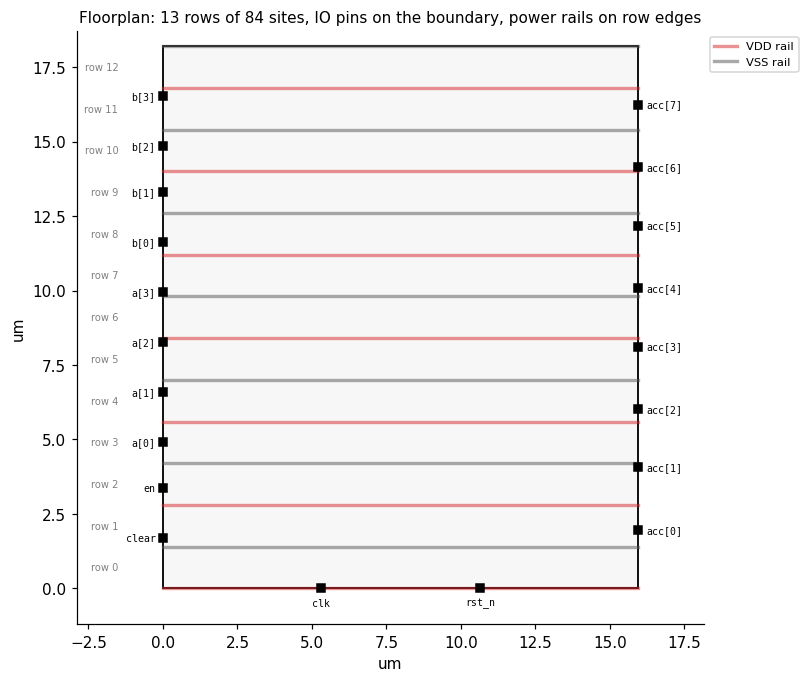

For scale: this whole block is 16 x 18 um. A human hair is ~70 um wide.


In [11]:
ROW_H, SITE_W = 1.4, 0.19                     # um, from the Nangate45 tech LEF (SITE ... SIZE 0.19 BY 1.4)
M2_PITCH, M3_PITCH = 0.19, 0.14               # um, metal2 (vertical) / metal3 (horizontal) track pitches
TRACKS_PER_ROW = int(round(ROW_H / M3_PITCH))  # 10 horizontal tracks per row


class Floorplan:
    def __init__(self, nl, utilization=0.6, aspect=1.0):
        self.nl = nl
        self.width = {i: max(1, round(nl.lib[c["type"]]["area"] / ROW_H / SITE_W)) * SITE_W
                      for i, c in nl.cells.items()}
        cell_area = sum(self.width.values()) * ROW_H
        core = cell_area / utilization
        self.n_rows = int(np.ceil(np.sqrt(core * aspect) / ROW_H))
        self.core_h = self.n_rows * ROW_H
        self.n_sites = int(np.ceil(core / self.core_h / SITE_W))
        self.core_w = self.n_sites * SITE_W
        self.utilization = cell_area / (self.core_w * self.core_h)
        # IO pins: data inputs on the left edge, outputs on the right, clock/reset at the bottom
        self.io = {}
        ins = [p for p, (d, n) in nl.ports.items() if d == "input" and p not in ("clk", "rst_n")]
        outs = [p for p, (d, n) in nl.ports.items() if d == "output"]
        for k, p in enumerate(ins):
            self.io[p] = (0.0, round(self.core_h * (k + 1) / (len(ins) + 1) / M3_PITCH) * M3_PITCH)
        for k, p in enumerate(outs):
            self.io[p] = (self.core_w, round(self.core_h * (k + 1) / (len(outs) + 1) / M3_PITCH) * M3_PITCH)
        for k, p in enumerate([q for q in ("clk", "rst_n") if q in nl.ports]):
            self.io[p] = (round(self.core_w * (k + 1) / 3 / SITE_W) * SITE_W, 0.0)

    def draw(self, ax, title="Floorplan"):
        ax.add_patch(Rectangle((0, 0), self.core_w, self.core_h, fc="#f7f7f7", ec="k", lw=1.2, zorder=0))
        for r in range(self.n_rows + 1):
            y = r * ROW_H
            ax.plot([0, self.core_w], [y, y], c="#d62728" if r % 2 == 0 else "#555555", lw=2.2, alpha=0.5, zorder=1)
        for r in range(self.n_rows):
            ax.text(-1.5, r * ROW_H + ROW_H / 2, f"row {r}", ha="right", va="center", fontsize=6.5, color="gray")
        for p, (x, y) in self.io.items():
            ax.plot(x, y, "s", c="k", ms=5, zorder=5)
            dx = -0.25 if x == 0 else (0.25 if x == self.core_w else 0)
            ax.text(x + dx, y - (0.5 if y == 0 else 0), p, ha="right" if x == 0 else ("left" if dx > 0 else "center"),
                    va="center", fontsize=6.5, family="monospace")
        ax.plot([], [], c="#d62728", lw=2.2, alpha=0.5, label="VDD rail"); ax.plot([], [], c="#555555", lw=2.2, alpha=0.5, label="VSS rail")
        ax.legend(fontsize=7.5, loc="upper left", bbox_to_anchor=(1.0, 1.0))
        ax.set_aspect("equal"); ax.grid(False)
        ax.set_xlim(-2.9, self.core_w + 2.2); ax.set_ylim(-1.2, self.core_h + 0.5)
        ax.set_xlabel("um"); ax.set_ylabel("um"); ax.set_title(title, fontsize=10)


FP = Floorplan(NL, utilization=0.6)
print(f"cell area {sum(FP.width.values()) * ROW_H:.1f} um^2 at 60% target utilization ->")
print(f"core {FP.core_w:.2f} x {FP.core_h:.2f} um = {FP.core_w * FP.core_h:.0f} um^2, "
      f"{FP.n_rows} rows x {FP.n_sites} sites, actual utilization {FP.utilization:.0%}")
fig, ax = plt.subplots(figsize=(8, 7))
FP.draw(ax, f"Floorplan: {FP.n_rows} rows of {FP.n_sites} sites, IO pins on the boundary, power rails on row edges")
plt.show()
print(f"For scale: this whole block is {FP.core_w:.0f} x {FP.core_h:.0f} um. A human hair is ~70 um wide.")

## 8. Placement: every cell gets an (x, y)

**Why this stage exists.** Wire length is the proxy for everything physical: longer wires mean more
capacitance (slower, more power) and more routing demand (congestion). Placement chooses a legal position
for each cell — snapped to a row and a site, no overlaps — to minimize total wirelength, with critical nets
weighted more. Modern placers (OpenROAD's RePlAce, Innovus GigaPlace) solve this as a continuous
electrostatics problem over millions of cells; here we use **simulated annealing** over pairwise swaps,
which is what placers used in the 1980s–90s and is perfectly readable.

Objective: **HPWL** — half-perimeter of each net's bounding box, summed. Watch it fall.


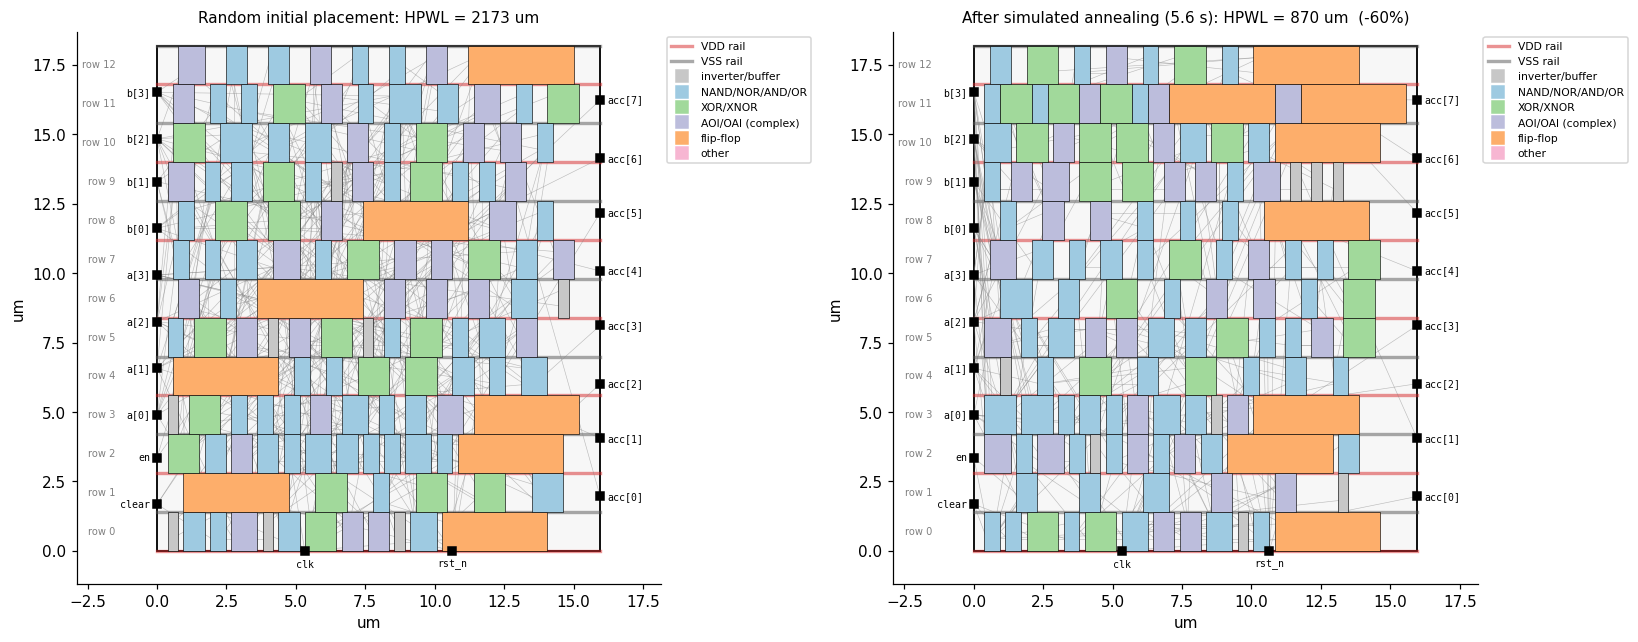

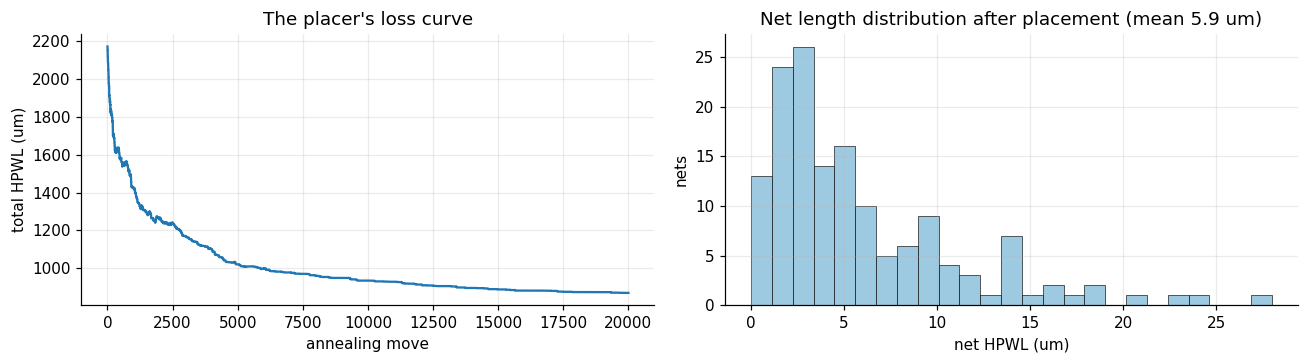

Same netlist, same area, 60% less wire: placement is where 'where' starts to matter more than 'what'.


In [12]:
class Placement:
    def __init__(self, fp, seed=0):
        self.fp, self.nl, self.rng = fp, fp.nl, np.random.default_rng(seed)
        insts = list(self.nl.cells); self.rng.shuffle(insts)
        self.rows = [[] for _ in range(fp.n_rows)]
        used = [0.0] * fp.n_rows
        for i in insts:                                    # random initial placement: each cell to the emptiest row
            r = int(np.argmin(used)); self.rows[r].append(i); used[r] += fp.width[i]
        assert max(used) <= fp.core_w - 2 * SITE_W, "a row overflowed the core: raise the utilization target"
        self.inst2nets = defaultdict(set)
        for n, d in self.nl.nets.items():
            for i, p in ([d["driver"]] if d["driver"] else []) + d["sinks"]:
                if i not in ("PI", "PO"):
                    self.inst2nets[i].add(n)
        self.legalize()

    def legalize(self):
        '''Pack each row left to right, spreading whitespace evenly between cells.'''
        self.xy, self.row_of = {}, {}
        for r, row in enumerate(self.rows):
            used = sum(self.fp.width[i] for i in row)
            gap = np.floor(max(0.0, (self.fp.core_w - used) / (len(row) + 1)) / SITE_W) * SITE_W
            x = max(gap, 2 * SITE_W)                               # columns 0-1: IO pins + their routing channel
            for i in row:
                self.xy[i] = (x, r * ROW_H); self.row_of[i] = r
                x += self.fp.width[i] + gap

    def pin_xy(self, inst, pin):
        '''Pin k of a cell sits at site k//2, on track 3 (even k) or 7 (odd k) of its row.'''
        pins = list(self.nl.lib[self.nl.cells[inst]["type"]]["pins"])
        k = pins.index(pin)
        x, y = self.xy[inst]
        return (x + (k // 2 + 0.5) * SITE_W, y + (3 if k % 2 == 0 else 7) * M3_PITCH)

    def net_points(self, net):
        d = self.nl.nets[net]
        pts = []
        for i, p in ([d["driver"]] if d["driver"] else []) + d["sinks"]:
            pts.append(self.fp.io[p] if i in ("PI", "PO") else self.pin_xy(i, p))
        return pts

    def hpwl(self, nets=None):
        tot = 0.0
        for n in sorted(nets if nets is not None else self.nl.nets):   # fixed order -> bit-exact, reproducible sums
            pts = self.net_points(n)
            if len(pts) >= 2:
                xs, ys = zip(*pts); tot += (max(xs) - min(xs)) + (max(ys) - min(ys))
        return tot

    def anneal(self, iters=15000, T0=4.0, T1=0.02):
        insts = list(self.nl.cells); cur = self.hpwl(); hist = [cur]
        for it in range(iters):
            T = T0 * (T1 / T0) ** (it / iters)
            a, b = self.rng.choice(insts, 2, replace=False)
            u = self.rng.random()                                      # always drawn: RNG stream independent of dE
            ra, rb = self.row_of[a], self.row_of[b]
            wa, wb = self.fp.width[a], self.fp.width[b]
            limit = self.fp.core_w - 2 * SITE_W                        # the IO channel is not available to cells
            if ra != rb and (sum(self.fp.width[i] for i in self.rows[ra]) - wa + wb > limit or
                             sum(self.fp.width[i] for i in self.rows[rb]) - wb + wa > limit):
                hist.append(cur); continue                             # the swap would not fit in the row
            # swapping re-packs both rows, so every net touching either row can change length
            nets = set().union(*(self.inst2nets[i] for i in self.rows[ra] + self.rows[rb]))
            before = self.hpwl(nets)
            ia, ib = self.rows[ra].index(a), self.rows[rb].index(b)
            self.rows[ra][ia], self.rows[rb][ib] = b, a; self.legalize()
            dE = self.hpwl(nets) - before
            if dE > 0 and u >= np.exp(-dE / T):
                self.rows[ra][ia], self.rows[rb][ib] = a, b; self.legalize()    # reject
            else:
                cur += dE
            hist.append(cur)
        assert abs(cur - self.hpwl()) < 1e-6                           # the bookkeeping is exact
        return hist

    def draw(self, ax, flylines=True, title="", highlight=()):
        self.fp.draw(ax, title)
        for inst, (x, y) in self.xy.items():
            fam = family(self.nl.cells[inst]["type"])
            ax.add_patch(Rectangle((x, y), self.fp.width[inst], ROW_H, fc=FAM_COLOR[fam],
                                   ec="#d62728" if inst in highlight else "k", lw=1.5 if inst in highlight else 0.4, zorder=3))
        if flylines:
            for n in self.nl.nets:
                pts = self.net_points(n)
                if len(pts) >= 2:
                    x0, y0 = pts[0]
                    for x1, y1 in pts[1:]:
                        ax.plot([x0, x1], [y0, y1], c="gray", lw=0.4, alpha=0.5, zorder=2)
        ax.get_legend().remove()
        for fam, col in FAM_COLOR.items():
            ax.plot([], [], "s", c=col, ms=8, label=fam)
        ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))


PL = Placement(FP, seed=4)
hpwl0 = PL.hpwl()
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
PL.draw(axes[0], title=f"Random initial placement: HPWL = {hpwl0:.0f} um")
t0 = time.time(); hist = PL.anneal(iters=20000); dt = time.time() - t0
PL.draw(axes[1], title=f"After simulated annealing ({dt:.1f} s): HPWL = {PL.hpwl():.0f} um  (-{(1 - PL.hpwl()/hpwl0)*100:.0f}%)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot(hist); axes[0].set_xlabel("annealing move"); axes[0].set_ylabel("total HPWL (um)"); axes[0].set_title("The placer's loss curve")
lens = [PL.hpwl([n]) for n in NL.nets]
axes[1].hist(lens, bins=25, color="#9ecae1", ec="k", lw=0.4); axes[1].set_xlabel("net HPWL (um)"); axes[1].set_ylabel("nets")
axes[1].set_title(f"Net length distribution after placement (mean {np.mean(lens):.1f} um)")
plt.tight_layout(); plt.show()
print(f"Same netlist, same area, {(1 - PL.hpwl()/hpwl0)*100:.0f}% less wire: placement is where 'where' starts to matter more than 'what'.")

## 9. Clock tree synthesis: delivering the same edge everywhere

**Why this stage exists.** The clock net is special: it fans out to *every* flip-flop, and STA assumed the
edge arrives everywhere at the same instant. Driving 8 flops (or 800,000) from one pin would be hopelessly
slow and the arrival times would differ by hundreds of picoseconds across the block — that difference,
**skew**, eats directly into the cycle budget. CTS builds a balanced tree of **clock buffers** so every
flop sees a similar **insertion delay**. It happens *after* placement (it needs flop positions) and
*before* routing (the tree's wires are routed first, with priority).

Here: one root buffer at the clock pin, two leaf buffers at the centroids of two flop clusters, each
driving four flops. Then we compute per-flop clock arrival from real buffer tables plus wire RC, and hand
that **propagated clock** back to the STA — where launch and capture flops now have *different* clock
arrivals, i.e. skew. On an 8-flop block the tree is overkill (one buffer could drive them all; the skew
will be a couple of picoseconds) — we build it to show the mechanism, and to make the ~90 ps of
**insertion delay** that every real STA must account for visible. Note too that skew cuts both ways: a
late capture clock *helps* setup and *hurts* hold, which is why CTS is always followed by a hold-fixing
pass in a real flow.


inserted: ['CTS_root', 'CTS_leaf0', 'CTS_leaf1'] | clock nets: ['clk', 'clk_root', 'clk_leaf0', 'clk_leaf1']


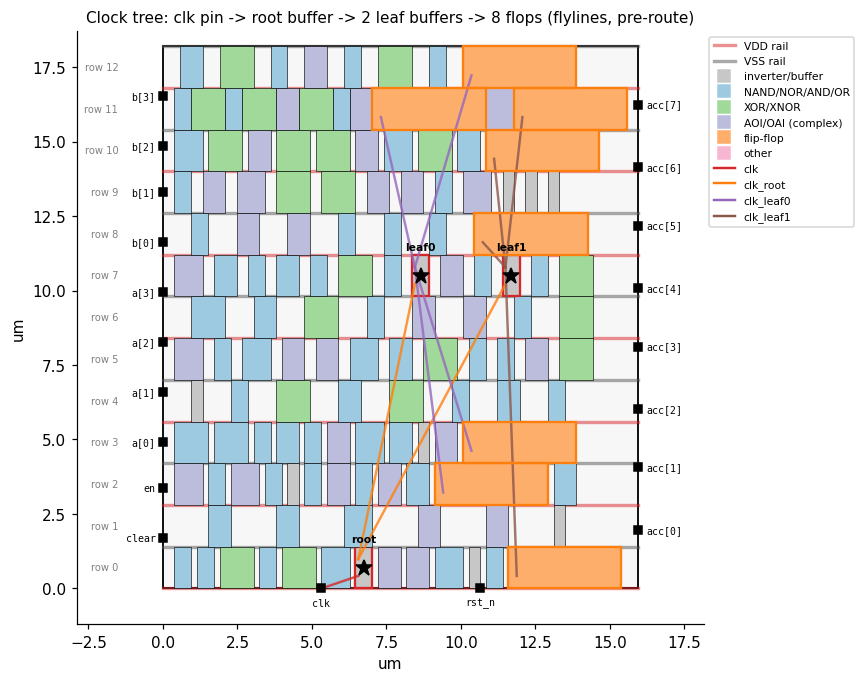

Before routing we can only estimate the tree's wire lengths; after section 10 we will compute
the real per-flop clock arrival (insertion delay) and the skew between flops.


In [13]:
def remove_clock_tree(nl, pl):
    '''Undo build_clock_tree (so the cell below can be re-run safely).'''
    clk_net = nl.ports["clk"][1]
    for inst in [i for i in nl.cells if i.startswith("CTS_")]:
        del nl.cells[inst]
        for row in pl.rows:
            if inst in row:
                row.remove(inst)
        pl.inst2nets.pop(inst, None); pl.fp.width.pop(inst, None)
    for n in [n for n in nl.nets if n.startswith("clk_")]:
        del nl.nets[n]
    nl.nets[clk_net]["sinks"] = []
    for f in [i for i in nl.cells if nl.is_seq(i)]:
        nl.cells[f]["conn"]["CK"] = clk_net; nl.nets[clk_net]["sinks"].append((f, "CK"))
    pl.legalize()


def build_clock_tree(nl, pl, n_leaves=2):
    '''Insert CLKBUF_X1 cells: root at the clk pin, leaves at cluster centroids; rewire the flops' CK pins.'''
    if any(i.startswith("CTS_") for i in nl.cells):
        remove_clock_tree(nl, pl)
    flops = [i for i in nl.cells if nl.is_seq(i)]
    xy = np.array([pl.pin_xy(f, "CK") for f in flops])
    # tiny 1-D k-means on x (the flops sit in a band); good enough for two clusters
    order = np.argsort(xy[:, 0]); groups = np.array_split(order, n_leaves)
    clk_net = nl.ports["clk"][1]
    nl.nets[clk_net]["sinks"] = []                                    # clk pin now drives only the root
    nl.add_cell("CTS_root", "CLKBUF_X1", {"A": clk_net, "Z": "clk_root"})
    targets = {"CTS_root": (pl.fp.io["clk"][0], ROW_H / 2)}
    for g, idx in enumerate(groups):
        leaf, net = f"CTS_leaf{g}", f"clk_leaf{g}"
        nl.add_cell(leaf, "CLKBUF_X1", {"A": "clk_root", "Z": net})
        for k in idx:
            nl.cells[flops[k]]["conn"]["CK"] = net
            nl.nets[net]["sinks"].append((flops[k], "CK"))
        targets[leaf] = tuple(xy[idx].mean(axis=0))
    # place the new cells: insert into the row nearest the target, at the matching x position
    for inst, (tx, ty) in targets.items():
        pl.fp.width[inst] = max(1, round(nl.lib["CLKBUF_X1"]["area"] / ROW_H / SITE_W)) * SITE_W
        r = int(np.clip(round(ty / ROW_H - 0.5), 0, pl.fp.n_rows - 1))
        row = pl.rows[r]
        k = next((j for j, i in enumerate(row) if pl.xy[i][0] > tx), len(row))
        row.insert(k, inst)
        pl.inst2nets[inst] = {n for n, d in nl.nets.items() if (inst, "A") in d["sinks"] or d["driver"] == (inst, "Z")}
        pl.legalize()                                               # re-pack the row around the new cell
    return ["CTS_root"] + [f"CTS_leaf{g}" for g in range(n_leaves)]


CTS_CELLS = build_clock_tree(NL, PL)
CLK_NETS = ["clk", "clk_root"] + [f"clk_leaf{g}" for g in range(2)]
print("inserted:", CTS_CELLS, "| clock nets:", CLK_NETS)

fig, ax = plt.subplots(figsize=(8.5, 7))
PL.draw(ax, flylines=False, title="Clock tree: clk pin -> root buffer -> 2 leaf buffers -> 8 flops (flylines, pre-route)",
        highlight=CTS_CELLS)
for net, col in zip(CLK_NETS, ["#d62728", "#ff7f0e", "#9467bd", "#8c564b"]):
    pts = PL.net_points(net)
    for x1, y1 in pts[1:]:
        ax.plot([pts[0][0], x1], [pts[0][1], y1], c=col, lw=1.6, zorder=4, alpha=0.8)
    ax.plot([], [], c=col, lw=1.6, label=net)
for inst in CTS_CELLS:
    x, y = PL.xy[inst]
    ax.plot(x + FP.width[inst] / 2, y + ROW_H / 2, "*", c="k", ms=11, zorder=6)
    ax.text(x + FP.width[inst] / 2, y + ROW_H + 0.15, inst.replace("CTS_", ""), ha="center", fontsize=7, weight="bold", zorder=6)
for f in [i for i in NL.cells if NL.is_seq(i)]:
    x, y = PL.xy[f]; ax.add_patch(Rectangle((x, y), FP.width[f], ROW_H, fc="none", ec="#ff7f0e", lw=1.5, zorder=5))
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.show()
print("Before routing we can only estimate the tree's wire lengths; after section 10 we will compute")
print("the real per-flop clock arrival (insertion delay) and the skew between flops.")

## 10. Routing: turning flylines into metal

**Why this stage exists.** Each net must become actual wire segments on the metal layers, obeying the
process's track grid and design rules, without two nets touching. Modern SoCs have 12–18 metal layers; our
block uses the two lowest routing layers of Nangate45 as its tech LEF defines them: **metal3, horizontal,
0.14 µm pitch** and **metal2, vertical, 0.19 µm pitch**, connected by **via2**. (metal1 is used inside cells;
pins are reached from metal2 through via1.)

The algorithm is a **maze router** (Lee 1961, with Dijkstra costs): for each net, in order of length,
find the cheapest path on the 2-layer track grid from the already-routed part of the net to the next pin;
occupied tracks cost extra, so nets detour around each other; a layer change costs a via. Real routers
(TritonRoute, Innovus NanoRoute) do the same in two phases — a coarse *global* route for capacity
planning, then *detailed* routing with the full rule deck — with rip-up-and-reroute when they collide.


routed 151 nets in 1.2 s on a 85 x 131 x 2 track grid; nets still colliding after rip-up-and-reroute: 0; via-spacing violations: 0
total wirelength: metal3 551 um + metal2 560 um = 1110 um; vias: 741


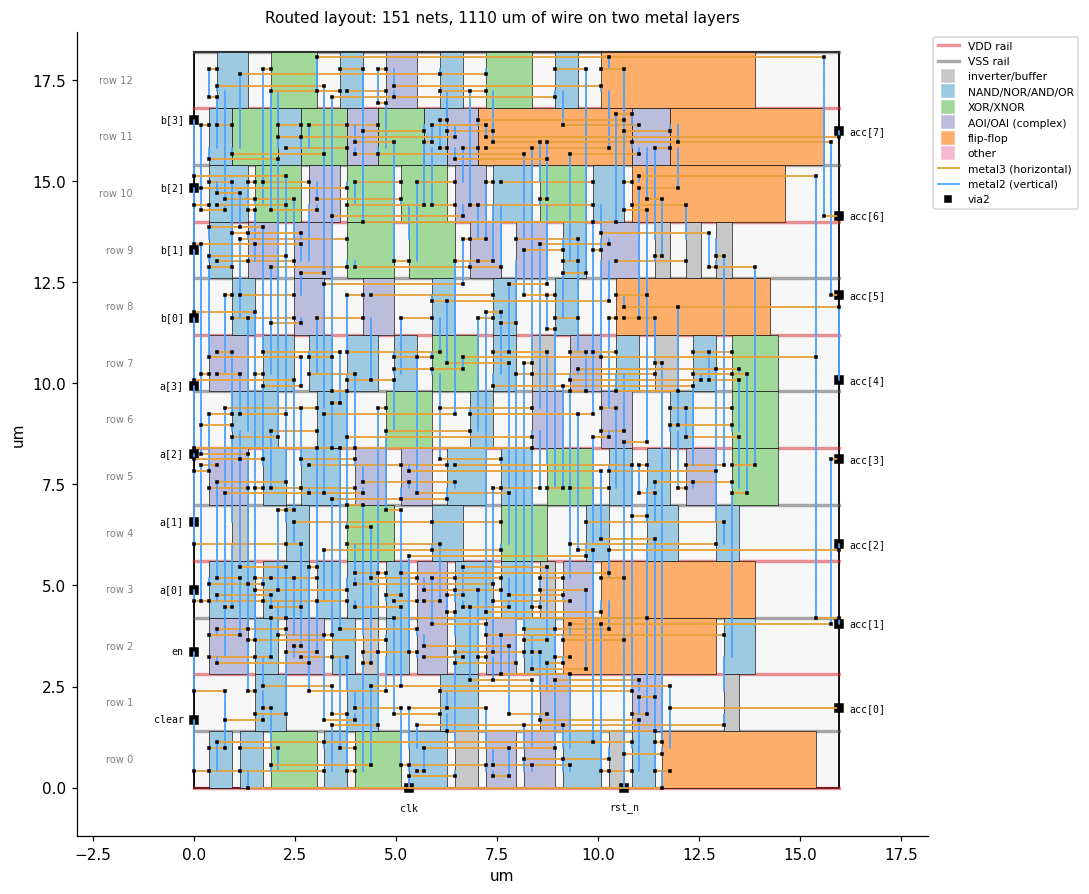

In [14]:
class Router:
    '''Two-layer maze router on the real track grid: layer 0 = metal3 (horizontal), 1 = metal2 (vertical).'''
    def __init__(self, pl, via_cost=4.0, occupied_cost=1e4):
        self.pl, self.nl = pl, pl.nl
        self.nx = int(round(pl.fp.core_w / M2_PITCH)) + 1              # vertical tracks
        self.ny = int(round(pl.fp.core_h / M3_PITCH)) + 1              # horizontal tracks
        self.owner = -np.ones((2, self.ny, self.nx), dtype=np.int32)    # net index using each grid node
        self.via_at = np.zeros((self.ny, self.nx), dtype=bool)          # via2 cuts (for the via-spacing rule)
        self.no_via = np.zeros((self.ny, self.nx), dtype=bool)          # sites a DRC fix has forbidden for vias
        self.history = np.zeros((2, self.ny, self.nx))                  # PathFinder-style cost on contested nodes
        self.via_cost, self.occupied_cost = via_cost, occupied_cost
        self.segs, self.vias, self.nodes, self.conflicts, self.sink_path = {}, {}, {}, {}, {}

    def grid(self, xy):
        '''(track row, track column): pins sit mid-site, so floor maps each site to its own column.'''
        return (int(round(xy[1] / M3_PITCH)), int(np.floor(xy[0] / M2_PITCH + 1e-6)))

    def pins(self, net):
        return list(dict.fromkeys(self.grid(p) for p in self.pl.net_points(net)))

    def route_net(self, net, idx, strict=False):
        pts = self.pins(net)                                          # driver pin first, then sinks
        segs, vias, conflicts, full = [], set(), set(), {}
        tree = {(1, *pts[0])}                                         # pins are reached on metal2 (via1 from the cell)
        ys, xs = [p[0] for p in pts], [p[1] for p in pts]
        for target in pts[1:]:
            path = None                                               # search a box around the net first, then widen
            for margin, strict_ in ((8, strict), (30, strict), (None, strict), (None, False)):
                box = None if margin is None else (max(min(ys) - margin, 0), min(max(ys) + margin, self.ny - 1),
                                                   max(min(xs) - margin, 0), min(max(xs) + margin, self.nx - 1))
                try:
                    path = self._dijkstra(tree, target, idx, strict_, box); break
                except RuntimeError:                                  # no path in this box / with these rules
                    continue
            for u, v in zip(path, path[1:]):
                if u[0] != v[0]:
                    vias.add((u[1], u[2]))
                else:
                    segs.append((u[0], (u[2], u[1]), (v[2], v[1])))
            for node in path:
                if self.owner[node] not in (-1, idx):
                    conflicts.add(int(self.owner[node]))
                self.owner[node] = idx; tree.add(node)
            # the complete driver-to-this-sink route = prefix of an earlier branch + this path
            prefix = next((fp[:fp.index(path[0])] for fp in full.values() if path[0] in fp), [])
            full[target] = prefix + path
        for y, x in vias:
            self.via_at[y, x] = True
        self.segs[net], self.vias[net], self.nodes[net], self.conflicts[net] = segs, vias, tree, conflicts
        self.sink_path[net] = full

    def _dijkstra(self, sources, target, idx, strict=False, box=None):
        '''Cheapest path from the net's tree to the target pin, searched inside `box` = (y0, y1, x0, x1).
        strict=True forbids occupied tracks and DRC-violating vias outright (raises if no clean path exists);
        otherwise they carry a large cost.'''
        ty, tx = target
        y0, y1, x0, x1 = box if box else (0, self.ny - 1, 0, self.nx - 1)
        dist, prev, pq = {s: 0.0 for s in sources}, {}, [(0.0, s) for s in sources]
        heapq.heapify(pq)
        while pq:
            d, u = heapq.heappop(pq)
            if d > dist[u]:
                continue
            if u == (1, ty, tx):
                path = [u]
                while u in prev:
                    u = prev[u]; path.append(u)
                return path[::-1]
            l, y, x = u
            steps = [((0, y, x + dx), 1.0) for dx in (-1, 1) if x0 <= x + dx <= x1] if l == 0 else \
                    [((1, y + dy, x), 1.0) for dy in (-1, 1) if y0 <= y + dy <= y1]
            # a via here would sit 0.07 um from a via on the neighbouring metal3 track; the tech LEF
            # says via2 SPACING 0.09 -- so treat that as (almost) forbidden, like an occupied track
            via_clash = self.via_at[max(y - 1, 0), x] or self.via_at[min(y + 1, self.ny - 1), x] or self.no_via[y, x]
            if not (strict and via_clash):
                steps.append(((1 - l, y, x), self.via_cost + (self.occupied_cost if via_clash else 0.0)))
            for v, w in steps:
                o = self.owner[v]
                if o != -1 and o != idx:
                    if strict:
                        continue
                    w += self.occupied_cost                           # a used track: (almost) forbidden
                w += self.history[v]                                  # nodes fought over before cost extra
                if d + w < dist.get(v, np.inf):
                    dist[v], prev[v] = d + w, u
                    heapq.heappush(pq, (d + w, v))
        raise RuntimeError(f"unroutable net {target}")

    def rebuild_occupancy(self, exclude=()):
        '''Recompute owner/via maps from the routed nets (minus `exclude`) plus every net's pin reservations.'''
        self.owner[:] = -1; self.via_at[:] = False
        for n, i in self.index.items():
            for y, x in self.pins(n):
                self.owner[1, y, x] = i
        for n, tree in self.nodes.items():
            if n in exclude:
                continue
            for node in tree:
                self.owner[node] = self.index[n]
            for y, x in self.vias[n]:
                self.via_at[y, x] = True

    def collisions(self):
        '''Nets that share a grid node with another net (what LVS will call a short).'''
        seen, bad = {}, set()
        for n, tree in self.nodes.items():
            for node in tree:
                if seen.setdefault(node, n) != n:
                    bad.update((n, seen[node])); self.history[node] += 6.0
        return bad

    def via_violators(self):
        '''Nets owning via2 cuts on adjacent metal3 tracks. A via *at a pin* is a legal via stack and stays;
        the offending site is forbidden and the net that owns it is ripped up (both, if neither is a pin).'''
        via_net = {v: n for n, vs in self.vias.items() for v in vs}
        pin_sites = {p for n in self.index for p in self.pins(n)}
        bad = set()
        for (y, x), n in via_net.items():
            m = via_net.get((y + 1, x))
            if m is None:
                continue
            for site in ((y, x), (y + 1, x)):
                if site not in pin_sites:
                    self.no_via[site] = True
            bad.update((n, m))                                    # rip up both: the neighbourhood must change
            self.history[:, max(y - 3, 0):min(y + 5, self.ny), x] += 6.0   # make this column stretch unattractive
        return bad

    def route_all(self, first=(), max_rounds=80):
        '''Clock nets first, then short nets; then rip-up-and-reroute whatever collided or violated DRC.'''
        nets = list(first) + sorted((n for n in self.nl.nets if n not in first), key=lambda n: self.pl.hpwl([n]))
        self.index = {n: i for i, n in enumerate(nets)}
        self.rebuild_occupancy()                                     # reserve every pin before routing anything
        for n in nets:
            self.route_net(n, self.index[n])
        for rnd in range(max_rounds):
            bad = sorted(self.collisions() | self.via_violators(), key=self.index.get)
            if not bad:
                break
            self.rebuild_occupancy(exclude=bad)
            for n in bad:                                            # rip up and reroute, cleanly if at all possible
                self.route_net(n, self.index[n], strict=True)
        else:
            print(f"rip-up-and-reroute did not converge in {max_rounds} rounds; still bad: {bad}")
        self.shorts = len(self.collisions())
        return self

    def drc_via_spacing(self):
        '''Pairs of via2 cuts on vertically adjacent tracks (0.14 um pitch, 0.07 um wide -> 0.07 um gap < 0.09 rule).'''
        return int((self.via_at[:-1, :] & self.via_at[1:, :]).sum())

    def wirelength(self, net):
        L = {0: 0.0, 1: 0.0}
        for l, a, b in self.segs.get(net, []):
            L[l] += M2_PITCH if l == 0 else M3_PITCH
        return L

    def draw(self, ax, nets=None, title="", alpha=1.0, lw=1.2, cells=True):
        if cells:
            self.pl.draw(ax, flylines=False, title=title)
        for net in (nets or self.segs):
            for l, (x0, y0), (x1, y1) in self.segs[net]:
                ax.plot([x0 * M2_PITCH, x1 * M2_PITCH], [y0 * M3_PITCH, y1 * M3_PITCH], c=LAYER_COLOR[l], lw=lw, alpha=alpha, zorder=6, solid_capstyle="round")
            for y, x in self.vias[net]:
                ax.plot(x * M2_PITCH, y * M3_PITCH, "s", c="k", ms=1.8, alpha=alpha, zorder=7)
        ax.plot([], [], c=LAYER_COLOR[0], lw=lw, label="metal3 (horizontal)"); ax.plot([], [], c=LAYER_COLOR[1], lw=lw, label="metal2 (vertical)")
        ax.plot([], [], "s", c="k", ms=4, label="via2")
        ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))

    def draw_path(self, ax, nl, sta, pl, color="#d62728"):
        '''Highlight an STA critical path on the layout: its cells, and the driver-to-sink route of each hop.'''
        hops = list(zip(sta["path"], sta["path"][1:] + [None]))
        length = 0.0
        for (net, *_), nxt in hops:
            if nxt is None:                                           # last hop: into the endpoint
                inst, pin = sta["worst"]
                target = self.grid(pl.fp.io[pin] if inst == "PO" else pl.pin_xy(inst, pin))
            else:
                inst = nxt[3]
                pin = next(p for p, n in nl.cells[inst]["conn"].items() if n == net)
                target = self.grid(pl.pin_xy(inst, pin))
            route = self.sink_path.get(net, {}).get(target, [])
            for u, v in zip(route, route[1:]):
                if u[0] == v[0]:
                    ax.plot([u[2] * M2_PITCH, v[2] * M2_PITCH], [u[1] * M3_PITCH, v[1] * M3_PITCH], c=color, lw=2.2, zorder=8, solid_capstyle="round")
                    length += M2_PITCH if u[0] == 0 else M3_PITCH
        for inst in {v for *_, v in sta["path"] if v in nl.cells} | {sta["worst"][0]} - {"PO"}:
            x, y = pl.xy[inst]
            ax.add_patch(Rectangle((x, y), pl.fp.width[inst], ROW_H, fc=color, ec="k", lw=0.6, zorder=7, alpha=0.85))
        return length


t0 = time.time()
RT = Router(PL).route_all(first=CLK_NETS)            # clock nets first: they get the straightest wires
dt = time.time() - t0
WL = {n: RT.wirelength(n) for n in NL.nets}
tot = {l: sum(w[l] for w in WL.values()) for l in (0, 1)}
print(f"routed {len(RT.segs)} nets in {dt:.1f} s on a {RT.nx} x {RT.ny} x 2 track grid; "
      f"nets still colliding after rip-up-and-reroute: {RT.shorts}; via-spacing violations: {RT.drc_via_spacing()}")
print(f"total wirelength: metal3 {tot[0]:.0f} um + metal2 {tot[1]:.0f} um = {tot[0] + tot[1]:.0f} um; "
      f"vias: {sum(len(v) for v in RT.vias.values())}")

fig, ax = plt.subplots(figsize=(11, 9.5))
RT.draw(ax, title=f"Routed layout: {len(RT.segs)} nets, {tot[0] + tot[1]:.0f} um of wire on two metal layers")
plt.show()

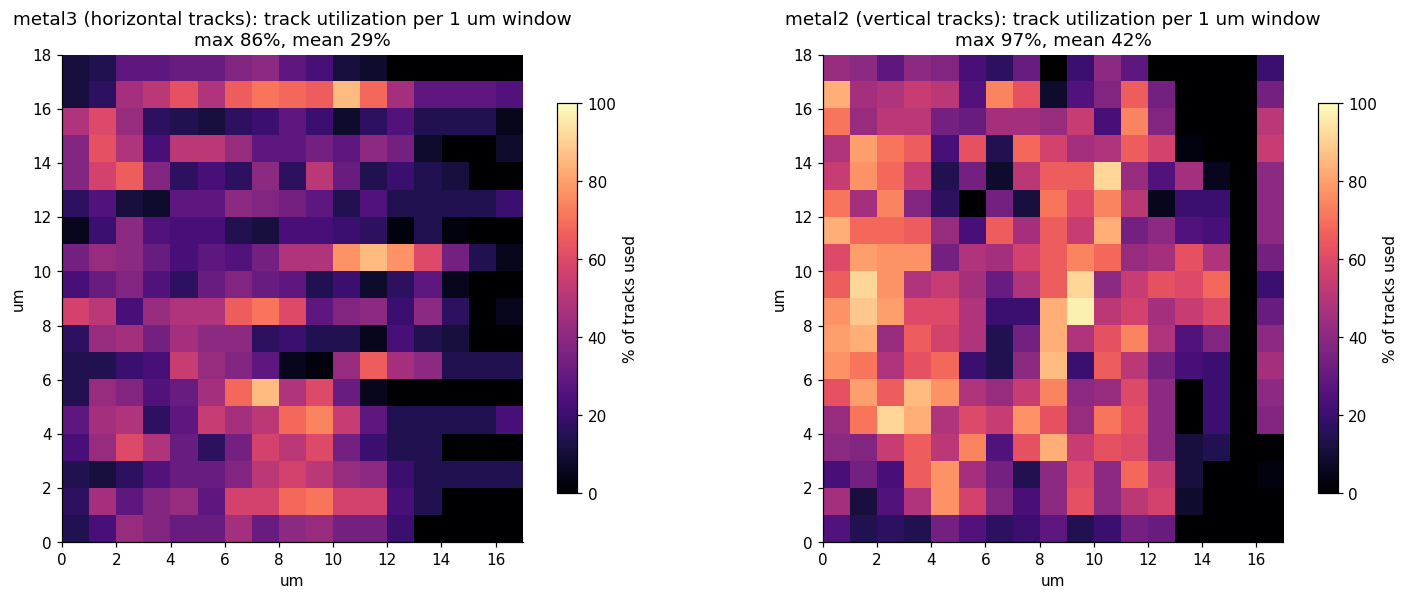

longest nets  wire um  pins  HPWL um
------------------------------------
n23           44.3     9     27.6   
acc[1]        29.5     5     21.8   
rst_n         28.8     9     22.5   
n69           28.8     6     19.5   
a[3]          27.2     6     16.6   
b[3]          24.5     8     14.0   
acc[6]        23.9     5     17.6   
a[2]          23.9     9     14.5   

Routed length exceeds HPWL because the router detours around occupied tracks and
a multi-pin net is a tree, not a box. Both effects grow with congestion.


In [15]:
# Congestion: how many of the tracks in each 1x1 um window are used? Real routers stare at this map.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
used = (RT.owner >= 0)
win_x, win_y = int(round(1.0 / M2_PITCH)), int(round(1.0 / M3_PITCH))
ny, nx = used.shape[1] // win_y, used.shape[2] // win_x
for l, ax, name in [(0, axes[0], "metal3 (horizontal tracks)"), (1, axes[1], "metal2 (vertical tracks)")]:
    m = used[l, :ny * win_y, :nx * win_x].reshape(ny, win_y, nx, win_x).mean(axis=(1, 3))
    im = ax.imshow(m * 100, origin="lower", cmap="magma", vmin=0, vmax=100,
                   extent=[0, nx, 0, ny])
    ax.set_title(f"{name}: track utilization per 1 um window\nmax {m.max()*100:.0f}%, mean {m.mean()*100:.0f}%")
    ax.set_xlabel("um"); ax.set_ylabel("um"); ax.grid(False)
    plt.colorbar(im, ax=ax, shrink=0.8, label="% of tracks used")
plt.tight_layout(); plt.show()

lengths = sorted(((WL[n][0] + WL[n][1], n) for n in NL.nets), reverse=True)[:8]
show_table(["longest nets", "wire um", "pins", "HPWL um"],
           [[n, L, len(PL.net_points(n)), PL.hpwl([n])] for L, n in lengths], "{:.1f}")
print("\nRouted length exceeds HPWL because the router detours around occupied tracks and")
print("a multi-pin net is a tree, not a box. Both effects grow with congestion.")

## 11. Parasitic extraction: wires become R and C

**Why this stage exists.** STA in §6 charged each net only its *pin* capacitances. Now every net is a
real piece of metal with resistance and capacitance, and those parasitics are what make post-layout
timing different from — always worse than — pre-layout. **Extraction** (Synopsys StarRC, Cadence Quantus;
OpenROAD's OpenRCX) walks the routed geometry and emits an **SPEF** file (Standard Parasitic Exchange
Format) with per-net R/C. We do it with per-unit-length constants: resistance from the Nangate45 tech LEF
(0.25 Ω/sq at 0.07 µm width ≈ 3.6 Ω/µm), capacitance at the industry rule of thumb 0.2 fF/µm (the
predictive kit's own numbers are lower; real values are field-solved from the metal stack).


In [16]:
R_PER_UM = 0.25 / 0.07        # ohm/um: RPERSQ 0.25 from the tech LEF, 0.07 um wide wire
C_PER_UM = 0.20               # fF/um: industry rule of thumb (0.15-0.25 across nodes and layers)

PARA = {}                     # net -> dict(R_ohm, C_wire_fF, C_pin_fF, C_total_fF, wire_delay_ns)
for n, d in NL.nets.items():
    L = WL[n][0] + WL[n][1]
    R, Cw = R_PER_UM * L, C_PER_UM * L
    Cp = sum(LIB[NL.cells[i]["type"]]["pins"][p]["cap"] for i, p in d["sinks"] if i != "PO")
    # Elmore delay of the distributed wire: 0.38 * R * C_wire + R * C_pins  (ns = ohm * fF * 1e-6)
    tw = (0.38 * R * Cw + R * Cp) * 1e-6
    PARA[n] = dict(L_um=L, R_ohm=R, C_wire_fF=Cw, C_pin_fF=Cp, C_total_fF=Cw + Cp, wire_delay_ns=tw)

# emit a SPEF (IEEE 1481, the format every timing tool reads): one pi-model per net, loads attached.
spef = ['*SPEF "IEEE 1481-1998"', '*DESIGN "mac4"', '*DATE "2026-09-13"', '*VENDOR "toy flow"',
        '*PROGRAM "rtl_to_gds_visualized"', '*VERSION "1.0"', '*DESIGN_FLOW "PIN_CAP INCLUDED"',
        "*DIVIDER /", "*DELIMITER :", "*BUS_DELIMITER [ ]",
        "*T_UNIT 1 NS", "*C_UNIT 1 FF", "*R_UNIT 1 OHM", "*L_UNIT 1 HENRY", ""]
for n, p in PARA.items():
    drv = NL.nets[n]["driver"]
    if not drv:
        continue
    def conn(inst, pin):                                    # *P = design port (its own direction), *I = instance pin
        if inst == "PI":
            return f"*P {pin} I", pin
        if inst == "PO":
            return f"*P {pin} O", pin
        return f"*I {inst}:{pin} {'O' if NL.lib[NL.cells[inst]['type']]['pins'][pin]['dir'] == 'output' else 'I'}", f"{inst}:{pin}"
    d_line, src = conn(*drv)
    sinks = [conn(i, pin) for i, pin in NL.nets[n]["sinks"]]
    spef += [f"*D_NET {n} {p['C_wire_fF']:.4f}", "*CONN", d_line] + [s[0] for s in sinks]
    spef += ["*CAP", f"1 {src} {p['C_wire_fF']/2:.4f}", f"2 {n}:1 {p['C_wire_fF']/2:.4f}", "*RES",
             f"1 {src} {n}:1 {p['R_ohm']:.3f}"]
    spef += [f"{k + 2} {n}:1 {name} 0.001" for k, (_, name) in enumerate(sinks)] + ["*END", ""]
with open(os.path.join(WORK, "mac4.spef"), "w") as f:
    f.write("\n".join(spef))
print("\n".join(spef[:32]))
print(f"... ({len(spef)} lines written to {WORK}/mac4.spef)\n")

worst = sorted(PARA.items(), key=lambda kv: -kv[1]["C_total_fF"])[:8]
show_table(["net", "wire um", "R ohm", "C_wire fF", "C_pins fF", "wire delay ps"],
           [[n, p["L_um"], p["R_ohm"], p["C_wire_fF"], p["C_pin_fF"], p["wire_delay_ns"] * 1e3] for n, p in worst], "{:.1f}")
tot_cw, tot_cp = sum(p["C_wire_fF"] for p in PARA.values()), sum(p["C_pin_fF"] for p in PARA.values())
wd = np.array([p["wire_delay_ns"] for p in PARA.values()]) * 1e3
print(f"\nTotal: wire capacitance {tot_cw:.0f} fF on top of {tot_cp:.0f} fF of pin capacitance -- wires are already")
print(f"{tot_cw / (tot_cw + tot_cp):.0%} of the load in an {FP.core_w:.0f} um block, and the share grows with block size.")
print(f"Wire *resistance* barely matters here: RC delay median {np.median(wd):.2f} ps, max {wd.max():.1f} ps, under one")
print("gate delay. At 5 nm, with 100x the resistance per um, it does not stay negligible.")

*SPEF "IEEE 1481-1998"
*DESIGN "mac4"
*DATE "2026-09-13"
*VENDOR "toy flow"
*PROGRAM "rtl_to_gds_visualized"
*VERSION "1.0"
*DESIGN_FLOW "PIN_CAP INCLUDED"
*DIVIDER /
*DELIMITER :
*BUS_DELIMITER [ ]
*T_UNIT 1 NS
*C_UNIT 1 FF
*R_UNIT 1 OHM
*L_UNIT 1 HENRY

*D_NET clk 0.3120
*CONN
*P clk I
*I CTS_root:A I
*CAP
1 clk 0.1560
2 clk:1 0.1560
*RES
1 clk clk:1 5.571
2 clk:1 CTS_root:A 0.001
*END

*D_NET rst_n 5.7580
*CONN
*P rst_n I
*I U120:RN I
*I U121:RN I
... (2179 lines written to /Users/daniil/Claude/rtl_amd/flow_artifacts/mac4.spef)

net    wire um  R ohm  C_wire fF  C_pins fF  wire delay ps
----------------------------------------------------------
n23    44.3     158.3  8.9        13.4       2.6          
rst_n  28.8     102.8  5.8        14.2       1.7          
b[2]   21.6     77.1   4.3        14.2       1.2          
a[2]   23.9     85.2   4.8        12.5       1.2          
b[3]   24.5     87.5   4.9        10.0       1.0          
n69    28.8     102.8  5.8        8.1        1.1 

## 12. Post-route STA: the truth, with wires

**Why this stage exists.** This is the number that matters: signoff timing on the routed design, with
extracted parasitics and the propagated clock tree. Every earlier timing estimate existed only to predict
*this*. In production it runs in a *different* tool than the one that did the implementation (PrimeTime vs
Innovus/Fusion Compiler — checker ≠ doer) across dozens of process/voltage/temperature corners; we run one
corner (Nangate45 typical, 1.1 V, 25 °C).

Two things changed since §6: every net's load grew by its wire capacitance, and the clock now arrives at
each flop through the tree in §9 (**propagated clock**) instead of at time zero (ideal clock). One
modeling choice to state explicitly: the block's inputs come from — and its outputs go to — flops in
neighbouring blocks on the *same* clock tree, so the IO constraints are shifted by the mean insertion
delay. (In PrimeTime you express this by giving the clock that the IO delays reference the same *network*
latency — `set_clock_latency 0.09 [get_clocks clk]` kept alongside propagated clocks, or a virtual clock
carrying that latency. Without it, the capture flops' ~90 ps of tree delay would silently *gift* the
input-to-flop paths 90 ps and mask the wire cost.)


clock insertion delay: 91.5 .. 93.0 ps  ->  skew = 1.4 ps

=== post-route STA (extracted wires + propagated clock) ===
Startpoint: b[3]   Endpoint: U127/D
Clock: clk, period 1000 ps

point                              incr (ps)  path (ps) slew (ps)
clock network latency (I/O ref)         92.2       92.2          
input external delay                   100.0      192.2          
b[3] (input port) -> b[3]                1.0      193.3      20.0
U18 (AND4_X1) -> n40                    85.3      278.5      30.3
U20 (OR3_X1) -> n42                     92.3      370.8      15.1
U23 (AOI21_X1) -> n45                   60.6      431.4      47.5
U25 (OR3_X1) -> n47                     98.0      529.4      15.4
U27 (AND3_X1) -> n49                    58.1      587.5      19.7
U30 (OR3_X1) -> n52                     96.4      683.9      21.6
U86 (AND2_X1) -> n108                   45.7      729.6      16.9
U90 (XOR2_X1) -> n112                   76.5      806.0      47.1
U92 (AOI21_X1) -> n114   

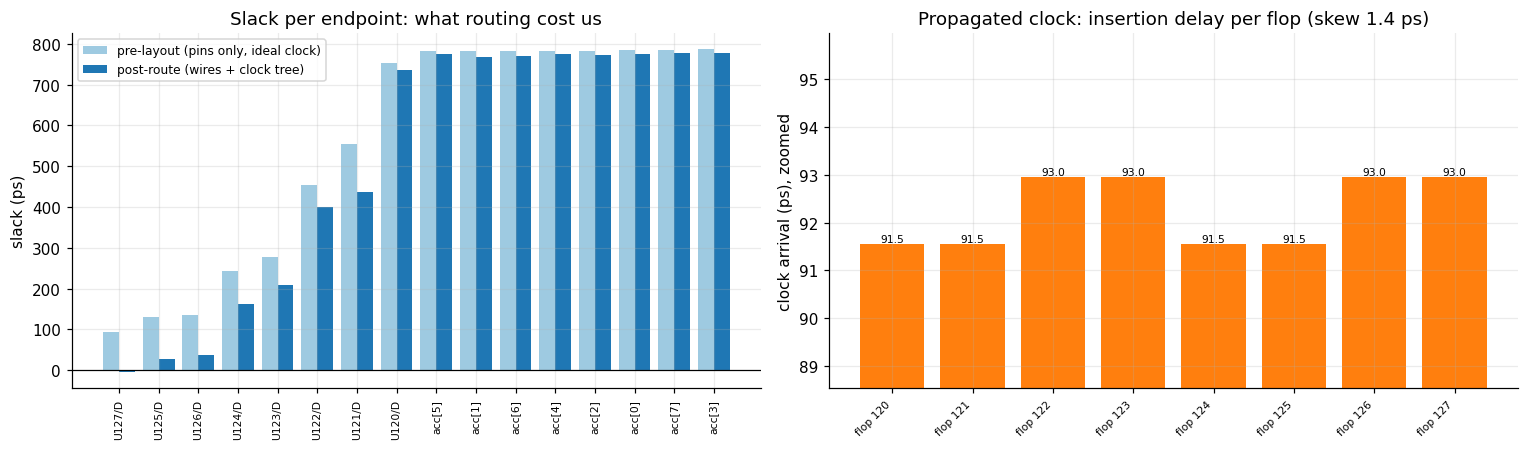

WNS: pre-layout +94 ps  ->  post-route -5 ps.
The pre-layout number was optimistic by exactly the physics that placement and routing decide.
Predicting the post-route number *from the RTL* -- before any of sections 7-11 ran -- is the
job of RTL-stage PPA estimation.


In [17]:
def clock_arrivals(nl, para, ck_slew=IN_SLEW):
    '''Insertion delay to each flop's CK pin through the clock buffers, with wire RC.'''
    arr, slew = {"clk": 0.0}, {"clk": ck_slew}
    for inst in ["CTS_root", "CTS_leaf0", "CTS_leaf1"]:
        c = nl.cells[inst]; inet, onet = c["conn"]["A"], c["conn"]["Z"]
        arc = next(a for a in nl.lib["CLKBUF_X1"]["arcs"] if a["pin"] == "Z")
        L = para[onet]["C_total_fF"]
        d = max(nldm(arc["tables"]["cell_rise"], slew[inet], L), nldm(arc["tables"]["cell_fall"], slew[inet], L))
        s = max(nldm(arc["tables"]["rise_transition"], slew[inet], L), nldm(arc["tables"]["fall_transition"], slew[inet], L))
        arr[onet] = arr[inet] + para[inet]["wire_delay_ns"] + d; slew[onet] = s
    return {f: arr[nl.cells[f]["conn"]["CK"]] + para[nl.cells[f]["conn"]["CK"]]["wire_delay_ns"]
            for f in nl.cells if nl.is_seq(f)}


CLK_ARR = clock_arrivals(NL, PARA)
lat = np.array(list(CLK_ARR.values())) * 1e3
print(f"clock insertion delay: {lat.min():.1f} .. {lat.max():.1f} ps  ->  skew = {np.ptp(lat):.1f} ps")

WIRE_C = {n: p["C_wire_fF"] for n, p in PARA.items()}
WIRE_D = {n: p["wire_delay_ns"] for n, p in PARA.items()}
STA_POST = run_sta(NL, T_CLK, wire_cap_fF=WIRE_C, wire_delay_ns=WIRE_D, clock_arrival=CLK_ARR)
print()
print(timing_report(NL, STA_POST, "post-route STA (extracted wires + propagated clock)"))
with open(os.path.join(WORK, "timing_postroute.rpt"), "w") as f:
    f.write(timing_report(NL, STA_POST, "post-route"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ends = sorted(STA_PRE["slack"], key=STA_PRE["slack"].get)
pre = np.array([STA_PRE["slack"][e] for e in ends]) * 1e3
post = np.array([STA_POST["slack"][e] for e in ends]) * 1e3
x = np.arange(len(ends))
axes[0].bar(x - 0.2, pre, 0.4, label="pre-layout (pins only, ideal clock)", color="#9ecae1")
axes[0].bar(x + 0.2, post, 0.4, label="post-route (wires + clock tree)", color="#1f77b4")
axes[0].axhline(0, c="k", lw=0.8); axes[0].set_xticks(x)
axes[0].set_xticklabels([e[1] if e[0] == "PO" else f"{e[0]}/D" for e in ends], rotation=90, fontsize=7)
axes[0].set_ylabel("slack (ps)"); axes[0].legend(fontsize=8); axes[0].set_title("Slack per endpoint: what routing cost us")
bars = axes[1].bar([f.replace("U", "flop ") for f in CLK_ARR], lat, color="#ff7f0e")
axes[1].set_ylim(lat.min() - 3, lat.max() + 3); axes[1].bar_label(bars, fmt="%.1f", fontsize=7)
axes[1].set_ylabel("clock arrival (ps), zoomed"); axes[1].set_title(f"Propagated clock: insertion delay per flop (skew {np.ptp(lat):.1f} ps)")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=7)
plt.tight_layout(); plt.show()
print(f"WNS: pre-layout {STA_PRE['wns']*1e3:+.0f} ps  ->  post-route {STA_POST['wns']*1e3:+.0f} ps.")
print("The pre-layout number was optimistic by exactly the physics that placement and routing decide.")
print("Predicting the post-route number *from the RTL* -- before any of sections 7-11 ran -- is the")
print("job of RTL-stage PPA estimation.")

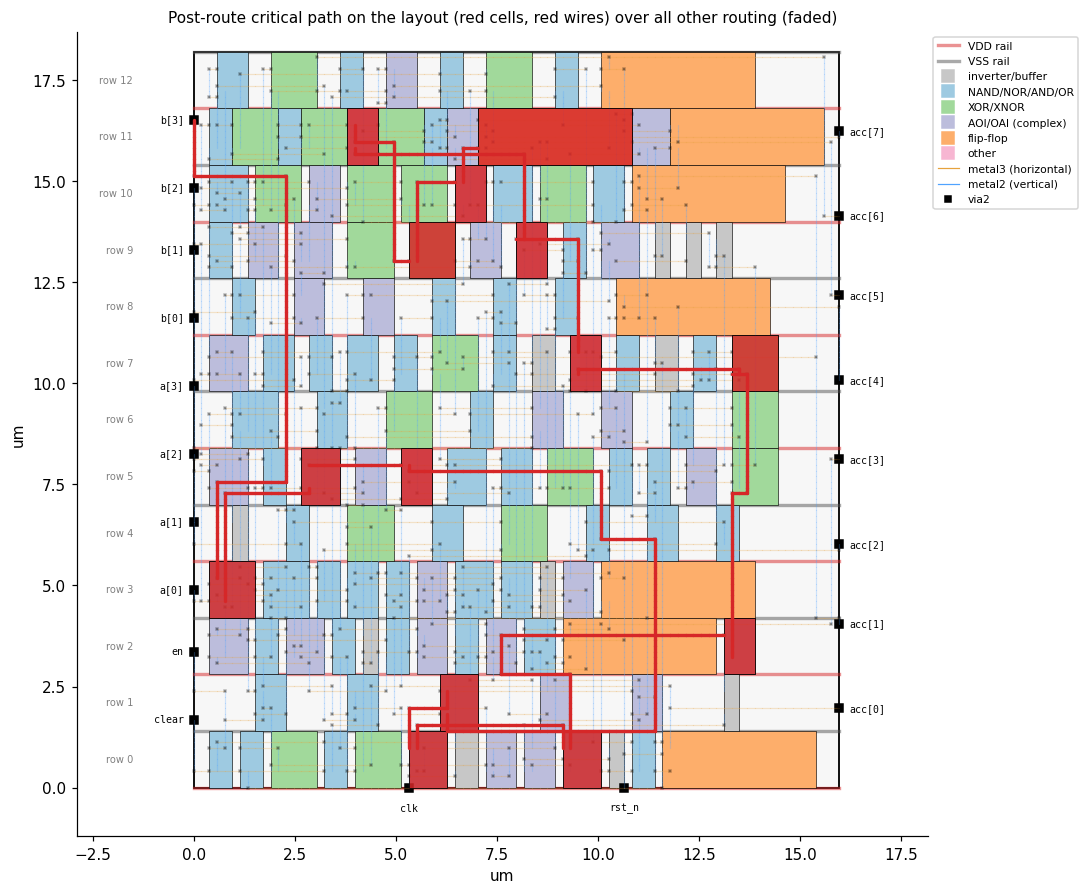

The critical path threads 13 cells and 89.4 um of wire across the block.
A placer that knew this path was critical would have pulled those cells together --
that is 'timing-driven placement', and it is the difference between a toy and Innovus.


In [18]:
# The critical path, drawn on the layout: its cells in red, and for each hop the actual wire
# from the driving pin to the next cell's input pin (not the whole net's fanout tree).
fig, ax = plt.subplots(figsize=(11, 9.5))
RT.draw(ax, title="Post-route critical path on the layout (red cells, red wires) over all other routing (faded)",
        alpha=0.25, lw=0.8)
crit_len = RT.draw_path(ax, NL, STA_POST, PL)
plt.show()
n_crit = len({v for *_, v in STA_POST["path"] if v in NL.cells})
print(f"The critical path threads {n_crit} cells and {crit_len:.1f} um of wire across the block.")
print("A placer that knew this path was critical would have pulled those cells together --")
print("that is 'timing-driven placement', and it is the difference between a toy and Innovus.")

## 13. Power: switching, clock, leakage

**Why this stage exists.** Power is the third PPA axis, and the one that decides whether the chip needs a
heatsink. Post-route, it can finally be computed properly: dynamic power needs the *real* capacitance of
every net (pins + extracted wire) and its *real* activity (how often it toggles — from the gate-level
simulation in §5.1), leakage needs the cells' Liberty leakage values. Commercial: Synopsys PrimePower,
Cadence Voltus/Joules, with activity from emulation or simulation (`.saif`/`.fsdb` files).

$$P = \underbrace{\sum_{\text{nets}} \tfrac{1}{2}\,\text{toggles/cycle} \cdot C_{net} V^2 f}_{\text{switching}}
\;+\; \underbrace{\sum_{\text{cells}} P_{leak}}_{\text{leakage}} \;(+\;\text{internal / short-circuit, omitted})$$


component   uW     share
------------------------
clock nets  25.4   12%  
data nets   178.4  86%  
leakage     3.7    2%   
total       207.5       


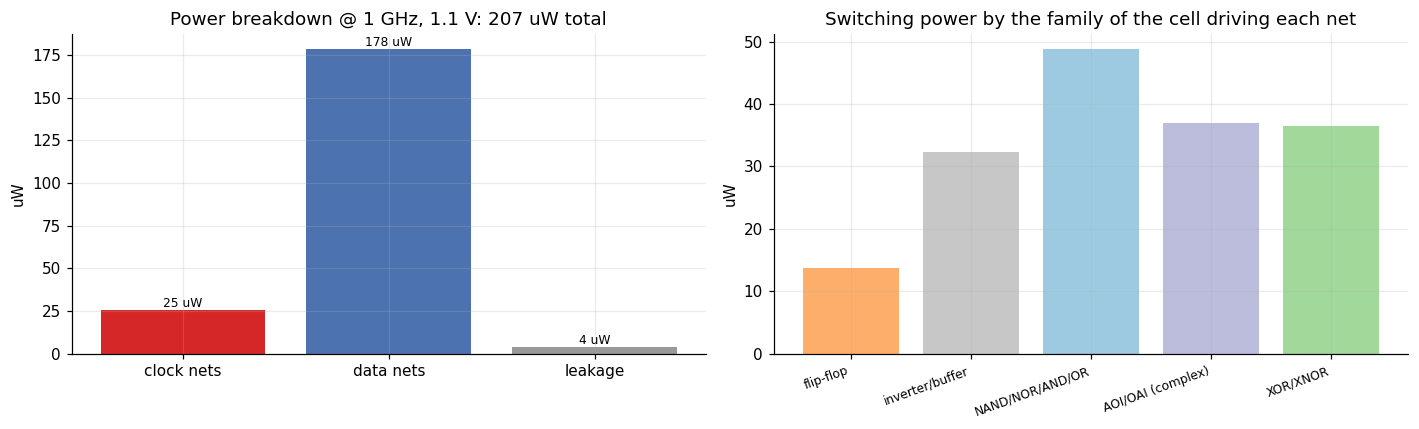

4 clock nets out of 151 = 12% of power while carrying no information (alpha = 1).
Omitted here: each cell's *internal* power (short-circuit + internal nodes) -- in a real report the
flops' internal clock-pin switching makes the clock the single largest consumer, 25-40% of dynamic.
Hence clock gating first; and the activity file (the *workload*) matters as much as the netlist.


In [19]:
VDD, F_CLK = 1.1, 1.0 / (T_CLK * 1e-9)               # V, Hz
n_cycles = len(stim)
p_switch, p_by_class = {}, Counter()
for n, p in PARA.items():
    if n.startswith("const"):
        continue
    toggles_per_cycle = 2.0 if n in CLK_NETS else SIM.toggles[n] / n_cycles   # the clock toggles twice per cycle
    P = 0.5 * toggles_per_cycle * p["C_total_fF"] * 1e-15 * VDD ** 2 * F_CLK   # watts
    p_switch[n] = P
    p_by_class["clock nets" if n in CLK_NETS else "data nets"] += P
p_leak = sum(LIB[c["type"]]["leakage_nW"] for c in NL.cells.values()) * 1e-9
p_by_class["leakage"] = p_leak
total = sum(p_by_class.values())
show_table(["component", "uW", "share"], [[k, v * 1e6, f"{v/total:.0%}"] for k, v in p_by_class.items()] + [["total", total * 1e6, ""]], "{:.1f}")

by_type = Counter()
for n, P in p_switch.items():
    drv = NL.nets[n]["driver"]
    if drv and drv[0] != "PI":
        by_type[family(NL.cells[drv[0]]["type"])] += P
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars = axes[0].bar(list(p_by_class), [v * 1e6 for v in p_by_class.values()], color=["#d62728", "#4c72b0", "#999999"])
axes[0].bar_label(bars, fmt="%.0f uW", fontsize=8)
axes[0].set_ylabel("uW"); axes[0].set_title(f"Power breakdown @ {F_CLK/1e9:.0f} GHz, {VDD} V: {total*1e6:.0f} uW total")
axes[1].bar(list(by_type), [v * 1e6 for v in by_type.values()], color=[FAM_COLOR[k] for k in by_type])
axes[1].set_ylabel("uW"); axes[1].set_title("Switching power by the family of the cell driving each net")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.tight_layout(); plt.show()
print(f"4 clock nets out of {len(PARA)} = {p_by_class['clock nets']/total:.0%} of power while carrying no information (alpha = 1).")
print("Omitted here: each cell's *internal* power (short-circuit + internal nodes) -- in a real report the")
print("flops' internal clock-pin switching makes the clock the single largest consumer, 25-40% of dynamic.")
print("Hence clock gating first; and the activity file (the *workload*) matters as much as the netlist.")

## 14. Signoff and tapeout

**Why this stage exists.** Before spending a mask set, independent checks prove the polygons are (a) what
the netlist says — **LVS**, layout vs schematic — and (b) manufacturable — **DRC**, design rule check,
against the foundry's rule deck (Siemens Calibre is the signoff standard; >10,000 rules at 3 nm). Both
work purely on *geometry*: they do not trust the router's bookkeeping, they re-extract connectivity from
the shapes. Our LVS does exactly that: union-find over touching wire segments and vias, then check that
every net's pins form one connected component (no **opens**) and no component contains pins of two nets
(no **shorts**).

Our DRC is honest about its scope: the track grid guarantees metal line width and spacing, and the router
enforces the one rule the grid does not — the tech LEF's **via2 spacing of 0.09 µm** (two vias on
adjacent 0.14 µm metal3 tracks would be 0.07 µm apart) — so we check that one. A real deck adds via
enclosure, minimum area, metal density windows (met by inserting **dummy fill**), antenna rules, and
thousands more.

Then **tapeout**: serialize the geometry as **GDSII** — a 1978 binary format of layer-tagged polygons
(here in a ~40-line writer, using the real Nangate45 layer numbers: metal2 = 13, via2 = 14, metal3 = 15).
KLayout can open the resulting file. This is, quite literally, the artifact a foundry receives — and it is
only written if signoff is clean.


LVS: 0 opens, 0 shorts  ->  CLEAN
DRC: metal width/spacing clean by construction (track grid); via2 spacing (0.09 um): 0 violations  ->  CLEAN
      (not checked: via enclosure, min area, density/fill, antenna -- a real deck has thousands of rules)
STA: WNS -5 ps at 1000 ps  ->  VIOLATED (section 15 fixes it; physical signoff is independent)

wrote /Users/daniil/Claude/rtl_amd/flow_artifacts/mac4.gds: 102,638 bytes of polygons. That file *is* the tapeout (once section 15 has closed timing).


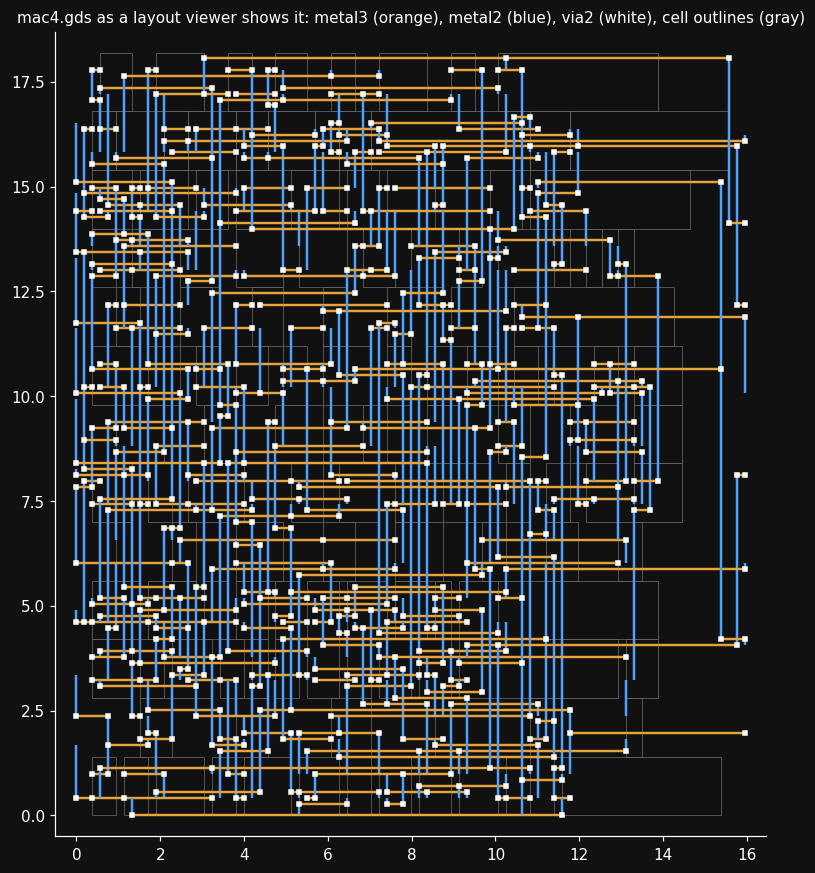

In [20]:
def lvs(rt):
    '''Re-extract connectivity from geometry alone and compare to the netlist.'''
    parent = {}
    def find(a):
        while parent.setdefault(a, a) != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b):
        parent[find(a)] = find(b)
    for net in rt.segs:                                    # geometry: segments connect their two endpoints
        for l, (x0, y0), (x1, y1) in rt.segs[net]:
            union((l, y0, x0), (l, y1, x1))
        for y, x in rt.vias[net]:                          # vias connect the two layers
            union((0, y, x), (1, y, x))
    opens = shorts = 0
    comp_owner = {}
    for net in rt.segs:
        pins = {rt.grid(p) for p in rt.pl.net_points(net)}
        comps = {find((1, y, x)) for y, x in pins}
        if len(comps) > 1:
            opens += 1
        for c in comps:
            if comp_owner.setdefault(c, net) != net:
                shorts += 1
    return opens, shorts

opens, shorts = lvs(RT)
via_viol = RT.drc_via_spacing()
print(f"LVS: {opens} opens, {shorts} shorts  ->  {'CLEAN' if opens == shorts == 0 else 'FAIL'}")
print(f"DRC: metal width/spacing clean by construction (track grid); via2 spacing (0.09 um): {via_viol} violations"
      f"  ->  {'CLEAN' if via_viol == 0 else 'FAIL'}")
SIGNOFF_CLEAN = opens == shorts == via_viol == 0
print("      (not checked: via enclosure, min area, density/fill, antenna -- a real deck has thousands of rules)")
print(f"STA: WNS {STA_POST['wns']*1e3:+.0f} ps at {T_CLK*1e3:.0f} ps  ->  "
      f"{'CLEAN' if STA_POST['wns'] >= 0 else 'VIOLATED (section 15 fixes it; physical signoff is independent)'}")
if not SIGNOFF_CLEAN:
    print("\nPHYSICAL SIGNOFF FAILED: a real flow stops here (rip-up/reroute or ECO, then re-check). The GDS below")
    print("is written anyway so you can look at it, but it would not be accepted by a foundry.")

import struct

def write_gds(path, rt, cell_name="mac4"):
    '''Minimal GDSII writer: cell outlines on layer 235, metal2 = 13, via2 = 14, metal3 = 15 (Nangate45 map).'''
    def rec(tag, dtype, payload=b""):
        return struct.pack(">HBB", 4 + len(payload), tag, dtype) + payload
    def i16(*v):  return struct.pack(">" + "h" * len(v), *v)
    def i32(*v):  return struct.pack(">" + "i" * len(v), *v)
    def f64(x):                                            # GDS 8-byte excess-64 float
        if x == 0:
            return b"\x00" * 8
        sign, x = (0x80, -x) if x < 0 else (0, x)
        e = 0
        while x >= 1: x /= 16; e += 1
        while x < 1 / 16: x *= 16; e -= 1
        m = int(x * (1 << 56))
        return bytes([sign | (e + 64)]) + m.to_bytes(7, "big")
    def s(x): return x.encode() + (b"\x00" if len(x) % 2 else b"")
    U = 1000                                               # database unit = 1 nm
    def boundary(layer, pts):
        xy = [c for p in pts for c in (int(round(p[0] * U)), int(round(p[1] * U)))]
        xy += xy[:2]
        return rec(0x08, 0) + rec(0x0D, 2, i16(layer)) + rec(0x0E, 2, i16(0)) + rec(0x10, 3, i32(*xy)) + rec(0x11, 0)
    out = rec(0x00, 2, i16(600)) + rec(0x01, 2, i16(*[2026, 9, 13, 0, 0, 0] * 2)) + rec(0x02, 6, s("toyflow"))
    out += rec(0x03, 5, f64(1e-3) + f64(1e-9))            # user unit = 1 um, db unit = 1 nm
    out += rec(0x05, 2, i16(*[2026, 9, 13, 0, 0, 0] * 2)) + rec(0x06, 6, s(cell_name))
    W = 0.07                                               # wire width from the tech LEF
    pl = rt.pl
    cw, ch = pl.fp.core_w, pl.fp.core_h
    def rect(layer, x0, y0, x1, y1):                       # clipped to the core, as a foundry would expect
        x0, x1, y0, y1 = max(x0, 0), min(x1, cw), max(y0, 0), min(y1, ch)
        return boundary(layer, [(x0, y0), (x1, y0), (x1, y1), (x0, y1)])
    for inst, (x, y) in pl.xy.items():                     # cell outlines (real flows: cell references, SREF)
        out += rect(235, x, y, x + pl.fp.width[inst], y + ROW_H)
    for net in rt.segs:
        runs = defaultdict(list)                           # merge each net's collinear track steps into one wire
        for l, (x0, y0), (x1, y1) in rt.segs[net]:
            if l == 0:
                runs[(0, y0)].append((min(x0, x1), max(x0, x1)))
            else:
                runs[(1, x0)].append((min(y0, y1), max(y0, y1)))
        for (l, k), spans in runs.items():
            spans.sort(); merged = [list(spans[0])]
            for a, b in spans[1:]:
                if a <= merged[-1][1]:
                    merged[-1][1] = max(merged[-1][1], b)
                else:
                    merged.append([a, b])
            for a, b in merged:
                if l == 0:
                    out += rect(15, a * M2_PITCH - W/2, k * M3_PITCH - W/2, b * M2_PITCH + W/2, k * M3_PITCH + W/2)
                else:
                    out += rect(13, k * M2_PITCH - W/2, a * M3_PITCH - W/2, k * M2_PITCH + W/2, b * M3_PITCH + W/2)
        for y, x in rt.vias[net]:
            X, Y = x * M2_PITCH, y * M3_PITCH
            out += rect(14, X - W/2, Y - W/2, X + W/2, Y + W/2)
    out += rec(0x07, 0) + rec(0x04, 0)                    # ENDSTR, ENDLIB
    with open(path, "wb") as f:
        f.write(out)
    return len(out)

nbytes = write_gds(os.path.join(WORK, "mac4.gds"), RT)
print(f"\nwrote {WORK}/mac4.gds: {nbytes:,} bytes of polygons. "
      + ("That file *is* the tapeout" + (" (once section 15 has closed timing)." if STA_POST["wns"] < 0 else ".")
         if SIGNOFF_CLEAN else "(NOT tapeout-clean, see above.)"))

# What a layout viewer would show when opening it: dark background, one color per layer.
fig, ax = plt.subplots(figsize=(11, 9.5), facecolor="#111111")
ax.set_facecolor("#111111")
for inst, (x, y) in PL.xy.items():
    ax.add_patch(Rectangle((x, y), FP.width[inst], ROW_H, fc="none", ec="#666666", lw=0.5))
for net in RT.segs:
    for l, (x0, y0), (x1, y1) in RT.segs[net]:
        ax.plot([x0 * M2_PITCH, x1 * M2_PITCH], [y0 * M3_PITCH, y1 * M3_PITCH], c=LAYER_COLOR[l], lw=1.6, solid_capstyle="butt")
    for y, x in RT.vias[net]:
        ax.plot(x * M2_PITCH, y * M3_PITCH, "s", c="white", ms=2)
ax.set_aspect("equal"); ax.grid(False); ax.set_xlim(-0.5, FP.core_w + 0.5); ax.set_ylim(-0.5, FP.core_h + 0.5)
ax.tick_params(colors="white"); [sp.set_color("white") for sp in ax.spines.values()]
ax.set_title("mac4.gds as a layout viewer shows it: metal3 (orange), metal2 (blue), via2 (white), cell outlines (gray)", color="white", fontsize=10)
plt.show()

## 15. Timing closure: the loop, and the loop behind the loop

**Why this stage exists.** Nothing closes on the first pass. When post-route WNS is negative, engineers
iterate — first with **ECOs** (engineering change orders: small netlist edits like upsizing cells on the
critical path, applied incrementally without re-running everything), and when those run out, by changing
the RTL and re-running the entire flow. Let's do both.

The classic ECO: swap cells on the critical path from drive strength X1 to X2 (bigger transistors, more
current, faster edges — for more area and leakage). Nangate45 ships X2 versions of every cell we used, so
the swap is just a type change and a re-run of STA with the X2 Liberty tables. We try it twice: first at
the 1 GHz target (if post-route timing missed it — a few tens of picoseconds is exactly what ECOs are for),
then at a deliberately tighter 800 ps target, to find out where sizing stops helping.


In [21]:
import copy

def eco_upsize(nl, T, max_rounds=5):
    '''Repeatedly upsize X1 -> X2 along the current critical path until timing closes or nothing changes.'''
    nl = copy.deepcopy(nl)
    sta = run_sta(nl, T, wire_cap_fF=WIRE_C, wire_delay_ns=WIRE_D, clock_arrival=CLK_ARR)
    print(f"@ {T*1e3:.0f} ps clock: WNS = {sta['wns']*1e3:+.0f} ps, TNS = {sta['tns']*1e3:+.0f} ps  ->  "
          f"{'MET' if sta['wns'] >= 0 else 'VIOLATED'}")
    total = 0
    for rnd in range(max_rounds):
        if sta["wns"] >= 0:
            break
        changed = 0
        for *_, inst in sta["path"]:
            if inst in nl.cells and not nl.is_seq(inst):
                t = nl.cells[inst]["type"]
                if t.endswith("_X1") and t[:-3] + "_X2" in LIB:
                    nl.cells[inst]["type"] = t[:-3] + "_X2"; changed += 1
        if not changed:
            print("   no X1 cell left to upsize on the critical path")
            break
        total += changed
        sta = run_sta(nl, T, wire_cap_fF=WIRE_C, wire_delay_ns=WIRE_D, clock_arrival=CLK_ARR)
        print(f"   ECO round {rnd + 1}: +{changed} cells X1 -> X2 on the critical path, WNS = {sta['wns']*1e3:+.0f} ps")
    area_eco = sum(LIB[c["type"]]["area"] for c in nl.cells.values())
    area_base = sum(LIB[c["type"]]["area"] for c in NL.cells.values())
    print(f"   -> {'CLOSED' if sta['wns'] >= 0 else 'STILL VIOLATING'} after {total} upsizes; "
          f"area {area_base:.1f} -> {area_eco:.1f} um^2 (+{(area_eco/area_base - 1)*100:.1f}%)\n")
    return nl, sta

if STA_POST["wns"] < 0:
    print("Post-route timing missed the 1 GHz target that synthesis 'met' -- the everyday ECO situation:")
NL_ECO, sta_eco_1g = eco_upsize(NL, T_CLK)

T_TIGHT = 0.80                                          # ns: a 1.25 GHz target, to find sizing's limit
print("Now push the same netlist to 800 ps:")
NL_ECO2, sta_eco = eco_upsize(NL, T_TIGHT)
print("(A real ECO would also re-legalize placement and re-route the touched nets; X2 cells are wider.)")
print("Sizing buys ~10% -- enough for a small post-route miss, not for a 20% target change.")
print("The multiplier's logic depth is structural; the next fix has to happen in the RTL.")

Post-route timing missed the 1 GHz target that synthesis 'met' -- the everyday ECO situation:
@ 1000 ps clock: WNS = -5 ps, TNS = -5 ps  ->  VIOLATED
   ECO round 1: +13 cells X1 -> X2 on the critical path, WNS = +85 ps
   -> CLOSED after 13 upsizes; area 175.8 -> 183.3 um^2 (+4.2%)

Now push the same netlist to 800 ps:
@ 800 ps clock: WNS = -205 ps, TNS = -580 ps  ->  VIOLATED
   ECO round 1: +13 cells X1 -> X2 on the critical path, WNS = -115 ps
   ECO round 2: +4 cells X1 -> X2 on the critical path, WNS = -58 ps
   no X1 cell left to upsize on the critical path
   -> STILL VIOLATING after 17 upsizes; area 175.8 -> 186.2 um^2 (+5.9%)

(A real ECO would also re-legalize placement and re-route the touched nets; X2 cells are wider.)
Sizing buys ~10% -- enough for a small post-route miss, not for a 20% target change.
The multiplier's logic depth is structural; the next fix has to happen in the RTL.


### 15.1 The fix that actually works: change the RTL, rerun everything

The critical path is `a,b → multiplier → adder → flop`: two arithmetic operators in one cycle. The kimi-chip
project hit this exact wall (X1–X3 plateau) and broke it by **pipelining** — put a register between the
multiplier and the adder. One extra cycle of latency, 8 more flops, and the longest path is now
*either* the multiplier *or* the adder, not both.

Because every stage above is a function, the whole flow reruns on the new RTL in seconds — so we rerun
*both* designs at the 800 ps target the ECOs could not reach and compare. That is what the "run a hundred
experiments in OpenROAD to find the right direction" workflow in the kimi-chip README means in practice,
and the cost of each such run — hours to days on a real block — is what RTL-stage PPA prediction tries to
remove.


module mac4 (   // PIPELINED: product registered before the add
    reg  [7:0] prod;              // pipeline register: stage 1 = multiply
    always @(posedge clk or negedge rst_n)
        if (!rst_n) prod <= 8'd0; else prod <= a * b;
    always @(posedge clk or negedge rst_n) begin
        else if (en)      acc <= acc + prod;   // combinational adder + mux, then 8 flops



two complete RTL-to-GDS runs at a 800 ps clock in 12.7 s

design     cells  flops  cell area  core um^2  wire um  WNS pre  WNS post  fmax MHz  power uW  signoff
------------------------------------------------------------------------------------------------------
mac4_base  131    8      176        290        1236     -106     -225      975       217       clean  
mac4_pipe  137    16     216        358        1351     +117     +43       1321      215       clean  


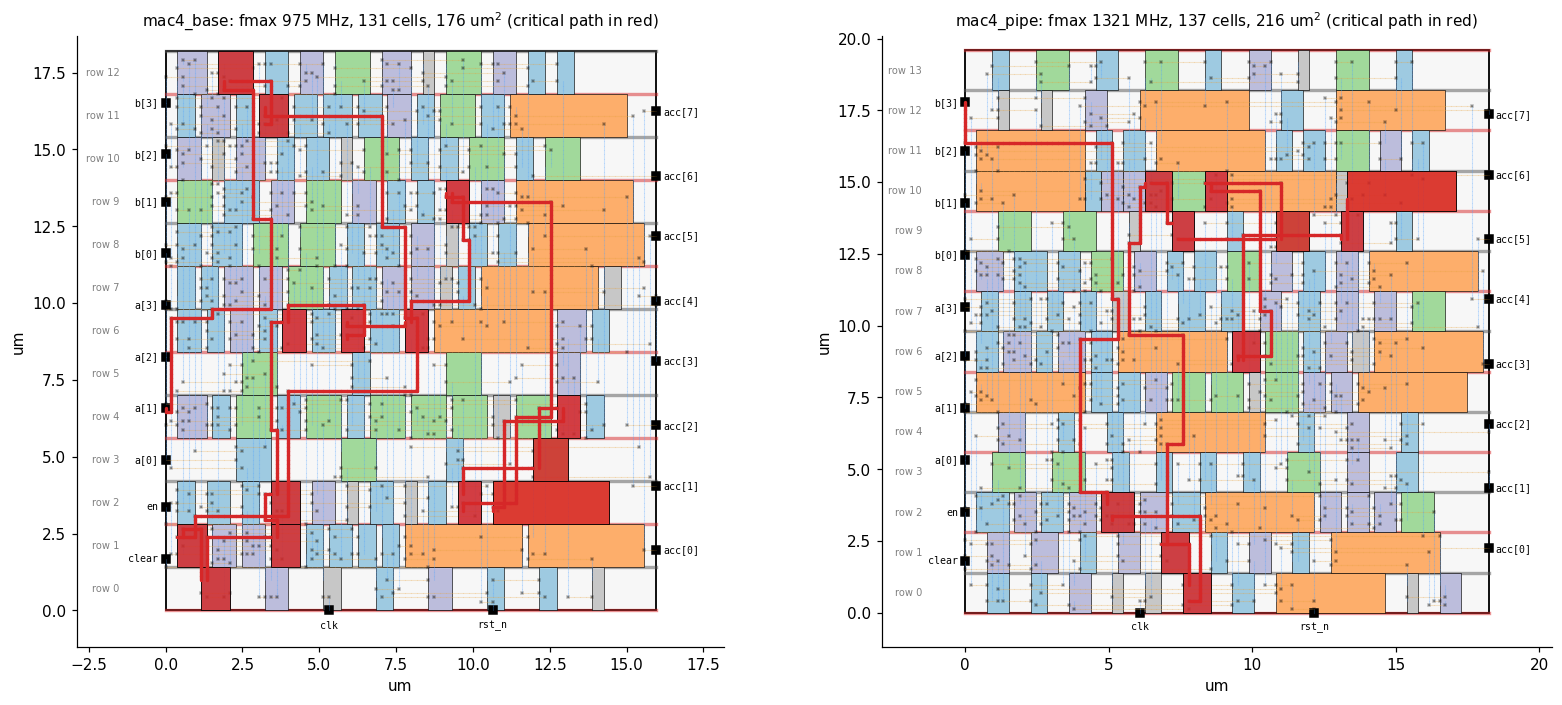

At 800 ps: base WNS -225 ps (VIOLATED), pipelined WNS +43 ps (MET).
Pipelining: fmax x1.35, area x1.23, power x0.99.
Exactly the kimi-chip X5 move (register the product), reproduced end to end with real synthesis.
The frequency came from shortening the longest path into the accumulator (here an input-to-register
path -- note that 100 ps of it is the input delay you wrote in the SDC), nothing else. The power
ratio is flattering: with cell-internal power omitted, 8 extra flops toggling their clock pins every
cycle are nearly free here; a real report would show roughly +10-15%. Pipelining buys frequency
with area and power -- there is no free lunch, only a good trade.


In [22]:
RTL_PIPE = RTL.replace("module mac4 (", "module mac4 (   // PIPELINED: product registered before the add") \
              .replace("    wire [7:0] prod = a * b;      // combinational: a 4x4 multiplier",
                       "    reg  [7:0] prod;              // pipeline register: stage 1 = multiply\n"
                       "    always @(posedge clk or negedge rst_n)\n"
                       "        if (!rst_n) prod <= 8'd0; else prod <= a * b;")
print("\n".join(l for l in RTL_PIPE.splitlines() if "prod" in l or "always" in l))


def random_stimulus(nl, n_cycles=200, seed=0):
    '''Random inputs for any port list: en high 75% of cycles, a rare synchronous clear, reset released.'''
    r = np.random.default_rng(seed)
    data_bits = [p for p, (d, n) in nl.ports.items() if d == "input" and p not in ("clk", "rst_n", "clear", "en")]
    cycles = []
    for _ in range(n_cycles):
        inp = {"rst_n": 1, "clear": int(r.random() < 1 / 16), "en": int(r.random() < 0.75)}
        inp.update({p: int(r.integers(0, 2)) for p in data_bits})
        cycles.append(inp)
    return cycles


def extract_parasitics(nl, rt):
    para = {}
    for n, d in nl.nets.items():
        L = sum(rt.wirelength(n).values()); R, Cw = R_PER_UM * L, C_PER_UM * L
        Cp = sum(LIB[nl.cells[i]["type"]]["pins"][p]["cap"] for i, p in d["sinks"] if i != "PO")
        para[n] = dict(L_um=L, R_ohm=R, C_wire_fF=Cw, C_pin_fF=Cp, C_total_fF=Cw + Cp, wire_delay_ns=(0.38 * R * Cw + R * Cp) * 1e-6)
    return para


def switching_power(nl, toggles, n_cycles, wire_cap, clk_nets):
    '''P = sum over nets of 1/2 * toggles/cycle * (C_pins + C_wire) * V^2 * f, plus leakage. Watts.'''
    p = 0.0
    for n, d in nl.nets.items():
        if n.startswith("const"):
            continue
        Cp = sum(LIB[nl.cells[i]["type"]]["pins"][pin]["cap"] for i, pin in d["sinks"] if i != "PO")
        tpc = 2.0 if n in clk_nets else toggles[n] / n_cycles
        p += 0.5 * tpc * (Cp + wire_cap.get(n, 0.0)) * 1e-15 * VDD ** 2 * F_CLK
    return p + sum(LIB[c["type"]]["leakage_nW"] for c in nl.cells.values()) * 1e-9


def run_flow(rtl_text, tag, T=T_CLK, seed=1, top="mac4", anneal_iters=15000, utilization=None):
    '''RTL text -> every stage above -> all the PPA numbers, plus the intermediate objects and per-stage times.'''
    t_stage, t0 = {}, time.time()
    with open(os.path.join(WORK, f"{tag}.v"), "w") as f:
        f.write(rtl_text)
    ok = run_yosys(f'''
read_verilog {tag}.v
hierarchy -top {top}
proc; opt; wreduce; opt_clean
write_json {tag}_generic.json
synth -top {top}
dfflibmap -liberty NangateOpenCellLibrary_typical.lib
abc -liberty NangateOpenCellLibrary_typical.lib
opt_clean -purge
write_json {tag}_mapped.json
''', f"synth_{tag}")
    if not ok:
        print(f"WARNING: Yosys did not run -> reusing the saved {tag}_mapped.json, which reflects whatever RTL")
        print(f"         it was synthesized from, NOT the {tag}.v just written. Install yosys to change the RTL.")
    generic = json.load(open(os.path.join(WORK, f"{tag}_generic.json")))["modules"][top]
    nl = Netlist(json.load(open(os.path.join(WORK, f"{tag}_mapped.json"))), top, LIB)
    t_stage["synthesis"] = time.time() - t0; t0 = time.time()
    sta_pre = run_sta(nl, T)
    area_syn = sum(LIB[c["type"]]["area"] for c in nl.cells.values())
    if utilization is None:                              # routability-driven: two metal layers need more whitespace
        utilization = 0.6 if len(nl.cells) < 150 else 0.4  # for bigger, denser blocks (real flows add layers instead)
    fp = Floorplan(nl, utilization=utilization); pl = Placement(fp, seed=seed); pl.anneal(iters=anneal_iters)
    t_stage["placement"] = time.time() - t0; t0 = time.time()
    build_clock_tree(nl, pl)
    t_stage["cts"] = time.time() - t0; t0 = time.time()
    clk_nets = ["clk", "clk_root", "clk_leaf0", "clk_leaf1"]
    rt = Router(pl).route_all(first=clk_nets)
    t_stage["routing"] = time.time() - t0; t0 = time.time()
    para = extract_parasitics(nl, rt)
    clk_arr = clock_arrivals(nl, para)
    sta_post = run_sta(nl, T, wire_cap_fF={n: p["C_wire_fF"] for n, p in para.items()},
                       wire_delay_ns={n: p["wire_delay_ns"] for n, p in para.items()}, clock_arrival=clk_arr)
    stimulus = random_stimulus(nl, seed=0)               # the same random workload for every design
    sim = GateSim(nl)
    for inp in stimulus:
        sim.eval_comb(inp); sim.clock(); sim.eval_comb(inp)
    p_post = switching_power(nl, sim.toggles, len(stimulus), {n: p["C_wire_fF"] for n, p in para.items()}, clk_nets)
    t_stage["signoff"] = time.time() - t0
    return dict(tag=tag, T=T, top=top, cells=len(nl.cells), flops=sum(nl.is_seq(i) for i in nl.cells),
                area=sum(LIB[c["type"]]["area"] for c in nl.cells.values()), area_syn=area_syn, core=fp.core_w * fp.core_h,
                wire=sum(sum(rt.wirelength(n).values()) for n in nl.nets),
                wns_pre=sta_pre["wns"], wns_post=sta_post["wns"], fmax_post=1e3 / (T - sta_post["wns"]),
                power_uW=p_post * 1e6, lvs=lvs(rt), drc=rt.drc_via_spacing(),
                nl=nl, pl=pl, rt=rt, sta=sta_post, sta_pre=sta_pre, para=para, clk_arr=clk_arr, clk_nets=clk_nets,
                toggles=sim.toggles, n_cycles=len(stimulus), generic=generic, t_stage=t_stage)


t0 = time.time()
RES = [run_flow(RTL, "mac4_base", T=T_TIGHT), run_flow(RTL_PIPE, "mac4_pipe", T=T_TIGHT)]   # both at the 800 ps target
print(f"\ntwo complete RTL-to-GDS runs at a {T_TIGHT*1e3:.0f} ps clock in {time.time() - t0:.1f} s\n")
show_table(["design", "cells", "flops", "cell area", "core um^2", "wire um", "WNS pre", "WNS post", "fmax MHz", "power uW", "signoff"],
           [[r["tag"], r["cells"], r["flops"], r["area"], r["core"], r["wire"], f"{r['wns_pre']*1e3:+.0f}", f"{r['wns_post']*1e3:+.0f}",
             f"{r['fmax_post']:.0f}", r["power_uW"],
             "clean" if r["lvs"] == (0, 0) and r["drc"] == 0 else f"{r['lvs'][0]}o/{r['lvs'][1]}s/{r['drc']}v"] for r in RES], "{:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, r in zip(axes, RES):
    r["rt"].draw(ax, title=f"{r['tag']}: fmax {r['fmax_post']:.0f} MHz, {r['cells']} cells, {r['area']:.0f} um$^2$ (critical path in red)",
                 alpha=0.25, lw=0.7)
    r["rt"].draw_path(ax, r["nl"], r["sta"], r["pl"])
    ax.get_legend().remove()
plt.tight_layout(); plt.show()
b, p = RES
print(f"At {T_TIGHT*1e3:.0f} ps: base WNS {b['wns_post']*1e3:+.0f} ps ({'MET' if b['wns_post'] >= 0 else 'VIOLATED'}), "
      f"pipelined WNS {p['wns_post']*1e3:+.0f} ps ({'MET' if p['wns_post'] >= 0 else 'VIOLATED'}).")
print(f"Pipelining: fmax x{p['fmax_post']/b['fmax_post']:.2f}, area x{p['area']/b['area']:.2f}, power x{p['power_uW']/b['power_uW']:.2f}.")
print("Exactly the kimi-chip X5 move (register the product), reproduced end to end with real synthesis.")
print("The frequency came from shortening the longest path into the accumulator (here an input-to-register")
print("path -- note that 100 ps of it is the input delay you wrote in the SDC), nothing else. The power")
print("ratio is flattering: with cell-internal power omitted, 8 extra flops toggling their clock pins every")
print("cycle are nearly free here; a real report would show roughly +10-15%. Pipelining buys frequency")
print("with area and power -- there is no free lunch, only a good trade.")

## 16. PPA estimation: from which stage, how precisely, and why

**Why anyone estimates PPA instead of measuring it.** Everything from §5 on is *the measurement*: run the
flow, read the numbers. It is exact, and it is the most expensive thing a design team does with its
computers. On this 131-cell block a full RTL-to-signoff pass takes about ten seconds; on a real block it is
**hours of synthesis and days of place-and-route per iteration**, on licenses that cost more than the
engineers. Meanwhile the decisions that actually determine PPA are made *upstream*, at the RTL and
microarchitecture level, by the hundred: pipeline depth, operand widths, how many MACs, which adder,
whether to bank the accumulators. Nobody can afford to run the flow for each one — the kimi-chip project
burned an X/Y matrix of ~30 full-flow iterations to discover what a 24-bit accumulator adder costs, and a
good estimator would have said so before the first run. So the industry runs on **estimates**, and the
question is always the same: *from how far up the flow can I get a number, and how wrong will it be?*

Concretely, estimation exists for four jobs:

1. **Design-space exploration** — the architect's loop. Sweep widths, depths, structures; keep the
   Pareto front. Needs *relative* accuracy (ranking) more than absolute numbers, and answers in seconds.
   This is what NAS proxies are to neural architecture search.
2. **Shift-left closure** — find the RTL that will not close timing *before* physical design starts, while
   the RTL author still owns it. Needs to predict the *sign* of post-route slack, and which path.
3. **Planning and budgeting** — die size, package, power delivery and cooling are committed months before
   RTL exists; estimates are the only input.
4. **Driving the tools themselves** — synthesis needs a wire model to size gates; placement needs a
   timing model to know which nets to shorten; RL flow optimizers (DSO.ai, Cerebrus) need a cheap proxy
   for their reward. Every tool in §5–§12 already contains an estimator of the stage after it.

**The estimation ladder.** Each stage of the flow fixes more of the physics and leaves less to guess. Going
down one rung costs roughly an order of magnitude more compute and buys a few percent of accuracy. The
table gives the industry rules of thumb — order-of-magnitude, block-level; the timing column is the
shakiest because WNS is a *maximum over paths*, the least forgiving statistic there is:

| Rung | What is fixed | Cost per iteration (real block) | Area | Timing | Power |
|---|---|---|---|---|---|
| Architecture spreadsheet | operator counts, budgets | minutes | ±30–50% | FO4-depth guesses | activity budgets |
| **RTL + estimator** (the reader's rung) | word-level graph, bit widths | seconds–minutes | published models: r ≈ 0.9, MAPE ≈ 10% for area/power; timing worse (see reading list) | | |
| Post-synthesis, pins only | cells, logic depth | hours | cell area exact; misses later buffers/fill (5–15%) | optimistic by 5–15% (no wires) | ±15–30% (activity, wires) |
| + wireload model (1990s) | statistical wire per fanout | same | — | usable at ≥90 nm, unreliable below | — |
| Post-placement (RC estimate) | positions, wire lengths | hours–a day | + buffers | within 2–5% | wires within ~10% |
| Post-CTS | clock latency and skew | + hours | + clock buffers | hold now visible | clock power known |
| Post-route + signoff STA | everything on the die | days | reference | reference (timers still disagree by a few %) | reference |
| Silicon | variation, voltage, temperature | months + masks | — | binning, guardbands | measured |

Below we measure this ladder on our own flow — first on `mac4`, then on a small dataset of RTL variants,
then with a learned RTL-stage model — and compare every error against the one thing an estimator can never
beat: the noise of the flow itself.


wireload model fitted on this design's routed wires -- fanout -> mean wire cap (fF): {1: 0.62, 2: 1.18, 3: 2.11, 4: 3.66, 5: 4.21, 6: 4.84}
rung                             cost here  cost at scale  area um^2 (err)  fmax MHz (err)  WNS ps  power uW (err)
------------------------------------------------------------------------------------------------------------------
post-synthesis (pins only)       0.1 s      hours          173.4 (-1.4%)    1104 (+10.9%)   +94     143 (-31.3%)  
post-synthesis + wireload model  0.1 s      hours          173.4 (-1.4%)    981 (-1.4%)     -19     207 (-0.4%)   
post-placement (HPWL wires)      4.6 s      hours - 1 day  175.8 (+0.0%)    1016 (+2.0%)    +15     197 (-5.1%)   
post-CTS (+ propagated clock)    4.6 s      + hours        175.8 (+0.0%)    1016 (+2.1%)    +15     197 (-5.1%)   
post-route (signoff)             6.3 s      days           175.8 (+0.0%)    995 (+0.0%)     -5      207 (+0.0%)   


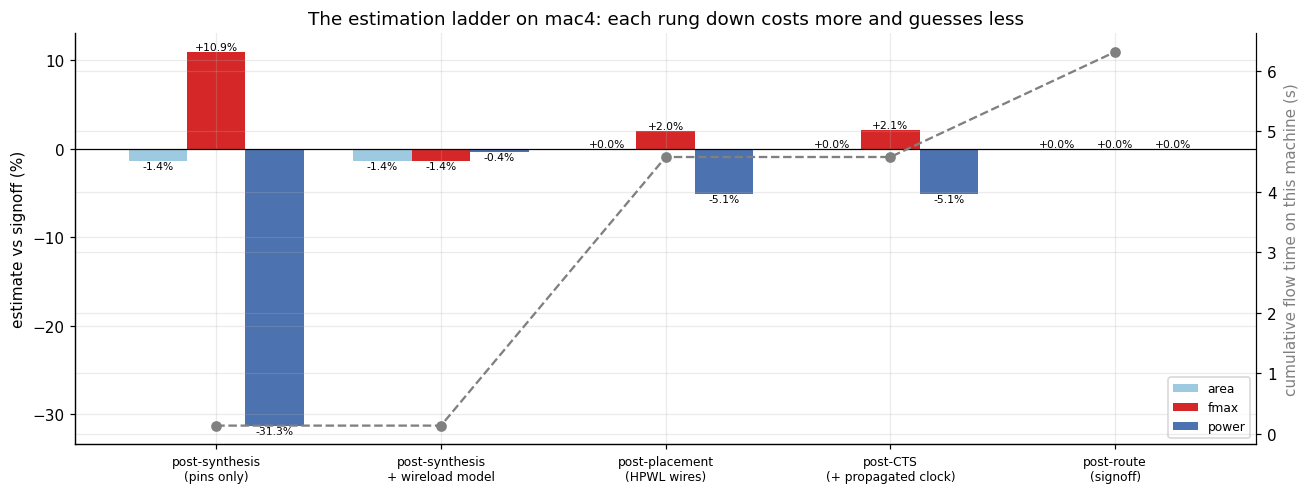

Area is known at synthesis up to the buffers added later. Power is off by the wire capacitance the early
rungs cannot see (~30% of the load here). Timing is the one whose *sign* is in play: the pins-only estimate
has +94 ps of slack at 1 GHz; signoff has -5 ps -- the design that 'met timing' at synthesis does not.
The wireload model -- calibrated on this very design's routed wires, a generous test -- fixes the
average, not the path that matters.


In [23]:
def fit_wireload_model(para, nl):
    '''The 1990s estimator: mean wire capacitance as a function of fanout, calibrated on routed designs.'''
    by_fanout = defaultdict(list)
    for n, p in para.items():
        by_fanout[min(len(nl.nets[n]["sinks"]), 6)].append(p["C_wire_fF"])
    table = {k: float(np.mean(v)) for k, v in by_fanout.items()}
    return lambda fanout: table.get(min(fanout, 6), table[max(table)])


def stage_estimates(nl, pl, para, toggles, n_cycles, clk_nets, T, wlm):
    '''The same three PPA numbers as they look from each rung of the ladder. Signoff is the last entry.'''
    lib = nl.lib
    area_syn = sum(lib[c["type"]]["area"] for i, c in nl.cells.items() if not i.startswith("CTS_"))
    area_all = sum(lib[c["type"]]["area"] for c in nl.cells.values())
    fanout = {n: len(d["sinks"]) for n, d in nl.nets.items()}
    hpwl = {n: pl.hpwl([n]) for n in nl.nets}
    def para_from(cap, length):                                 # a parasitic table from any wire-length guess
        out = {}
        for n, d in nl.nets.items():
            Cp = sum(lib[nl.cells[i]["type"]]["pins"][p]["cap"] for i, p in d["sinks"] if i != "PO")
            R = R_PER_UM * length[n]
            out[n] = dict(C_wire_fF=cap[n], C_pin_fF=Cp, C_total_fF=cap[n] + Cp, wire_delay_ns=(0.38 * R * cap[n] + R * Cp) * 1e-6)
        return out
    rungs = [
        ("post-synthesis\n(pins only)",      {n: 0.0 for n in nl.nets},                    {n: 0.0 for n in nl.nets},                        False, area_syn),
        ("post-synthesis\n+ wireload model", {n: wlm(fanout[n]) for n in nl.nets},          {n: wlm(fanout[n]) / C_PER_UM for n in nl.nets},  False, area_syn),
        ("post-placement\n(HPWL wires)",     {n: C_PER_UM * hpwl[n] for n in nl.nets},      hpwl,                                             False, area_all),
        ("post-CTS\n(+ propagated clock)",   {n: C_PER_UM * hpwl[n] for n in nl.nets},      hpwl,                                             True,  area_all),
        ("post-route\n(signoff)",            {n: p["C_wire_fF"] for n, p in para.items()},  {n: p["L_um"] for n, p in para.items()},          True,  area_all),
    ]
    est = {}
    for name, cap, length, propagated, area in rungs:
        p = para_from(cap, length)
        clk = clock_arrivals(nl, p) if propagated else None
        sta = run_sta(nl, T, wire_cap_fF=cap, wire_delay_ns={n: q["wire_delay_ns"] for n, q in p.items()}, clock_arrival=clk)
        est[name] = dict(area=area, fmax=1e3 / (T - sta["wns"]), wns=sta["wns"] * 1e3,
                         power=switching_power(nl, toggles, n_cycles, cap, clk_nets) * 1e6)
    return est


WLM = fit_wireload_model(PARA, NL)
print("wireload model fitted on this design's routed wires -- fanout -> mean wire cap (fF):",
      {k: round(WLM(k), 2) for k in range(1, 7)})
EST = stage_estimates(NL, PL, PARA, SIM.toggles, len(stim), CLK_NETS, T_CLK, WLM)
truth = EST["post-route\n(signoff)"]

# cost to reach each rung: measured on this machine (base run of section 15) and at industry scale
ts = RES[0]["t_stage"]
cum = {"post-synthesis\n(pins only)": ts["synthesis"], "post-synthesis\n+ wireload model": ts["synthesis"],
       "post-placement\n(HPWL wires)": ts["synthesis"] + ts["placement"],
       "post-CTS\n(+ propagated clock)": ts["synthesis"] + ts["placement"] + ts["cts"],
       "post-route\n(signoff)": sum(ts.values())}
scale = ["hours", "hours", "hours - 1 day", "+ hours", "days"]
rows = []
for (name, e), sc in zip(EST.items(), scale):
    rows.append([name.replace("\n", " "), f"{cum[name]:.1f} s", sc,
                 f"{e['area']:.1f} ({(e['area']/truth['area'] - 1)*100:+.1f}%)",
                 f"{e['fmax']:.0f} ({(e['fmax']/truth['fmax'] - 1)*100:+.1f}%)", f"{e['wns']:+.0f}",
                 f"{e['power']:.0f} ({(e['power']/truth['power'] - 1)*100:+.1f}%)"])
show_table(["rung", "cost here", "cost at scale", "area um^2 (err)", "fmax MHz (err)", "WNS ps", "power uW (err)"], rows)

fig, ax = plt.subplots(figsize=(12, 4.6))
names = list(EST); x = np.arange(len(names)); w = 0.26
for k, (metric, col) in enumerate([("area", "#9ecae1"), ("fmax", "#d62728"), ("power", "#4c72b0")]):
    err = [(EST[n][metric] / truth[metric] - 1) * 100 for n in names]
    bars = ax.bar(x + (k - 1) * w, err, w, color=col, label=metric)
    ax.bar_label(bars, fmt="%+.1f%%", fontsize=7)
ax.axhline(0, c="k", lw=0.8); ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel("estimate vs signoff (%)"); ax.legend(fontsize=8, loc="lower right")
ax2 = ax.twinx(); ax2.plot(x, [cum[n] for n in names], "o--", c="gray"); ax2.set_ylabel("cumulative flow time on this machine (s)", color="gray")
ax2.spines["right"].set_visible(True)
ax.set_title("The estimation ladder on mac4: each rung down costs more and guesses less")
plt.tight_layout(); plt.show()
print("Area is known at synthesis up to the buffers added later. Power is off by the wire capacitance the early")
print("rungs cannot see (~30% of the load here). Timing is the one whose *sign* is in play: the pins-only estimate")
print(f"has {EST[names[0]]['wns']:+.0f} ps of slack at 1 GHz; signoff has {truth['wns']:+.0f} ps"
      + (" -- the design that 'met timing' at synthesis does not." if truth["wns"] < 0 else
         " -- it survives by a hair, and section 16.2 shows a different placement seed flips it."))
print("The wireload model -- calibrated on this very design's routed wires, a generous test -- fixes the")
print("average, not the path that matters.")

### 16.1 A dataset: how precise is each rung *across designs*?

One design tells you about one design. An estimator is judged across a population: does the post-synthesis
number *rank* designs correctly? Is its error a constant bias (harmless: calibrate it out) or noise
(harmful)? We generate a small family of RTL variants — multiply-accumulate units of width 2 to 6, plain
and pipelined, plus two accumulate-only blocks — push each through the entire flow, and score every rung
against signoff. Twelve designs is a toy dataset (papers use thousands, generated with exactly this kind of
scripted open-source flow), but it is enough to see the pattern. One flow knob changes with size: blocks
of 150+ cells are placed at 40% utilization instead of 60%, because our two routing layers cannot carry a
dense multiplier otherwise — a real flow would add metal layers; both flows do this kind of routability
steering.


In [24]:
def mac_rtl(W, pipelined=False, multiply=True):
    '''A family of accumulators: acc <= clear ? 0 : (en ? acc + a*b : acc), parametrised by width and structure.'''
    WA = 2 * W                                           # accumulator width: holds a full product
    top = f"{'mac' if multiply else 'acc'}{W}{'p' if pipelined else ''}"
    op = "a * b" if multiply else "a + b"
    prod = (f"    reg  [{WA-1}:0] prod;\n    always @(posedge clk or negedge rst_n)\n"
            f"        if (!rst_n) prod <= 0; else prod <= {op};\n") if pipelined else f"    wire [{WA-1}:0] prod = {op};\n"
    return top, f'''module {top} (input wire clk, input wire rst_n, input wire clear, input wire en,
    input wire [{W-1}:0] a, input wire [{W-1}:0] b, output reg [{WA-1}:0] acc);
{prod}    always @(posedge clk or negedge rst_n) begin
        if (!rst_n)     acc <= 0;
        else if (clear) acc <= 0;
        else if (en)    acc <= acc + prod;
    end
endmodule
'''

VARIANTS = [(W, p, True) for W in (2, 3, 4, 5, 6) for p in (False, True)] + [(4, False, False), (8, False, False)]
DATASET = []
t0 = time.time()
for W, pipelined, multiply in VARIANTS:
    top, rtl = mac_rtl(W, pipelined, multiply)
    r = run_flow(rtl, f"ds_{top}", T=T_CLK, top=top)
    r["est"] = stage_estimates(r["nl"], r["pl"], r["para"], r["toggles"], r["n_cycles"], r["clk_nets"], T_CLK, WLM)
    DATASET.append(r)
    print(f"{top:<6} {r['cells']:>4} cells  {r['flops']:>3} flops  area {r['area']:6.1f}  fmax {r['fmax_post']:5.0f} MHz  "
          f"power {r['power_uW']:5.0f} uW  signoff {'clean' if r['lvs'] == (0, 0) and r['drc'] == 0 else 'FAIL'}  ({sum(r['t_stage'].values()):.1f} s)")
print(f"\n{len(DATASET)} designs through the full flow in {time.time() - t0:.0f} s")

mac2     40 cells    4 flops  area   59.9  fmax  2053 MHz  power    55 uW  signoff clean  (2.1 s)


mac2p    39 cells    8 flops  area   76.3  fmax  2584 MHz  power    55 uW  signoff clean  (2.1 s)


mac3     77 cells    6 flops  area  108.0  fmax  1370 MHz  power   127 uW  signoff clean  (3.9 s)


mac3p    84 cells   12 flops  area  139.4  fmax  1934 MHz  power   125 uW  signoff clean  (4.3 s)


mac4    131 cells    8 flops  area  175.8  fmax   975 MHz  power   217 uW  signoff clean  (6.3 s)


...

mac5p   202 cells   20 flops  area  306.4  fmax   956 MHz  power   352 uW  signoff clean  (12.1 s)


mac6    281 cells   12 flops  area  360.2  fmax   701 MHz  power   540 uW  signoff clean  (18.3 s)


mac6p   281 cells   24 flops  area  411.0  fmax   894 MHz  power   544 uW  signoff clean  (26.9 s)


acc4     69 cells    8 flops  area  108.0  fmax  1325 MHz  power   116 uW  signoff clean  (3.5 s)


acc8    138 cells   16 flops  area  220.8  fmax   938 MHz  power   257 uW  signoff clean  (7.6 s)

12 designs through the full flow in 105 s


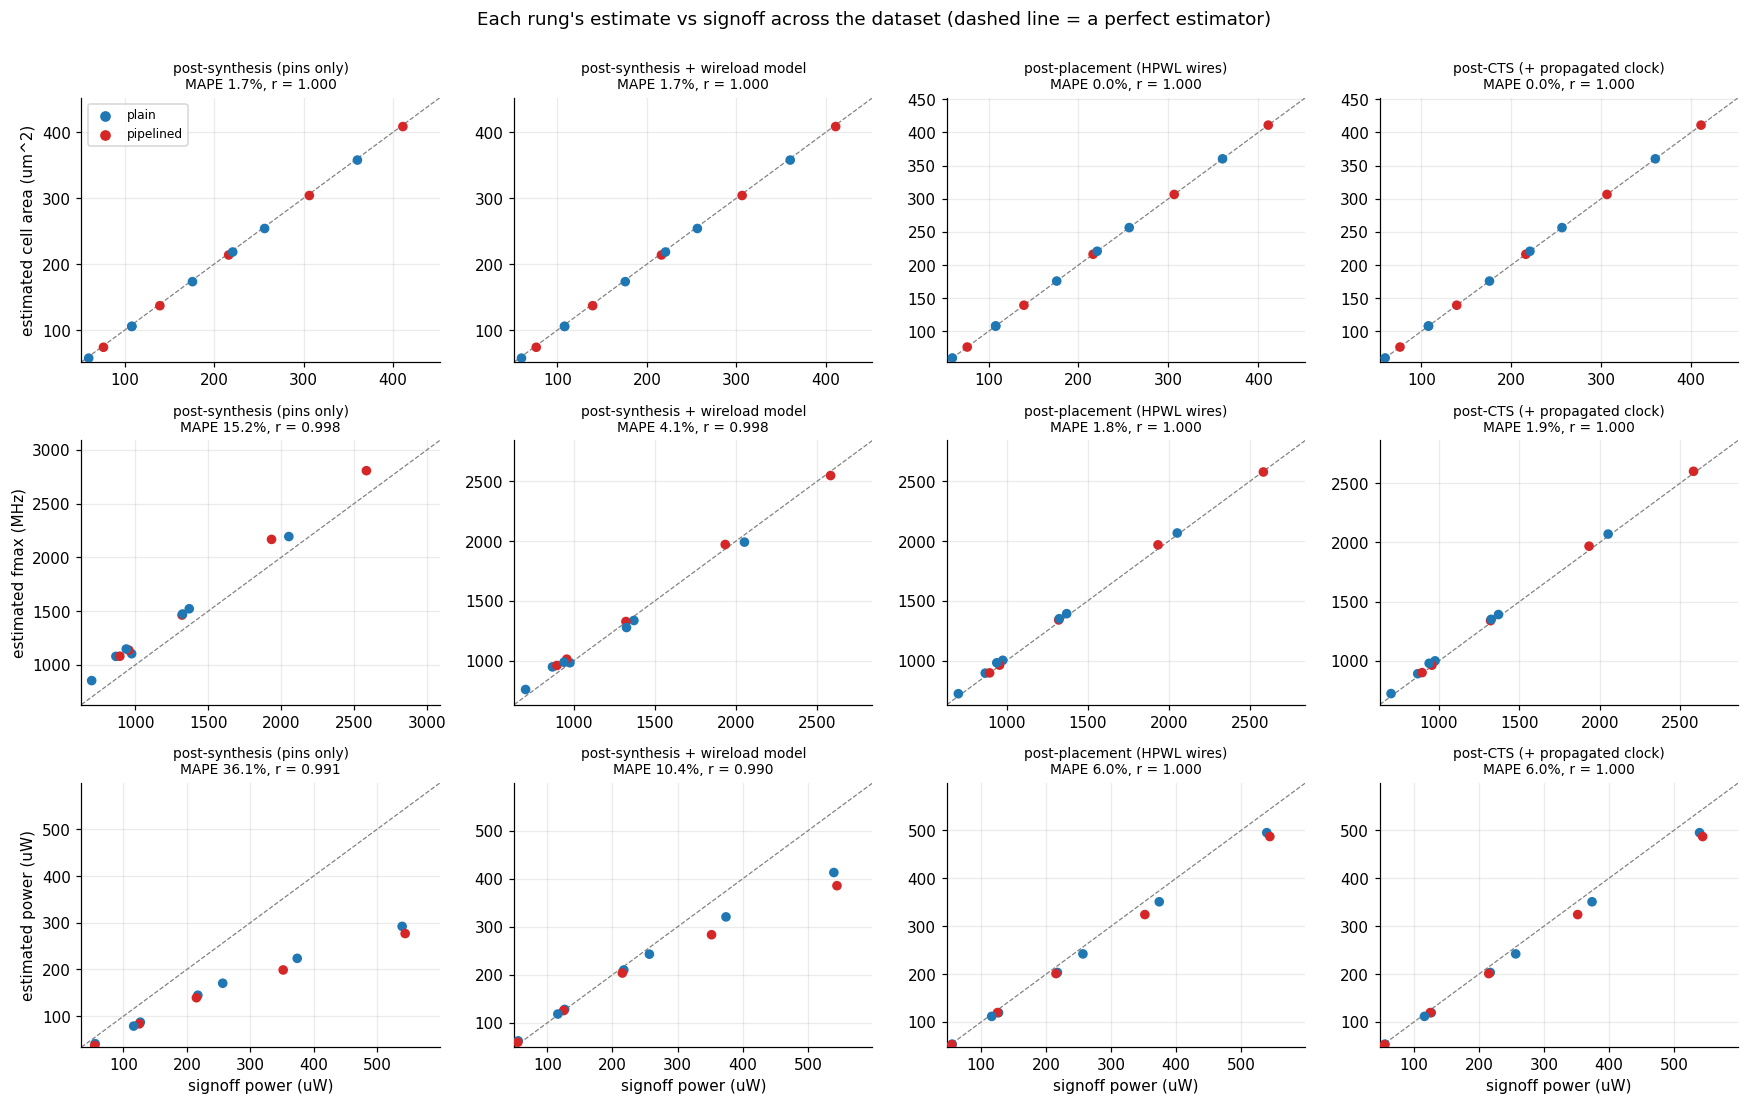

rung                             area MAPE  fmax MAPE  power MAPE  area r  fmax r  power r
------------------------------------------------------------------------------------------
post-synthesis (pins only)       1.7%       15.2%      36.1%       1.000   0.998   0.991  
post-synthesis + wireload model  1.7%       4.1%       10.4%       1.000   0.998   0.990  
post-placement (HPWL wires)      0.0%       1.8%       6.0%        1.000   1.000   1.000  
post-CTS (+ propagated clock)    0.0%       1.9%       6.0%        1.000   1.000   1.000  

Area: known at synthesis (the flow adds only 3 clock buffers). Power: a consistent underestimate that
shrinks as wires become known -- a bias, hence calibratable. fmax: the post-synthesis estimate ranks designs
well (high r, but note the designs span 4x in fmax -- ranking *within* a family of near-identical variants
is much harder) and is optimistic for every one of them; a wireload model helps the bias, not the noise.


In [25]:
RUNGS = [n for n in EST if "signoff" not in n]
METRICS = [("area", "cell area (um^2)"), ("fmax", "fmax (MHz)"), ("power", "power (uW)")]
PIPE = [d["top"].endswith("p") for d in DATASET]

def score(pred, true):
    pred, true = np.asarray(pred, float), np.asarray(true, float)
    mape = np.mean(np.abs(pred / true - 1)) * 100
    r = np.corrcoef(pred, true)[0, 1] if np.std(pred) > 0 and np.std(true) > 0 else float("nan")
    return mape, r

fig, axes = plt.subplots(3, len(RUNGS), figsize=(4 * len(RUNGS), 10))
SCORES = {}
for i, (metric, label) in enumerate(METRICS):
    true = [d["est"]["post-route\n(signoff)"][metric] for d in DATASET]
    for j, rung in enumerate(RUNGS):
        pred = [d["est"][rung][metric] for d in DATASET]
        mape, r = score(pred, true); SCORES[(rung, metric)] = (mape, r)
        ax = axes[i, j]
        ax.scatter(true, pred, s=28, c=["#d62728" if p else "#1f77b4" for p in PIPE], zorder=3)
        lo, hi = min(min(true), min(pred)) * 0.9, max(max(true), max(pred)) * 1.1
        ax.plot([lo, hi], [lo, hi], "--", c="gray", lw=0.8); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_title(f"{rung.replace(chr(10), ' ')}\nMAPE {mape:.1f}%, r = {r:.3f}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"estimated {label}")
        if i == 2:
            ax.set_xlabel(f"signoff {label}")
axes[0, 0].scatter([], [], c="#1f77b4", label="plain"); axes[0, 0].scatter([], [], c="#d62728", label="pipelined"); axes[0, 0].legend(fontsize=8)
plt.suptitle("Each rung's estimate vs signoff across the dataset (dashed line = a perfect estimator)", y=1.0)
plt.tight_layout(); plt.show()

show_table(["rung"] + [f"{m} MAPE" for m, _ in METRICS] + [f"{m} r" for m, _ in METRICS],
           [[rung.replace(chr(10), " ")] + [f"{SCORES[(rung, m)][0]:.1f}%" for m, _ in METRICS] + [f"{SCORES[(rung, m)][1]:.3f}" for m, _ in METRICS] for rung in RUNGS])
print("\nArea: known at synthesis (the flow adds only 3 clock buffers). Power: a consistent underestimate that")
print("shrinks as wires become known -- a bias, hence calibratable. fmax: the post-synthesis estimate ranks designs")
print("well (high r, but note the designs span 4x in fmax -- ranking *within* a family of near-identical variants")
print("is much harder) and is optimistic for every one of them; a wireload model helps the bias, not the noise.")

### 16.2 The rung above synthesis: an RTL-stage model

Everything so far needed at least a synthesis run. The reader's problem is one rung higher: predict the
signoff numbers **from the RTL alone**, in seconds. The classic approach — and the degenerate version of
MasterRTL's operator graph, SNS's per-block features, RTL-Timer's per-register cones — is to extract
features from the *elaborated word-level netlist* (§3, which Yosys produces in well under a second) and
learn the mapping from designs the flow has already been run on.

Two kinds of features, chosen to match what each metric physically depends on:

- **size** features for area and power: total multiplier bit-products (a W×W multiplier is ~W² adder
  cells), total adder and mux bits, flop bits (the clock load);
- a **structure** feature for timing: the longest operator chain between registers, weighted by a
  per-operator depth model (multiplier ≈ 2W levels, adder ≈ W, mux ≈ 1). The model predicts the clock
  *period* (delay is linear in depth) and reports it as fmax. Pipelining changes only this feature — the
  size features barely move — which is exactly the "text edit vs structural edit" lesson from the kimi-chip
  data in §8.

Twelve designs is far too few to *train* anything serious, so the model is linear and scored
leave-one-out: each design is predicted by a model fitted on the other eleven.


design  mul bits  add bits  mux bits  flop bits  depth levels  cells  fmax MHz
------------------------------------------------------------------------------
mac2    4         4         8         4          10            40     2053    
mac2p   4         4         8         8          6             39     2584    
mac3    9         6         12        6          14            77     1370    
mac3p   9         6         12        12         8             84     1934    
mac4    16        8         16        8          18            131    975     
mac4p   16        8         16        16         10            137    1321    
mac5    25        10        20        10         22            197    867     
mac5p   25        10        20        20         12            202    956     
mac6    36        12        24        12         26            281    701     
mac6p   36        12        24        24         14            281    894     
acc4    0         13        16        8          15 

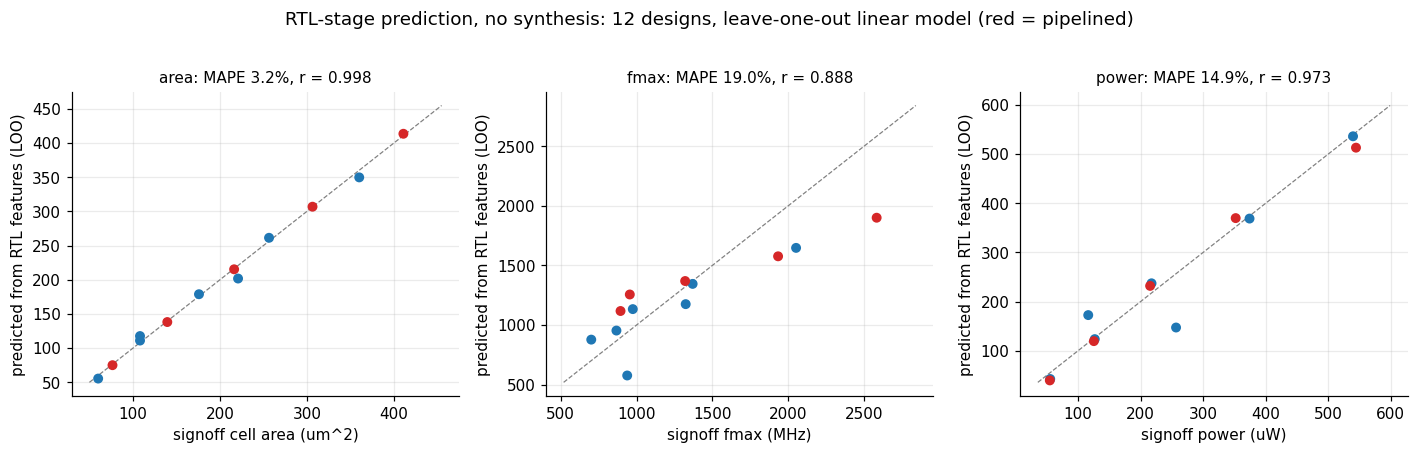

In [26]:
def rtl_features(generic):
    '''Size and structure features from the elaborated (word-level) netlist -- no synthesis needed.'''
    f = Counter()
    owner = {}                                                          # bit -> driving cell
    for cname, c in generic["cells"].items():
        for pin, bits in c["connections"].items():
            if c["port_directions"][pin] == "output":
                for b in bits:
                    owner[b] = cname
    depth_w = {}
    for cname, c in generic["cells"].items():
        t, conn = c["type"], c["connections"]
        if t == "$mul":
            f["mul_bits"] += len(conn["A"]) * len(conn["B"]); depth_w[cname] = 2 * max(len(conn["A"]), len(conn["B"]))
        elif t in ("$add", "$sub"):
            f["add_bits"] += len(conn["Y"]); depth_w[cname] = len(conn["Y"])
        elif t in ("$mux", "$pmux"):
            f["mux_bits"] += len(conn["Y"]); depth_w[cname] = 1
        elif t.startswith(("$dff", "$adff", "$sdff")):
            f["flop_bits"] += len(conn["Q"]); depth_w[cname] = 0
        else:
            f["other_bits"] += len(conn.get("Y", [])); depth_w[cname] = 1
    f["in_bits"] = sum(len(p["bits"]) for p in generic["ports"].values() if p["direction"] == "input")
    memo = {}
    def longest_into(cname):                        # longest weighted operator chain feeding this cell (registers break paths)
        if cname not in memo:
            c, best = generic["cells"][cname], 0
            for pin, bits in c["connections"].items():
                if c["port_directions"][pin] == "input":
                    for b in bits:
                        src = owner.get(b)
                        if src is not None and not generic["cells"][src]["type"].startswith(("$dff", "$adff", "$sdff")):
                            best = max(best, longest_into(src))
            memo[cname] = best + depth_w[cname]
        return memo[cname]
    f["depth_levels"] = max(longest_into(c) for c in generic["cells"])
    return f


def loo_linear(X, y, ridge=1e-3):
    '''Leave-one-out predictions of a ridge-regularised linear model on standardised features.'''
    X, y = np.asarray(X, float), np.asarray(y, float)
    preds = []
    for k in range(len(y)):
        m = np.arange(len(y)) != k
        mu, sd = X[m].mean(0), X[m].std(0) + 1e-9
        A = np.column_stack([(X[m] - mu) / sd, np.ones(m.sum())])
        w = np.linalg.solve(A.T @ A + ridge * np.eye(A.shape[1]), A.T @ y[m])
        preds.append(np.append((X[k] - mu) / sd, 1.0) @ w)
    return np.array(preds)


FEATS = [rtl_features(d["generic"]) for d in DATASET]
show_table(["design", "mul bits", "add bits", "mux bits", "flop bits", "depth levels", "cells", "fmax MHz"],
           [[d["top"], f["mul_bits"], f["add_bits"], f["mux_bits"], f["flop_bits"], f["depth_levels"], d["cells"], f"{d['fmax_post']:.0f}"]
            for d, f in zip(DATASET, FEATS)])

size = [[f["mul_bits"], f["add_bits"], f["mux_bits"], f["flop_bits"]] for f in FEATS]
structure = [[f["depth_levels"], f["in_bits"]] for f in FEATS]
truth_ds = {m: [d["est"]["post-route\n(signoff)"][m] for d in DATASET] for m, _ in METRICS}
RTL_PRED = {"area": loo_linear(size, truth_ds["area"]), "power": loo_linear(size, truth_ds["power"]),
            "fmax": 1e3 / loo_linear(structure, 1e3 / np.array(truth_ds["fmax"]))}   # delay is linear in depth, so fit the period

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (metric, label) in zip(axes, METRICS):
    pred, true = RTL_PRED[metric], truth_ds[metric]
    mape, r = score(pred, true); SCORES[("RTL features\n(learned, LOO)", metric)] = (mape, r)
    ax.scatter(true, pred, s=30, c=["#d62728" if p else "#1f77b4" for p in PIPE], zorder=3)
    lo, hi = min(min(true), min(pred)) * 0.9, max(max(true), max(pred)) * 1.1
    ax.plot([lo, hi], [lo, hi], "--", c="gray", lw=0.8)
    ax.set_xlabel(f"signoff {label}"); ax.set_ylabel("predicted from RTL features (LOO)")
    ax.set_title(f"{metric}: MAPE {mape:.1f}%, r = {r:.3f}", fontsize=10)
plt.suptitle(f"RTL-stage prediction, no synthesis: {len(DATASET)} designs, leave-one-out linear model (red = pipelined)", y=1.02)
plt.tight_layout(); plt.show()

mac4, placement  cell area  wire um  WNS post ps  fmax MHz  power uW
--------------------------------------------------------------------
seed 1           175.8      1236.2   -25          975.4     217.4   
seed 2           175.8      1164.0   +8           1007.8    213.1   
seed 3           175.8      1196.0   -16          984.7     214.3   
seed 4           175.8      1227.1   +13          1013.6    218.9   

label-noise floor (std/mean across seeds): area 0%, fmax 1.6%, power 1.1%
estimator                        area MAPE  fmax MAPE  power MAPE
-----------------------------------------------------------------
post-synthesis (pins only)       1.7%       15.2%      36.1%     
post-synthesis + wireload model  1.7%       4.1%       10.4%     
post-placement (HPWL wires)      0.0%       1.8%       6.0%      
post-CTS (+ propagated clock)    0.0%       1.9%       6.0%      
RTL features (learned, LOO)      3.2%       19.0%      14.9%     
noise floor (seed-to-seed)       0.0%       1.6% 

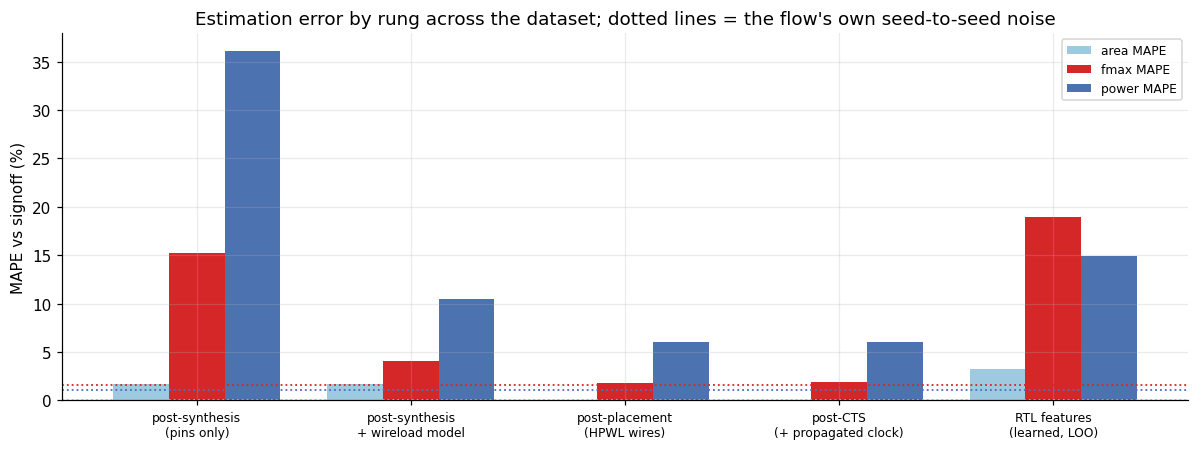

In [27]:
# The floor: the same RTL, the same flow, a different placement seed. No estimator can beat this.
NOISE = [next(d for d in DATASET if d["top"] == "mac4")]
for seed in (2, 3, 4):
    NOISE.append(run_flow(mac_rtl(4)[1], f"noise_seed{seed}", T=T_CLK, top="mac4", seed=seed))
show_table(["mac4, placement", "cell area", "wire um", "WNS post ps", "fmax MHz", "power uW"],
           [[f"seed {s}", r["area"], r["wire"], f"{r['wns_post']*1e3:+.0f}", r["fmax_post"], r["power_uW"]] for s, r in zip((1, 2, 3, 4), NOISE)], "{:.1f}")
fm = np.array([r["fmax_post"] for r in NOISE]); pw = np.array([r["power_uW"] for r in NOISE])
FLOOR = {"area": 0.0, "fmax": fm.std() / fm.mean() * 100, "power": pw.std() / pw.mean() * 100}
print(f"\nlabel-noise floor (std/mean across seeds): area 0%, fmax {FLOOR['fmax']:.1f}%, power {FLOOR['power']:.1f}%")

ladder = RUNGS + ["RTL features\n(learned, LOO)"]
show_table(["estimator"] + [f"{m} MAPE" for m, _ in METRICS],
           [[e.replace(chr(10), " ")] + [f"{SCORES[(e, m)][0]:.1f}%" for m, _ in METRICS] for e in ladder]
           + [["noise floor (seed-to-seed)"] + [f"{FLOOR[m]:.1f}%" for m, _ in METRICS]])
fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(ladder)); w = 0.26
for k, (metric, col) in enumerate([("area", "#9ecae1"), ("fmax", "#d62728"), ("power", "#4c72b0")]):
    ax.bar(x + (k - 1) * w, [SCORES[(e, metric)][0] for e in ladder], w, color=col, label=f"{metric} MAPE")
    ax.axhline(FLOOR[metric], c=col, ls=":", lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(ladder, fontsize=8); ax.set_ylabel("MAPE vs signoff (%)")
ax.set_title("Estimation error by rung across the dataset; dotted lines = the flow's own seed-to-seed noise")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 16.3 Reading the ladder

- **Area is the easy target.** It is fixed at synthesis up to the cells later stages add (here three clock
  buffers; in a real block 5–15% of buffers, hold-fix cells and fill), and it is nearly linear in the
  word-level feature sizes — which is why RTL-stage area prediction works even with a handful of samples.
- **Power is a bias problem.** Every early rung underestimates it by the wire capacitance it cannot see;
  the ratio is stable across designs, so a calibrated estimator recovers most of it. The part no rung can
  fix is the *activity*: change the workload and the label moves (§13) — real estimators take an activity
  file as an input, not as an assumption.
- **Timing is the hard target, for three reasons this dataset shows.** (1) WNS is a max over paths: one
  net's detour moves it, and the seed-to-seed noise on fmax (1–3%) is the largest of the three — area has
  none. (2) It changes sign: the pins-only estimate meets 1 GHz for `mac4` with 94 ps to spare, signoff
  does not; an estimator that is 10–15% optimistic on average is useless for the shift-left job whenever
  the design sits within that margin of its target — which is exactly where designs are pushed to sit.
  (3) It is structural, not textual: the plain and pipelined variants differ by three lines of RTL and
  share their size features, yet their fmax differs by 30–40%; only the operator-chain feature separates
  them. And the one bad miss in the RTL model — the accumulate-only `acc8`, predicted far too slow — is
  the hand-written depth model's fault (it assumes a W-level ripple adder; ABC built a faster one), not
  the learner's. This is why the models in your reading list build *graphs* of the RTL (MasterRTL's
  bit-level operator graph, RTL-Timer's per-register cones) and learn the operator delays instead of
  hand-writing them, and why they still report timing correlations below their area and power ones.
- **The label is a choice.** Every number above is conditional on a clock target, an SDC, a utilization, a
  library corner, a placement seed and a router; "post-synthesis WNS" and "post-route WNS" are different
  labels with different noise, and papers that disagree often disagree on this rather than on modeling.
  When you build a dataset, decide the rung of the label first, and measure its noise floor the way we did
  — an estimator that "beats" that floor is fitting the seed.
- **Where the loop closes.** The cheapest rung that gets the *sign* of slack right for your designs is the
  one the RTL author should be running in their editor. Here, HPWL-based post-placement timing is within
  2% and the pins-only number is 10–15% off; an RTL model that matched the post-placement rung would
  collapse hours of flow per iteration into the seconds it takes Yosys to elaborate — the whole promise of
  the field.


## 17. The flow as a table

Every row is a stage you just watched, with the artifact it produced, the PPA numbers it could see, and
the commercial tool that does it at scale (Synopsys / Cadence / Siemens) alongside the open-source one.


In [28]:
rows = [
    ["§1 RTL", "mac4.v", "-", "-", "-", "(human) / HLS: Catapult, Stratus", "-"],
    ["§2 simulation", "waves.vcd", "-", "-", "-", "VCS / Xcelium / Questa", "Icarus, Verilator"],
    ["§3 elaboration", "generic.json", "-", "-", "-", "DC / Genus front end", "Yosys"],
    ["§5 synthesis", "mapped.v", f"{area:.0f} um^2 cells", f"WNS {STA_PRE['wns']*1e3:+.0f} ps (pre)", "-", "Design Compiler / Genus", "Yosys + ABC"],
    ["§6 STA", "timing.rpt", "-", f"fmax ~{1e3/(arr_worst + STA_PRE['detail'][STA_PRE['worst']][2]):.0f} MHz", "-", "PrimeTime / Tempus", "OpenSTA"],
    ["§7 floorplan", "floorplan", f"core {FP.core_w*FP.core_h:.0f} um^2", "-", "-", "ICC2 / Innovus", "OpenROAD"],
    ["§8 placement", "placed", f"HPWL {PL.hpwl():.0f} um", "-", "-", "Fusion Compiler / Innovus", "OpenROAD (RePlAce)"],
    ["§9 CTS", "+3 CLKBUF", f"+{3 * LIB['CLKBUF_X1']['area']:.1f} um^2", f"latency {lat.mean():.0f} ps, skew {np.ptp(lat):.1f} ps", "-", "Fusion Compiler / Innovus", "OpenROAD (TritonCTS)"],
    ["§10 routing", "routed", f"wire {tot[0]+tot[1]:.0f} um", "-", "-", "Fusion Compiler / Innovus", "OpenROAD (TritonRoute)"],
    ["§11 extraction", "mac4.spef", f"C_wire {tot_cw:.0f} fF", "-", "-", "StarRC / Quantus", "OpenRCX"],
    ["§12 signoff STA", "signoff.rpt", "-", f"WNS {STA_POST['wns']*1e3:+.0f} ps (post)", "-", "PrimeTime / Tempus", "OpenSTA"],
    ["§13 power", "power.rpt", "-", "-", f"{total*1e6:.0f} uW", "PrimePower / Voltus", "OpenSTA power"],
    ["§14 LVS/DRC", f"{opens} opens, {shorts} shorts, {via_viol} DRC", "-", "-", "-", "Calibre / IC Validator / Pegasus", "Magic, KLayout, netgen"],
    ["§14 tapeout", "mac4.gds" if SIGNOFF_CLEAN else "(blocked)", "-", "-", "-", "(foundry: OPC, masks)", "KLayout"],
]
show_table(["stage", "artifact", "area", "performance", "power", "commercial", "open source"], rows)
print(f"\nAll artifacts are in ./{WORK}/ -- open mac4.gds in KLayout, waves.vcd in GTKWave/Surfer, mac4.spef in any editor.")
print("Not in this flow, present in every real one: DFT/scan insertion, hold fixing after CTS, multi-corner")
print("and on-chip-variation timing, crosstalk, IR-drop/EM signoff, metal fill, antenna fixes, formal equivalence.")

stage            artifact                  area            performance                 power   commercial                        open source           
-------------------------------------------------------------------------------------------------------------------------------------------------------
§1 RTL           mac4.v                    -               -                           -       (human) / HLS: Catapult, Stratus  -                     
§2 simulation    waves.vcd                 -               -                           -       VCS / Xcelium / Questa            Icarus, Verilator     
§3 elaboration   generic.json              -               -                           -       DC / Genus front end              Yosys                 
§5 synthesis     mapped.v                  173 um^2 cells  WNS +94 ps (pre)            -       Design Compiler / Genus           Yosys + ABC           
§6 STA           timing.rpt                -               fmax ~1104 MHz              -

**What to take from this notebook.**

- The flow is a sequence of *representations* — text → word-level graph → gate graph → graph with
  coordinates → graph with geometry → polygons — and each stage's tool can only optimize what its
  representation can see. Synthesis cannot see wires; placement cannot see the exact route; only signoff
  sees everything, which is why every earlier PPA number is an *estimate of the final one*.
- The two real tools in the chain (Icarus, Yosys+ABC) and the real Liberty file anchor every number:
  the 128-cell netlist, the 13-gate pre-layout critical path, the cell areas, the setup times. The toy
  stages reproduce the *behavior* of the real ones — post-route slack degrades by the wire load, four
  clock nets burn a disproportionate share of power, pipelining buys the frequency — with algorithms
  short enough to read.
- For RTL-stage PPA estimation: everything from §7 onward is what your model must predict *without
  running*. The label (§12's WNS, §13's power, §7's area) depends on utilization, placement seed, router
  order, and the clock target — each a dataset-definition choice. This flow is deterministic (same seed,
  same numbers, bit for bit); rerun it with `Placement(FP, seed=2)` and watch the post-route WNS move by
  tens of picoseconds. That is placement noise alone — a real flow adds tool-version, multithreading and
  hash-order noise on top — and it is the floor below which "better prediction" is meaningless.

**Files this notebook wrote** (`flow_artifacts/`): `mac4.v`, `tb.v`, `waves.vcd`, `generic.json`,
`mapped.json`, `mapped.v`, `mac4.sdc`, `timing_prelayout.rpt`, `timing_postroute.rpt`, `mac4.spef`,
`mac4.gds`, plus the pipelined variant. **References**: the Nangate45 library and tech LEF from
[OpenROAD-flow-scripts](https://github.com/The-OpenROAD-Project/OpenROAD-flow-scripts); Yosys manual
(`synth`, `dfflibmap`, `abc`); Liberty User Guide (NLDM); IEEE 1481 (SPEF); GDSII stream format (Calma,
1987 rev. 6); Lee, "An Algorithm for Path Connections" (1961); Kirkpatrick et al., "Optimization by
Simulated Annealing" (1983); the previous notebook in this series,
[hardware_design_from_first_principles.ipynb](hardware_design_from_first_principles.ipynb).
